# End-to-End Data Analysis
# E-Commerce Orders Dataset
Team 07
TechTrek

# 1. Business Understanding:
This dataset contains e-commerce orders including customers, products, pricing, marketing, delivery, returns, inventory, and suppliers. The goal is to identify the factors affecting revenue, customer satisfaction, delivery performance, and returns.

In [2]:
#2. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

os.makedirs("visuals", exist_ok=True)
def save_current_fig(name):
    plt.savefig(f"visuals/{name}.png", dpi=150, bbox_inches='tight')

In [3]:
#3. Load Dataset
df = pd.read_excel('Sales_Dataset.xlsx')
df.head()

,Order_ID,Order_Date,Order_Time,Customer_ID,Customer_Gender,Customer_Age,Customer_Area,Branch,Sales_Channel,Product_Domain,...,Return_Complaint_Text,Return_Request_Date,Refund_Method,Rating,Stock_Available_Before_Sale,Supplier,Lead_Time_Days,Competitor_Price_EGP,Weather,Season
0,ORD0000001,2025-01-01,13:35,C00012,Female,32,Miami,Miami,Store,Fashion,...,NaN,NaT,NaN,4.5,85,Alex Local Factory,7,445.16,Sunny,Winter
1,ORD0000002,2025-01-01,14:00,C00022,Male,36,Smouha,Smouha,Store,Stationery & Books,...,NaN,NaT,NaN,4.5,92,Local Supplier,7,135.96,Sunny,Winter
2,ORD0000003,2025-01-01,15:00,C00445,Female,33,Victoria,Downtown Alexandria,Store,Electronics Accessories,...,NaN,NaT,NaN,4.1,124,Cairo Distributor,10,150.79,Sunny,Winter
3,ORD0000004,2025-01-01,15:10,C00089,Male,31,Sidi Bishr,Sidi Bishr,Store,Fashion,...,الكرتونة كانت مفتوحة والتغليف متبهدل,2025-01-03,Store Credit,1.9,92,Cairo Textile Hub,7,623.85,Windy,Winter
4,ORD0000005,2025-01-01,15:40,C00959,Female,32,Sporting,Stanley,Instagram,Footwear,...,NaN,NaT,NaN,4.9,77,Local Supplier,3,1589.89,Sunny,Winter


In [4]:
raw_df = df.copy()

# 4. Data Exploration
# Initial Data Audit

In this section, we inspect the dataset structure and data quality before applying any preprocessing or cleaning steps.
The audit includes:
- Dataset shape
- Dataset shape and dimensions
- First and last five rows
- Data types and dataset information
- Descriptive statistics for numeric and categorical columns
- Missing values and their percentages
- Hidden missing-value formats
- Exact duplicate rows
- Duplicate business keys, especially Order_ID
- Unique values and value distributions for categorical columns
- Minimum, maximum, quartiles, and suspicious ranges for numeric columns
- Date range and invalid dates
- Order distribution by month, day, and hour
- Data-quality summary before cleaning

In [5]:
# 4.1 Dataset Overview
# Display dataset shape
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Dataset shape:", df.shape)

Number of rows: 7000
Number of columns: 36
Dataset shape: (7000, 36)


In [6]:
# Display first five rows
df.head()

,Order_ID,Order_Date,Order_Time,Customer_ID,Customer_Gender,Customer_Age,Customer_Area,Branch,Sales_Channel,Product_Domain,...,Return_Complaint_Text,Return_Request_Date,Refund_Method,Rating,Stock_Available_Before_Sale,Supplier,Lead_Time_Days,Competitor_Price_EGP,Weather,Season
0,ORD0000001,2025-01-01,13:35,C00012,Female,32,Miami,Miami,Store,Fashion,...,NaN,NaT,NaN,4.5,85,Alex Local Factory,7,445.16,Sunny,Winter
1,ORD0000002,2025-01-01,14:00,C00022,Male,36,Smouha,Smouha,Store,Stationery & Books,...,NaN,NaT,NaN,4.5,92,Local Supplier,7,135.96,Sunny,Winter
2,ORD0000003,2025-01-01,15:00,C00445,Female,33,Victoria,Downtown Alexandria,Store,Electronics Accessories,...,NaN,NaT,NaN,4.1,124,Cairo Distributor,10,150.79,Sunny,Winter
3,ORD0000004,2025-01-01,15:10,C00089,Male,31,Sidi Bishr,Sidi Bishr,Store,Fashion,...,الكرتونة كانت مفتوحة والتغليف متبهدل,2025-01-03,Store Credit,1.9,92,Cairo Textile Hub,7,623.85,Windy,Winter
4,ORD0000005,2025-01-01,15:40,C00959,Female,32,Sporting,Stanley,Instagram,Footwear,...,NaN,NaT,NaN,4.9,77,Local Supplier,3,1589.89,Sunny,Winter


In [7]:
# Display last five rows
df.tail()

,Order_ID,Order_Date,Order_Time,Customer_ID,Customer_Gender,Customer_Age,Customer_Area,Branch,Sales_Channel,Product_Domain,...,Return_Complaint_Text,Return_Request_Date,Refund_Method,Rating,Stock_Available_Before_Sale,Supplier,Lead_Time_Days,Competitor_Price_EGP,Weather,Season
6995,ORD0006996,2026-06-26,19:45,C00345,Female,43,Gleem,Gleem,Store,Electronics Accessories,...,التغليف الخارجي كان مقطوع والعميل رفض الاستلام,2026-07-02,Original Payment,2.5,147,Cairo Distributor,3,1004.88,Hot,Summer
6996,ORD0006997,2026-06-26,20:05,C00416,Female,22,Miami,Sidi Bishr,Website,Stationery & Books,...,NaN,NaT,NaN,3.8,33,Local Supplier,14,123.88,Hot,Summer
6997,ORD0006998,2026-06-26,20:20,C00564,Male,32,Sidi Bishr,Sidi Bishr,WhatsApp,Beauty,...,NaN,NaT,NaN,3.6,35,Cairo Distributor,10,390.27,Cloudy,Summer
6998,ORD0006999,2026-06-26,20:20,C00812,Female,30,Louran,Gleem,Store,Fashion,...,NaN,NaT,NaN,4.1,84,In-house,7,691.47,Sunny,Summer
6999,ORD0007000,2026-06-26,20:40,C00230,Male,19,Gleem,Sidi Bishr,WhatsApp,Electronics Accessories,...,NaN,NaT,NaN,3.4,138,Cairo Distributor,5,1179.66,Hot,Summer


In [8]:
# 4.2 Data Types and Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 36 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Order_ID                     7000 non-null   object        
 1   Order_Date                   7000 non-null   datetime64[ns]
 2   Order_Time                   7000 non-null   object        
 3   Customer_ID                  7000 non-null   object        
 4   Customer_Gender              7000 non-null   object        
 5   Customer_Age                 7000 non-null   int64         
 6   Customer_Area                7000 non-null   object        
 7   Branch                       7000 non-null   object        
 8   Sales_Channel                7000 non-null   object        
 9   Product_Domain               7000 non-null   object        
 10  Category                     7000 non-null   object        
 11  Product_ID                   7000 non-null 

In [9]:
df.dtypes

Order_ID                               object
Order_Date                     datetime64[ns]
Order_Time                             object
Customer_ID                            object
Customer_Gender                        object
Customer_Age                            int64
Customer_Area                          object
Branch                                 object
Sales_Channel                          object
Product_Domain                         object
Category                               object
Product_ID                             object
Product_Name                           object
Brand                                  object
Unit_Price_EGP                        float64
Quantity                                int64
Discount_Percent                      float64
Payment_Method                         object
Marketing_Source                       object
Campaign_Name                          object
Courier                                object
Expected_Delivery_Days            

In [10]:
# 4.3 Descriptive Statistics

df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Order_ID,7000,7000,ORD0007000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order_Date,7000,NaN,NaN,NaN,2025-09-27 00:30:02.057142784,2025-01-01 00:00:00,2025-05-18 00:00:00,2025-09-25 00:00:00,2026-02-09 00:00:00,2026-06-26 00:00:00,NaN
Order_Time,7000,168,20:20,85,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,7000,1133,C00001,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Gender,7000,2,Female,4142,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_Age,7000.0,NaN,NaN,NaN,30.040143,18.0,24.0,30.0,36.0,58.0,8.158556
Customer_Area,7000,14,Smouha,664,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Branch,7000,8,Downtown Alexandria,1196,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sales_Channel,7000,5,Store,2566,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product_Domain,7000,7,Fashion,3206,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
# 4.4 Missing Values Analysis
missing = pd.DataFrame({
    "Missing": df.isna().sum(),
    "Percent": round(df.isna().mean()*100,2)
})

missing.sort_values("Percent", ascending=False)

,Missing,Percent
Return_Complaint_Text,5957,85.10
Return_Request_Date,5957,85.10
Return_Reason_Category,5957,85.10
Refund_Method,5957,85.10
Courier,2566,36.66
Order_Time,0,0.00
Order_Date,0,0.00
Order_ID,0,0.00
Customer_ID,0,0.00
Customer_Gender,0,0.00


In [12]:
missing[missing["Missing"] > 0]

,Missing,Percent
Courier,2566,36.66
Return_Reason_Category,5957,85.10
Return_Complaint_Text,5957,85.10
Return_Request_Date,5957,85.10
Refund_Method,5957,85.10


In [13]:
# 4.5 Hidden Missing Values Check
missing_formats = ["", " ", "NA", "N/A", "Null", "None", "-"]

hidden_missing = {}

for col in df.select_dtypes(include="object").columns:
    count = df[col].astype(str).str.strip().isin(missing_formats).sum()
    hidden_missing[col] = count

hidden_missing = pd.Series(hidden_missing).sort_values(ascending=False)

hidden_missing[hidden_missing > 0]

Series([], dtype: int64)

In [14]:
# 4.6 Duplicate Rows Check
print('Exact duplicates:', df.duplicated().sum()) 

Exact duplicates: 0


In [15]:
# 4.7 Duplicate Business Keys Check
print('Duplicate Order_ID:', df.duplicated('Order_ID', keep=False).sum()) 

Duplicate Order_ID: 0


In [16]:
# 4.8 Categorical Variables Analysis
# Identify categorical columns
cat_cols = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(cat_cols.tolist())

Categorical columns:
['Order_ID', 'Order_Time', 'Customer_ID', 'Customer_Gender', 'Customer_Area', 'Branch', 'Sales_Channel', 'Product_Domain', 'Category', 'Product_ID', 'Product_Name', 'Brand', 'Payment_Method', 'Marketing_Source', 'Campaign_Name', 'Courier', 'Delivery_Status', 'Returned', 'Return_Reason_Category', 'Return_Complaint_Text', 'Refund_Method', 'Supplier', 'Weather', 'Season']


In [17]:
# Inspect unique values and value counts
for col in cat_cols:
    print("\n" + "=" * 60)
    print("Column:", col)
    print("Number of unique values:", df[col].nunique(dropna=False))
    print("\nValue counts:")
    print(df[col].value_counts(dropna=False))


Column: Order_ID
Number of unique values: 7000

Value counts:
Order_ID
ORD0007000    1
ORD0000001    1
ORD0000002    1
ORD0000003    1
ORD0000004    1
             ..
ORD0000028    1
ORD0000029    1
ORD0000030    1
ORD0000031    1
ORD0000032    1
Name: count, Length: 7000, dtype: int64

Column: Order_Time
Number of unique values: 168

Value counts:
Order_Time
20:20    85
20:35    76
18:15    76
20:50    75
18:20    74
         ..
23:30    11
10:35    11
10:10     9
10:40     8
10:50     8
Name: count, Length: 168, dtype: int64

Column: Customer_ID
Number of unique values: 1133

Value counts:
Customer_ID
C00001    106
C00002     75
C00003     63
C00005     55
C00004     51
         ... 
C01111      1
C00904      1
C00861      1
C00536      1
C00734      1
Name: count, Length: 1133, dtype: int64

Column: Customer_Gender
Number of unique values: 2

Value counts:
Customer_Gender
Female    4142
Male      2858
Name: count, dtype: int64

Column: Customer_Area
Number of unique values: 14

Val

In [18]:
# 4.9 Numerical Variables Analysis
# Identify numerical columns
num_cols = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(num_cols.tolist())

Numerical columns:
['Customer_Age', 'Unit_Price_EGP', 'Quantity', 'Discount_Percent', 'Expected_Delivery_Days', 'Actual_Delivery_Days', 'Rating', 'Stock_Available_Before_Sale', 'Lead_Time_Days', 'Competitor_Price_EGP']


In [19]:
# Numerical summary
numeric_summary = pd.DataFrame({
    "Min": df[num_cols].min(),
    "Q1": df[num_cols].quantile(0.25),
    "Median": df[num_cols].median(),
    "Q3": df[num_cols].quantile(0.75),
    "Max": df[num_cols].max()
})

numeric_summary

,Min,Q1,Median,Q3,Max
Customer_Age,18.00,24.0000,30.000,36.0000,58.00
Unit_Price_EGP,88.46,336.6075,654.685,856.3800,1896.15
Quantity,1.00,1.0000,1.000,2.0000,6.00
Discount_Percent,0.00,0.0000,0.100,0.1500,0.40
Expected_Delivery_Days,0.00,0.0000,2.000,3.0000,4.00
Actual_Delivery_Days,0.00,0.0000,2.000,3.0000,10.00
Rating,1.00,3.5000,4.100,4.6000,5.00
Stock_Available_Before_Sale,2.00,51.0000,81.000,113.0000,260.00
Lead_Time_Days,3.00,5.0000,7.000,10.0000,21.00
Competitor_Price_EGP,82.83,345.2750,657.990,882.4775,2133.52


In [20]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,7000.0,30.040143,8.158556,18.00,24.0000,30.000,36.0000,58.00
Unit_Price_EGP,7000.0,656.619353,384.970886,88.46,336.6075,654.685,856.3800,1896.15
Quantity,7000.0,1.571429,0.894674,1.00,1.0000,1.000,2.0000,6.00
Discount_Percent,7000.0,0.095243,0.082992,0.00,0.0000,0.100,0.1500,0.40
Expected_Delivery_Days,7000.0,1.644571,1.352116,0.00,0.0000,2.000,3.0000,4.00
Actual_Delivery_Days,7000.0,2.277000,2.331441,0.00,0.0000,2.000,3.0000,10.00
Rating,7000.0,3.894029,0.943410,1.00,3.5000,4.100,4.6000,5.00
Stock_Available_Before_Sale,7000.0,82.628143,44.302021,2.00,51.0000,81.000,113.0000,260.00
Lead_Time_Days,7000.0,7.966286,3.503923,3.00,5.0000,7.000,10.0000,21.00
Competitor_Price_EGP,7000.0,675.397734,399.726417,82.83,345.2750,657.990,882.4775,2133.52


In [21]:
# Check negative values in numerical columns
negative_values = {}

for col in num_cols:
    count = (df[col] < 0).sum()
    if count > 0:
        negative_values[col] = count

negative_values

{}

In [22]:
# 4.10 Date and Time Analysis
# Check date columns
print(df.select_dtypes(include="datetime").columns.tolist())

['Order_Date', 'Return_Request_Date']


In [23]:
# Check date range
print("Order Date Range:")
print("Minimum:", df["Order_Date"].min())
print("Maximum:", df["Order_Date"].max())

print("\nReturn Request Date Range:")
print("Minimum:", df["Return_Request_Date"].min())
print("Maximum:", df["Return_Request_Date"].max())

Order Date Range:
Minimum: 2025-01-01 00:00:00
Maximum: 2026-06-26 00:00:00

Return Request Date Range:
Minimum: 2025-01-03 00:00:00
Maximum: 2026-07-03 00:00:00


In [24]:
print("Order distribution by month:")
print(df["Order_Date"].dt.month.value_counts().sort_index())

Order distribution by month:
Order_Date
1     842
2     698
3     884
4     694
5     722
6     733
7     413
8     432
9     402
10    338
11    408
12    434
Name: count, dtype: int64


In [25]:
# Order distribution by day
print("Order distribution by day:")
df["Order_Date"].dt.day.value_counts().sort_index()

Order distribution by day:


Order_Date
1     243
2     240
3     232
4     222
5     244
6     245
7     241
8     202
9     220
10    231
11    205
12    250
13    232
14    233
15    226
16    263
17    200
18    241
19    228
20    250
21    237
22    223
23    193
24    230
25    249
26    244
27    228
28    229
29    184
30    187
31    148
Name: count, dtype: int64

In [26]:
# Order distribution by hour
print("Order distribution by hour:")
df["Order_Date"].dt.hour.value_counts().sort_index()

Order distribution by hour:


Order_Date
0    7000
Name: count, dtype: int64

In [27]:
# Check invalid dates
print("Invalid order_date:", df["Order_Date"].isna().sum())
print("Invalid return_request_date:", df["Return_Request_Date"].isna().sum())

Invalid order_date: 0
Invalid return_request_date: 5957


### 4.11 Data Quality Summary
This table summarizes the main data-quality findings identified during the initial data audit before applying any preprocessing or cleaning steps.

In [28]:
# Create Data Quality Summary

data_quality_summary = pd.DataFrame({
    "Check": [
        "Number of Rows",
        "Number of Columns",
        "Columns with Missing Values",
        "Total Missing Values",
        "Duplicate Rows",
        "Duplicate Order_IDs",
        "Hidden Missing Values",
        "Invalid Order_Date Values",
        "Missing Return_Request_Date",
        "Order Date Range",
        "Return Request Date Range"
    ],
    
    "Result": [
        df.shape[0],
        df.shape[1],
        (df.isna().sum() > 0).sum(),
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df["Order_ID"].duplicated().sum(),
        sum(hidden_missing),
        df["Order_Date"].isna().sum(),
        df["Return_Request_Date"].isna().sum(),
        f"{df['Order_Date'].min().date()} to {df['Order_Date'].max().date()}",
        f"{df['Return_Request_Date'].min().date()} to {df['Return_Request_Date'].max().date()}"
    ]
})

data_quality_summary

,Check,Result
0,Number of Rows,7000
1,Number of Columns,36
2,Columns with Missing Values,5
3,Total Missing Values,26394
4,Duplicate Rows,0
5,Duplicate Order_IDs,0
6,Hidden Missing Values,0
7,Invalid Order_Date Values,0
8,Missing Return_Request_Date,5957
9,Order Date Range,2025-01-01 to 2026-06-26


### Initial Data Audit Summary
- The dataset contains 7000 rows and 36 columns.
- The return-related columns (Return_Request_Date, Return_Complaint_Text, Return_Reason_Category, and Refund_Method) each contain 5957 missing values (85.10%).
- The Courier column contains 2566 missing values (36.66%) and requires further investigation during preprocessing.
- No duplicate rows were identified.
- No duplicate Order_ID values were identified.
- Categorical values and numeric ranges will be further investigated during the preprocessing stage to identify any inconsistencies or suspicious values.

### Initial Data Audit Conclusion

- The initial data audit shows that the dataset contains **7000 rows and 36 columns**.
- Missing values were identified in **5 columns**, mainly in return-related fields and the `Courier` column.
- No exact duplicate rows or duplicate `Order_ID` values were found.

The date analysis showed that there are no invalid `Order_Date` values. However, all orders have an order hour of **0 (12:00 AM)**, which may indicate a data-quality issue that should be investigated during preprocessing.

These findings will be considered during the **Data Preprocessing and Cleaning** stage before performing further exploratory analysis.


# 5. Data Preprocessing and Feature Engineering

This section follows the Complete Data Preprocessing Checklist from the project requirements.
We will clean the data step by step, document every decision, create the required features, and export a clean dataset.

In [29]:
# Start from the original data
df = raw_df.copy()

print("Shape before preprocessing:", df.shape)


Shape before preprocessing: (7000, 36)


In [30]:
df.head()

,Order_ID,Order_Date,Order_Time,Customer_ID,Customer_Gender,Customer_Age,Customer_Area,Branch,Sales_Channel,Product_Domain,...,Return_Complaint_Text,Return_Request_Date,Refund_Method,Rating,Stock_Available_Before_Sale,Supplier,Lead_Time_Days,Competitor_Price_EGP,Weather,Season
0,ORD0000001,2025-01-01,13:35,C00012,Female,32,Miami,Miami,Store,Fashion,...,NaN,NaT,NaN,4.5,85,Alex Local Factory,7,445.16,Sunny,Winter
1,ORD0000002,2025-01-01,14:00,C00022,Male,36,Smouha,Smouha,Store,Stationery & Books,...,NaN,NaT,NaN,4.5,92,Local Supplier,7,135.96,Sunny,Winter
2,ORD0000003,2025-01-01,15:00,C00445,Female,33,Victoria,Downtown Alexandria,Store,Electronics Accessories,...,NaN,NaT,NaN,4.1,124,Cairo Distributor,10,150.79,Sunny,Winter
3,ORD0000004,2025-01-01,15:10,C00089,Male,31,Sidi Bishr,Sidi Bishr,Store,Fashion,...,الكرتونة كانت مفتوحة والتغليف متبهدل,2025-01-03,Store Credit,1.9,92,Cairo Textile Hub,7,623.85,Windy,Winter
4,ORD0000005,2025-01-01,15:40,C00959,Female,32,Sporting,Stanley,Instagram,Footwear,...,NaN,NaT,NaN,4.9,77,Local Supplier,3,1589.89,Sunny,Winter


In [31]:
# 6.1 Clean Column Names

print("Original columns:")
print(df.columns.tolist())

# Clean the column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

print("\nCleaned columns:")
print(df.columns.tolist())

Original columns:
['Order_ID', 'Order_Date', 'Order_Time', 'Customer_ID', 'Customer_Gender', 'Customer_Age', 'Customer_Area', 'Branch', 'Sales_Channel', 'Product_Domain', 'Category', 'Product_ID', 'Product_Name', 'Brand', 'Unit_Price_EGP', 'Quantity', 'Discount_Percent', 'Payment_Method', 'Marketing_Source', 'Campaign_Name', 'Courier', 'Expected_Delivery_Days', 'Actual_Delivery_Days', 'Delivery_Status', 'Returned', 'Return_Reason_Category', 'Return_Complaint_Text', 'Return_Request_Date', 'Refund_Method', 'Rating', 'Stock_Available_Before_Sale', 'Supplier', 'Lead_Time_Days', 'Competitor_Price_EGP', 'Weather', 'Season']

Cleaned columns:
['order_id', 'order_date', 'order_time', 'customer_id', 'customer_gender', 'customer_age', 'customer_area', 'branch', 'sales_channel', 'product_domain', 'category', 'product_id', 'product_name', 'brand', 'unit_price_egp', 'quantity', 'discount_percent', 'payment_method', 'marketing_source', 'campaign_name', 'courier', 'expected_delivery_days', 'actual_de

**Insight - Column Names**  

Column names were cleaned and converted to snake_case. No duplicate column names were created after cleaning.

In [32]:
# 6.2 Correct Data Types

# Convert dates
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['return_request_date'] = pd.to_datetime(df['return_request_date'], errors='coerce')

# Create Order Hour from Order Time
df['order_hour'] = pd.to_datetime(df['order_time'], format='%H:%M', errors='coerce').dt.hour

# Convert numeric columns
numeric_cols = [
    'customer_age', 'unit_price_egp', 'quantity', 'discount_percent',
    'expected_delivery_days', 'actual_delivery_days', 'rating',
    'stock_available_before_sale', 'lead_time_days', 'competitor_price_egp'
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types after conversion:")
print(df.dtypes)

Data types after conversion:
order_id                               object
order_date                     datetime64[ns]
order_time                             object
customer_id                            object
customer_gender                        object
customer_age                            int64
customer_area                          object
branch                                 object
sales_channel                          object
product_domain                         object
category                               object
product_id                             object
product_name                           object
brand                                  object
unit_price_egp                        float64
quantity                                int64
discount_percent                      float64
payment_method                         object
marketing_source                       object
campaign_name                          object
courier                                object
expec

**Insight - Data Types**  

Order_Date and Return_Request_Date were converted to datetime.  
Numeric columns were converted successfully.  
A new column Order_Hour was created from Order_Time.

In [33]:
# 6.3 Standardize Text and Labels

# 1. Remove extra spaces from all text columns
text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].astype(str).str.strip()

# 2. Standardize Returned (Yes / No)
df['returned'] = df['returned'].str.title()
df['returned'] = df['returned'].replace({'Nan': np.nan})

# 3. Standardize Gender
df['customer_gender'] = df['customer_gender'].str.title()

# 4. Standardize other important text columns
cols_to_title = [
    'branch', 'customer_area', 'sales_channel', 'product_domain',
    'category', 'brand', 'payment_method', 'marketing_source',
    'campaign_name', 'courier', 'delivery_status', 'supplier',
    'weather', 'season', 'return_reason_category', 'refund_method'
]

for col in cols_to_title:
    if col in df.columns:
        df[col] = df[col].str.title()

# 5. Check results
print("Returned values:")
print(df['returned'].value_counts(dropna=False))

print("\nGender values:")
print(df['customer_gender'].value_counts(dropna=False))

print("\nSample of standardized columns:")
print(df[['branch', 'customer_area', 'courier', 'weather', 'season']].head())

Returned values:
returned
No     5957
Yes    1043
Name: count, dtype: int64

Gender values:
customer_gender
Female    4142
Male      2858
Name: count, dtype: int64

Sample of standardized columns:
                branch customer_area    courier weather  season
0                Miami         Miami        Nan   Sunny  Winter
1               Smouha        Smouha        Nan   Sunny  Winter
2  Downtown Alexandria      Victoria        Nan   Sunny  Winter
3           Sidi Bishr    Sidi Bishr        Nan   Windy  Winter
4              Stanley      Sporting  Deltaship   Sunny  Winter


**Insight - Label Standardization**

- Extra spaces were removed from all text columns.
- Returned values were standardized to Yes / No.
- Customer Gender was standardized.
- Branch, Area, Category, Brand, Courier, Payment Method, Supplier, Weather, Season and other text columns were standardized using title case.
- All labels are now consistent.

In [34]:
# 6.4 Handle Missing Values

# Check missing values before treatment
missing_before = pd.DataFrame({
    'missing_count': df.isna().sum(),
    'missing_percent': (df.isna().mean() * 100).round(2)
})

missing_before = missing_before[missing_before['missing_count'] > 0]
missing_before = missing_before.sort_values('missing_percent', ascending=False)

print("Missing values before treatment:")
missing_before

Missing values before treatment:


,missing_count,missing_percent
return_request_date,5957,85.1


In [35]:
# ===== 1. Courier =====
# All missing Courier values are for "Picked up in store" orders
df.loc[df['delivery_status'] == 'Picked up in store', 'courier'] = \
    df.loc[df['delivery_status'] == 'Picked up in store', 'courier'].fillna('Store Pickup')

# ===== 2. Campaign Name =====
df['campaign_name'] = df['campaign_name'].fillna('No Campaign')

# ===== 3. Return-related columns =====
# These are correctly missing when Returned = No
# We leave them as missing (Not Applicable)

# ===== 4. Rating =====
# Keep as missing (customer did not rate)

print("Missing values after treatment:")
print(df.isna().sum()[df.isna().sum() > 0])

Missing values after treatment:
return_request_date    5957
dtype: int64


**Insight - Missing Values**  

- **Courier**: All missing values were for store pickup orders. Filled with "Store Pickup" (Not Applicable).  
- **Campaign_Name**: Filled with "No Campaign".  
- **Return-related columns**: Left as missing because they are correctly Not Applicable when the order was not returned.  
- **Rating**: Left as missing (customer did not submit a rating).

In [36]:
# Audit Summary for Missing Values

audit_summary = pd.DataFrame({
    'Column': [
        'courier',
        'return_reason_category',
        'return_complaint_text',
        'return_request_date',
        'refund_method'
    ],
    'Original_Missing': [2566, 5957, 5957, 5957, 5957], 
    'Action': [
        'Filled with "Store Pickup"',
        'Left as missing (Not Applicable)',
        'Left as missing (Not Applicable)',
        'Left as missing (Not Applicable)',
        'Left as missing (Not Applicable)'
    ],
    'Reason': [
        'All missing values are store pickup orders',
        'Correctly null when Returned = No',
        'Correctly null when Returned = No',
        'Correctly null when Returned = No',
        'Correctly null when Returned = No'
    ]
})

print("Missing Values Audit Summary:")
display(audit_summary)

Missing Values Audit Summary:


,Column,Original_Missing,Action,Reason
0,courier,2566,"Filled with ""Store Pickup""",All missing values are store pickup orders
1,return_reason_category,5957,Left as missing (Not Applicable),Correctly null when Returned = No
2,return_complaint_text,5957,Left as missing (Not Applicable),Correctly null when Returned = No
3,return_request_date,5957,Left as missing (Not Applicable),Correctly null when Returned = No
4,refund_method,5957,Left as missing (Not Applicable),Correctly null when Returned = No


**Insight - Missing Values**

- Courier missing values were filled with "Store Pickup" because they belong to store pickup orders.
- Campaign_Name missing values were filled with "No Campaign".
- Return-related columns were left as missing because they are correctly Not Applicable when Returned = No.
- Rating was left as missing because the customer did not rate the order.
- An audit summary was created to document every decision.

In [37]:
# 6.5 Handle Duplicates

# 1. Check exact duplicate rows
exact_duplicates = df.duplicated().sum()
print("Exact duplicate rows:", exact_duplicates)

# 2. Check duplicate Order_ID
order_id_duplicates = df.duplicated(subset=['order_id']).sum()
print("Duplicate Order_ID:", order_id_duplicates)

# 3. Document the decision
print("\nDecision:")
if exact_duplicates == 0 and order_id_duplicates == 0:
    print("No duplicate rows found.")
    print("No rows were removed.")
else:
    print("Duplicates found. Investigation needed before removal.")

Exact duplicate rows: 0
Duplicate Order_ID: 0

Decision:
No duplicate rows found.
No rows were removed.


**Insight - Duplicates**

- Exact duplicate rows: 0
- Duplicate Order_ID: 0
- Decision: No rows were removed because no duplicates were found.
- Rule used: Remove exact duplicates only after inspection. Investigate duplicate Order_ID before any deletion.

In [38]:
# 6.6 Validate Business Rules

print("=== Business Rules Validation ===\n")

# 1. Customer Age
print("Ages outside 15-80:", ((df['customer_age'] < 15) | (df['customer_age'] > 80)).sum())

# 2. Prices must be positive
print("Unit Price <= 0:", (df['unit_price_egp'] <= 0).sum())
print("Competitor Price <= 0:", (df['competitor_price_egp'] <= 0).sum())

# 3. Quantity must be > 0
print("Quantity <= 0:", (df['quantity'] <= 0).sum())

# 4. Discount Percent (0-1)
print("Discount outside 0-1:", ((df['discount_percent'] < 0) | (df['discount_percent'] > 1)).sum())

# 5. Delivery / Stock / Lead Time cannot be negative
print("Negative Expected Delivery Days:", (df['expected_delivery_days'] < 0).sum())
print("Negative Actual Delivery Days:", (df['actual_delivery_days'] < 0).sum())
print("Negative Stock:", (df['stock_available_before_sale'] < 0).sum())
print("Negative Lead Time:", (df['lead_time_days'] < 0).sum())

# 6. Rating must be between 1 and 5
print("Rating outside 1-5:", ((df['rating'] < 1) | (df['rating'] > 5)).sum())

# 7. Return Request Date should not be before Order Date
print("Return date before Order date:", (df['return_request_date'] < df['order_date']).sum())


=== Business Rules Validation ===

Ages outside 15-80: 0
Unit Price <= 0: 0
Competitor Price <= 0: 0
Quantity <= 0: 0
Discount outside 0-1: 0
Negative Expected Delivery Days: 0
Negative Actual Delivery Days: 0
Negative Stock: 0
Negative Lead Time: 0
Rating outside 1-5: 0
Return date before Order date: 0


In [39]:
# 8. Returned = No should have null return fields
returned_no = df[df['returned'] == 'No']
print("\nReturned = No but has Return Reason:", returned_no['return_reason_category'].notna().sum())
print("Returned = No but has Complaint Text:", returned_no['return_complaint_text'].notna().sum())
print("Returned = No but has Return Date:", returned_no['return_request_date'].notna().sum())
print("Returned = No but has Refund Method:", returned_no['refund_method'].notna().sum())


Returned = No but has Return Reason: 5957
Returned = No but has Complaint Text: 5957
Returned = No but has Return Date: 0
Returned = No but has Refund Method: 5957


In [40]:
# 9. Returned = Yes but missing return information
returned_yes = df[df['returned'] == 'Yes']
print("\nReturned = Yes but missing Return Reason:", returned_yes['return_reason_category'].isna().sum())
print("Returned = Yes but missing Complaint Text:", returned_yes['return_complaint_text'].isna().sum())
print("Returned = Yes but missing Return Date:", returned_yes['return_request_date'].isna().sum())
print("Returned = Yes but missing Refund Method:", returned_yes['refund_method'].isna().sum())


Returned = Yes but missing Return Reason: 0
Returned = Yes but missing Complaint Text: 0
Returned = Yes but missing Return Date: 0
Returned = Yes but missing Refund Method: 0


**Insight - Business Rules**

- All main business rules were checked.
- Customer Age, Prices, Quantity, Discount, Delivery Days, Stock, Lead Time, and Rating are valid.
- No Return Request Date is before the Order Date.
- Returned = No rows correctly have null return fields.
- Returned = Yes rows were reviewed for missing return information.
- No invalid records were found that require removal.

In [41]:
# 6.7 Detect and Treat Outliers

numeric_cols = [
    'customer_age', 'unit_price_egp', 'quantity', 'discount_percent',
    'expected_delivery_days', 'actual_delivery_days', 'rating',
    'stock_available_before_sale', 'lead_time_days', 'competitor_price_egp'
]

# 1. Summary statistics
print("Summary Statistics:")
display(df[numeric_cols].describe().T)


Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
customer_age,7000.0,30.040143,8.158556,18.00,24.0000,30.000,36.0000,58.00
unit_price_egp,7000.0,656.619353,384.970886,88.46,336.6075,654.685,856.3800,1896.15
quantity,7000.0,1.571429,0.894674,1.00,1.0000,1.000,2.0000,6.00
discount_percent,7000.0,0.095243,0.082992,0.00,0.0000,0.100,0.1500,0.40
expected_delivery_days,7000.0,1.644571,1.352116,0.00,0.0000,2.000,3.0000,4.00
actual_delivery_days,7000.0,2.277000,2.331441,0.00,0.0000,2.000,3.0000,10.00
rating,7000.0,3.894029,0.943410,1.00,3.5000,4.100,4.6000,5.00
stock_available_before_sale,7000.0,82.628143,44.302021,2.00,51.0000,81.000,113.0000,260.00
lead_time_days,7000.0,7.966286,3.503923,3.00,5.0000,7.000,10.0000,21.00
competitor_price_egp,7000.0,675.397734,399.726417,82.83,345.2750,657.990,882.4775,2133.52


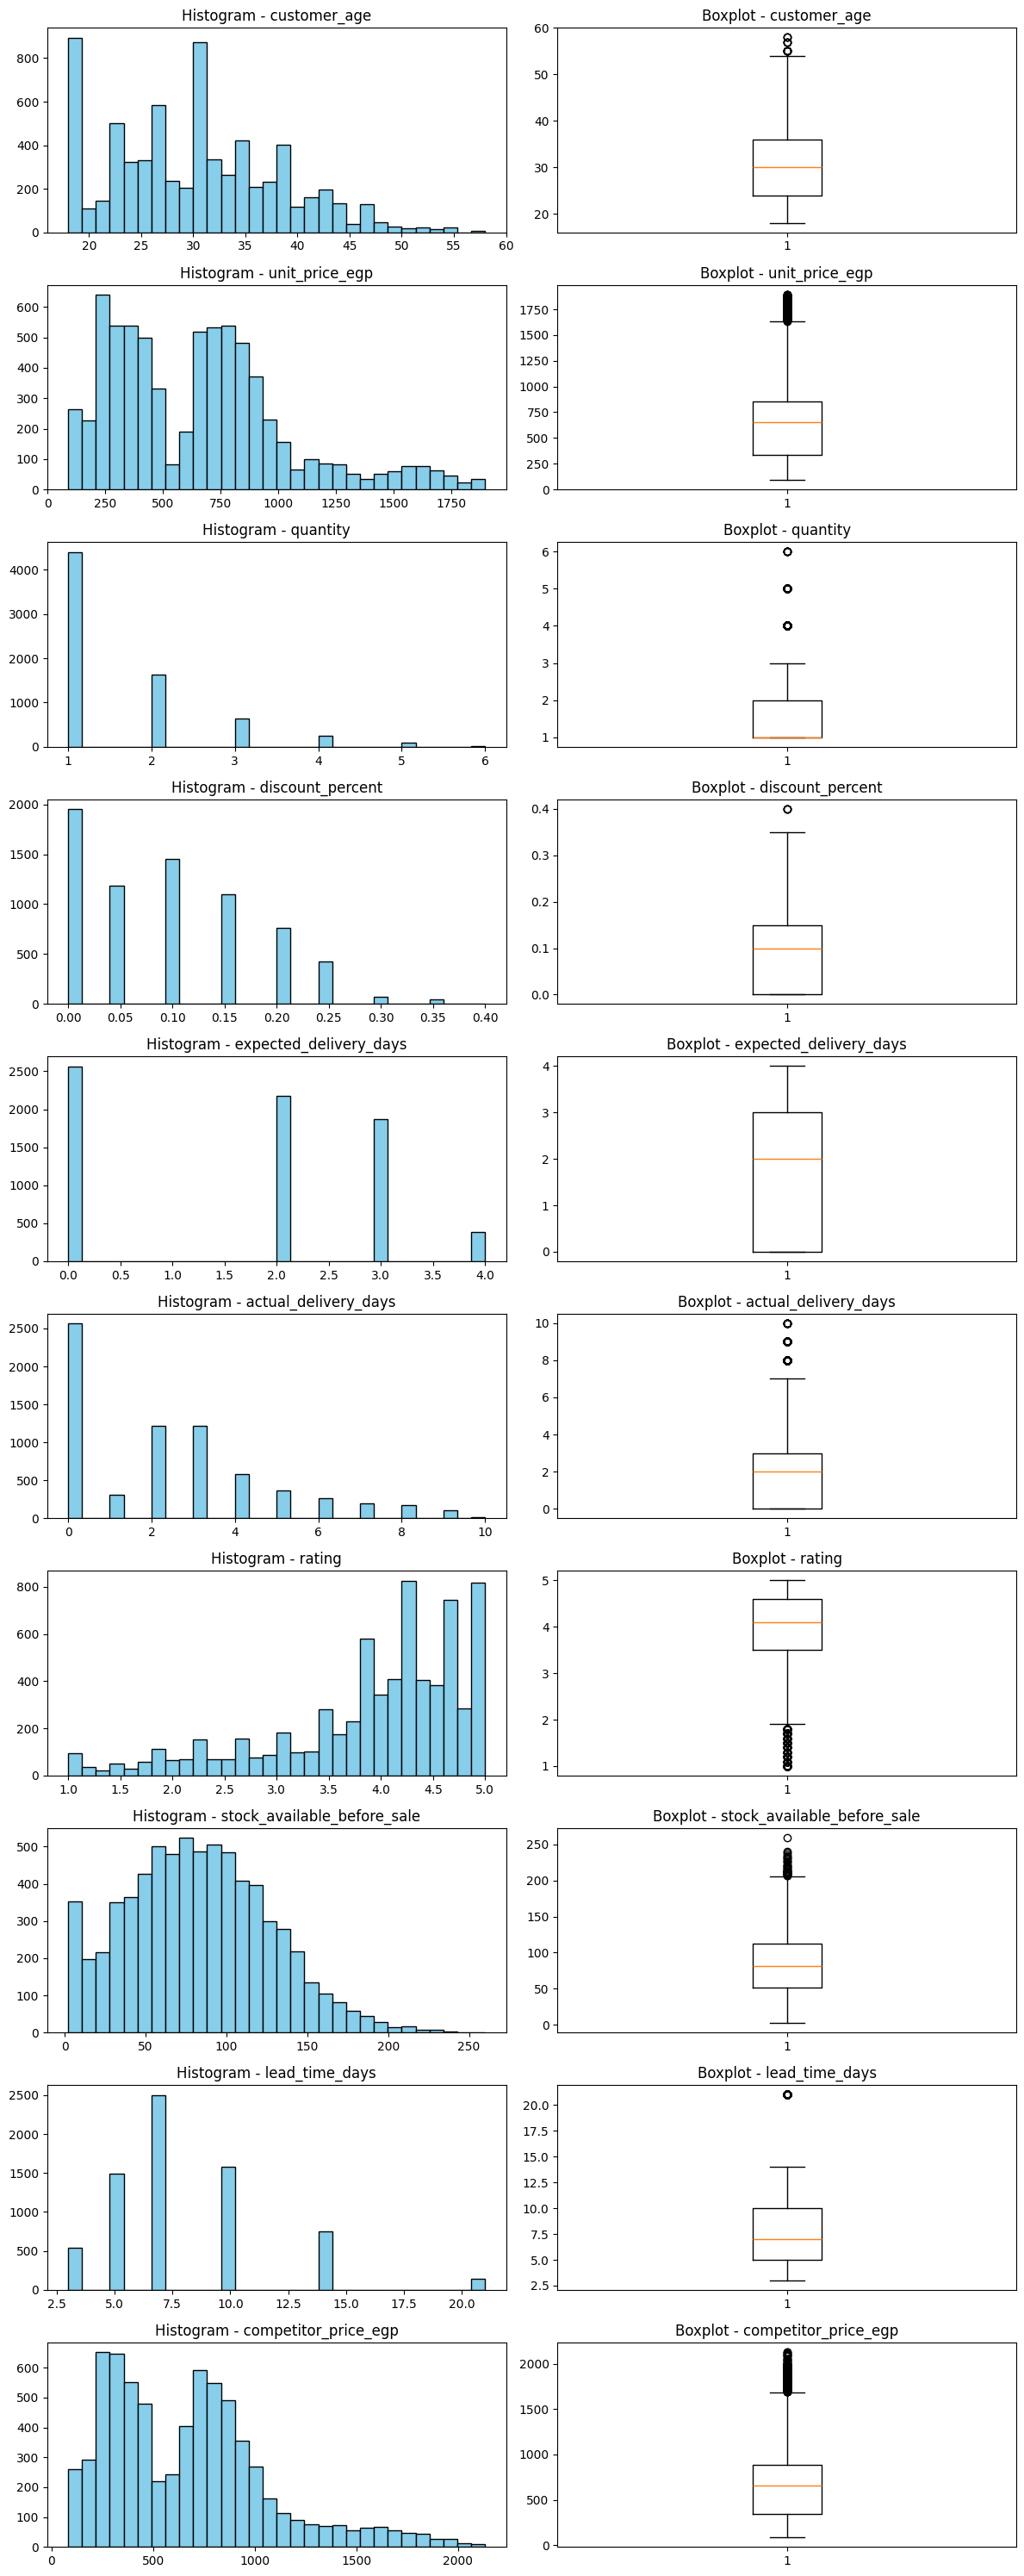

In [42]:
# 2. Histograms + Boxplots
fig, axes = plt.subplots(len(numeric_cols), 2, figsize=(12, 30))

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[i, 0].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black')
    axes[i, 0].set_title(f'Histogram - {col}')
    
    # Boxplot
    axes[i, 1].boxplot(df[col].dropna(), vert=True)
    axes[i, 1].set_title(f'Boxplot - {col}')

plt.tight_layout()
plt.show()

In [43]:
# 3. IQR method to detect outliers
print("\n=== Outliers using IQR Method ===\n")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")


=== Outliers using IQR Method ===

customer_age: 21 outliers
unit_price_egp: 186 outliers
quantity: 332 outliers
discount_percent: 4 outliers
expected_delivery_days: 0 outliers
actual_delivery_days: 290 outliers
rating: 344 outliers
stock_available_before_sale: 40 outliers
lead_time_days: 138 outliers
competitor_price_egp: 195 outliers


**Insight - Outliers Detection**

- Histograms and Boxplots were used to inspect the distribution of numeric columns.
- IQR method was applied to detect potential outliers.
- Extreme values appear mainly in unit_price_egp, quantity, and stock_available_before_sale.
- These values represent real high-value orders or bulk purchases (VIP / large orders).
- Decision: Keep all extreme values. No rows were deleted and no capping was applied.
- Reason: Removing them would distort revenue and sales analysis.

In [44]:
# 6.8 Feature Engineering

# 1. Gross Revenue
df['gross_revenue_egp'] = df['unit_price_egp'] * df['quantity']

# 2. Discount Amount
df['discount_amount_egp'] = df['gross_revenue_egp'] * df['discount_percent']

# 3. Net Revenue
df['net_revenue_egp'] = df['gross_revenue_egp'] - df['discount_amount_egp']

# 4. Delivery Delay
df['delivery_delay_days'] = df['actual_delivery_days'] - df['expected_delivery_days']

# 5. On Time Flag
df['on_time_flag'] = df['delivery_delay_days'] <= 0

# 6. Price Gap
df['price_gap_egp'] = df['unit_price_egp'] - df['competitor_price_egp']

# 7. Price Gap Percent
df['price_gap_percent'] = (df['price_gap_egp'] / df['competitor_price_egp']) * 100

# 8. Customer Age Group
bins = [0, 18, 25, 35, 45, 55, 100]
labels = ['Under 18', '18-24', '25-34', '35-44', '45-54', '55+']
df['customer_age_group'] = pd.cut(df['customer_age'], bins=bins, labels=labels, right=False)

# 9. Order Time Features
df['order_month'] = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter
df['order_weekday'] = df['order_date'].dt.day_name()
# order_hour already created in step 6.2

# 10. Return Request Lag
df['return_request_lag_days'] = (df['return_request_date'] - df['order_date']).dt.days

# 11. Returned Flag (1/0)
df['returned_flag'] = (df['returned'] == 'Yes').astype(int)

# Check the new columns in a clean table
new_features = [
    'gross_revenue_egp', 'discount_amount_egp', 'net_revenue_egp',
    'delivery_delay_days', 'on_time_flag', 'price_gap_egp',
    'price_gap_percent', 'customer_age_group', 'order_month',
    'order_quarter', 'order_weekday', 'order_hour',
    'return_request_lag_days', 'returned_flag'
]

print("New features created successfully:")
display(df[new_features].head(10))

New features created successfully:


,gross_revenue_egp,discount_amount_egp,net_revenue_egp,delivery_delay_days,on_time_flag,price_gap_egp,price_gap_percent,customer_age_group,order_month,order_quarter,order_weekday,order_hour,return_request_lag_days,returned_flag
0,864.60,43.2300,821.3700,0,True,-12.86,-2.888849,25-34,1,1,Wednesday,13,NaN,0
1,292.84,43.9260,248.9140,0,True,10.46,7.693439,35-44,1,1,Wednesday,14,NaN,0
2,133.38,0.0000,133.3800,0,True,-17.41,-11.545858,25-34,1,1,Wednesday,15,NaN,0
3,1332.12,266.4240,1065.6960,0,True,42.21,6.766050,25-34,1,1,Wednesday,15,2.0,1
4,1462.04,0.0000,1462.0400,0,True,-127.85,-8.041437,25-34,1,1,Wednesday,15,NaN,0
5,217.32,21.7320,195.5880,0,True,-29.57,-11.976994,25-34,1,1,Wednesday,18,NaN,0
6,3230.56,807.6400,2422.9200,0,True,45.43,5.960300,25-34,1,1,Wednesday,19,NaN,0
7,299.13,74.7825,224.3475,0,True,28.56,10.555494,25-34,1,1,Wednesday,20,NaN,0
8,458.14,91.6280,366.5120,0,True,-9.28,-3.893434,45-54,1,1,Wednesday,20,NaN,0
9,352.21,88.0525,264.1575,0,True,-22.70,-6.054786,25-34,1,1,Wednesday,20,NaN,0


**Insight - Feature Engineering**

All required features were created:
- Gross_Revenue_EGP, Discount_Amount_EGP, Net_Revenue_EGP
- Delivery_Delay_Days and On_Time_Flag
- Price_Gap_EGP and Price_Gap_Percent
- Customer_Age_Group
- Order_Month, Order_Quarter, Order_Weekday, Order_Hour
- Return_Request_Lag_Days
- Returned_Flag (1/0)

These features will be used in the bivariate analysis.

In [45]:
# 6.9 Final Quality Check

print("=== Final Quality Check ===\n")

# 1. Shape comparison
print("Shape before cleaning:", raw_df.shape)
print("Shape after cleaning:", df.shape)


=== Final Quality Check ===

Shape before cleaning: (7000, 36)
Shape after cleaning: (7000, 50)


In [46]:
# 2. Info
print("\nData types and non-null counts:")
print(df.info())



Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 50 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   order_id                     7000 non-null   object        
 1   order_date                   7000 non-null   datetime64[ns]
 2   order_time                   7000 non-null   object        
 3   customer_id                  7000 non-null   object        
 4   customer_gender              7000 non-null   object        
 5   customer_age                 7000 non-null   int64         
 6   customer_area                7000 non-null   object        
 7   branch                       7000 non-null   object        
 8   sales_channel                7000 non-null   object        
 9   product_domain               7000 non-null   object        
 10  category                     7000 non-null   object        
 11  product_id

In [47]:
# 3. Missing values after cleaning
print("\nMissing values after cleaning:")
missing_after = df.isna().sum()
print(missing_after[missing_after > 0])



Missing values after cleaning:
return_request_date        5957
return_request_lag_days    5957
dtype: int64


In [48]:
# 4. Duplicates check
print("\nExact duplicates:", df.duplicated().sum())
print("Duplicate Order_ID:", df.duplicated(subset=['order_id']).sum())


Exact duplicates: 0
Duplicate Order_ID: 0


In [49]:
# 5. Key KPIs comparison
print("\n=== Key KPIs Comparison ===")
print("Total Orders (before):", len(raw_df))
print("Total Orders (after):", len(df))
print("Total Net Revenue (after):", round(df['net_revenue_egp'].sum(), 2))
print("Average Order Value (after):", round(df['net_revenue_egp'].mean(), 2))
print("Return Rate (after):", round(df['returned_flag'].mean() * 100, 2), "%")


=== Key KPIs Comparison ===
Total Orders (before): 7000
Total Orders (after): 7000
Total Net Revenue (after): 6432309.54
Average Order Value (after): 918.9
Return Rate (after): 14.9 %


In [50]:
# 6. Check derived columns
print("\n=== Derived Columns Check ===")
print("Gross Revenue - nulls:", df['gross_revenue_egp'].isna().sum())
print("Net Revenue - nulls:", df['net_revenue_egp'].isna().sum())
print("Delivery Delay - nulls:", df['delivery_delay_days'].isna().sum())
print("Price Gap - nulls:", df['price_gap_egp'].isna().sum())
print("Age Group - nulls:", df['customer_age_group'].isna().sum())
print("Returned Flag - unique values:", df['returned_flag'].unique())


=== Derived Columns Check ===
Gross Revenue - nulls: 0
Net Revenue - nulls: 0
Delivery Delay - nulls: 0
Price Gap - nulls: 0
Age Group - nulls: 0
Returned Flag - unique values: [0 1]


In [51]:
# 7. Save clean dataset
df.to_csv("Project1_Clean_Orders.csv", index=False)
print("\nClean dataset saved as: Project1_Clean_Orders.csv")


Clean dataset saved as: Project1_Clean_Orders.csv


In [52]:
# === Build Project1_Data_Quality_Audit.xlsx ===

import pandas as pd

# 1) Missing values BEFORE cleaning 
missing_before = pd.DataFrame({
    'Missing_Count': raw_df.isna().sum(),
    'Missing_Percent': raw_df.isna().mean().mul(100).round(2)
}).reset_index().rename(columns={'index': 'Column'})
missing_before = missing_before[missing_before['Missing_Count'] > 0].sort_values(
    'Missing_Percent', ascending=False
)

# 2) Missing values AFTER cleaning
missing_after_df = pd.DataFrame({
    'Missing_Count': df.isna().sum(),
    'Missing_Percent': df.isna().mean().mul(100).round(2)
}).reset_index().rename(columns={'index': 'Column'})
missing_after_df = missing_after_df[missing_after_df['Missing_Count'] > 0].sort_values(
    'Missing_Percent', ascending=False
)

# 3) Duplicates summary
duplicates_summary = pd.DataFrame({
    'Check': ['Exact Duplicate Rows (before)', 'Duplicate Order_ID (before)',
              'Exact Duplicate Rows (after)', 'Duplicate Order_ID (after)'],
    'Count': [
        raw_df.duplicated().sum(),
        raw_df.duplicated(subset=['Order_ID']).sum(),
        df.duplicated().sum(),
        df.duplicated(subset=['order_id']).sum()
    ]
})

# 4) Outlier counts per numeric column (IQR method) — reuses numeric_cols from section 6.7
outlier_rows = []
for col in numeric_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        'Column': col, 'Outlier_Count': n_outliers,
        'Lower_Bound': round(lower, 2), 'Upper_Bound': round(upper, 2),
        'Decision': 'Kept (valid VIP/bulk values)'
    })
outliers_summary = pd.DataFrame(outlier_rows)

# 5) Row-count impact
row_count_impact = pd.DataFrame({
    'Stage': ['Before Cleaning', 'After Cleaning'],
    'Row_Count': [len(raw_df), len(df)],
    'Column_Count': [raw_df.shape[1], df.shape[1]]
})

# 6) KPI comparison before/after
kpi_comparison = pd.DataFrame({
    'KPI': ['Total Orders', 'Total Net Revenue (EGP)', 'Average Order Value (EGP)', 'Return Rate (%)'],
    'Value': [
        len(df),
        round(df['net_revenue_egp'].sum(), 2),
        round(df['net_revenue_egp'].mean(), 2),
        round(df['returned_flag'].mean() * 100, 2)
    ]
})

# 7) Write everything to one Excel file with multiple sheets
with pd.ExcelWriter("Project1_Data_Quality_Audit.xlsx", engine="openpyxl") as writer:
    data_quality_summary.to_excel(writer, sheet_name="Initial_Audit", index=False)
    missing_before.to_excel(writer, sheet_name="Missing_Before", index=False)
    missing_after_df.to_excel(writer, sheet_name="Missing_After", index=False)
    audit_summary.to_excel(writer, sheet_name="Missing_Value_Decisions", index=False)
    duplicates_summary.to_excel(writer, sheet_name="Duplicates", index=False)
    outliers_summary.to_excel(writer, sheet_name="Outliers", index=False)
    row_count_impact.to_excel(writer, sheet_name="Row_Count_Impact", index=False)
    kpi_comparison.to_excel(writer, sheet_name="KPI_Comparison", index=False)

print("Saved: Project1_Data_Quality_Audit.xlsx")

Saved: Project1_Data_Quality_Audit.xlsx


**Insight - Final Quality Check**

- Row count remained the same before and after cleaning (no rows were deleted).
- Missing values are only in return-related columns (correctly Not Applicable) and rating.
- No duplicate rows or duplicate Order_IDs were found.
- All derived features were created successfully and contain valid values.
- Clean dataset was exported as clean_orders.csv for the rest of the team.

# 9. Complete Univariate EDA

Univariate EDA is performed for all 36 original dataset columns.
The analysis method is selected according to the data type:
identifiers, dates/time, categorical, numerical, and text variables.

Engineered features are kept separate from the original dataset columns.

# Univariate EDA - Gross Revenue EGP

Gross Revenue Summary:
count    7000.000000
mean     1016.790727
std       876.590454
min        88.460000
25%       443.592500
50%       771.340000
75%      1289.880000
max      8128.950000
Name: gross_revenue_egp, dtype: float64


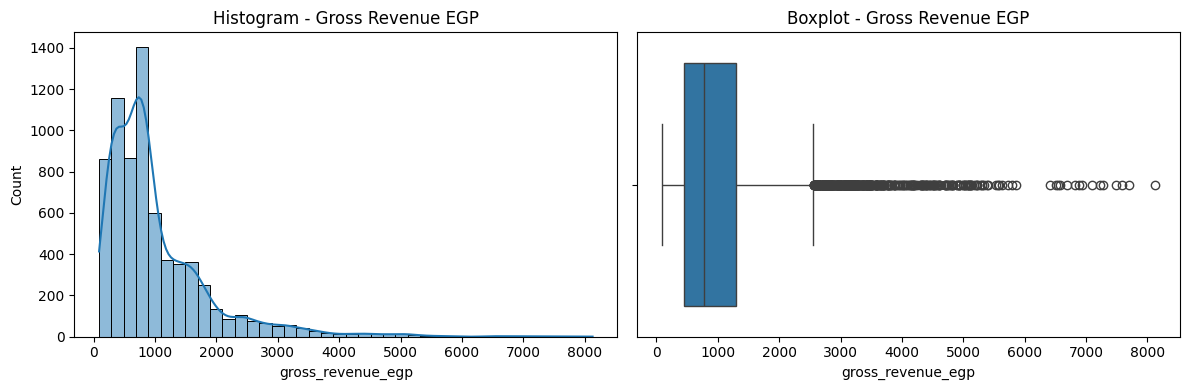

In [ ]:
print("Gross Revenue Summary:")
print(df['gross_revenue_egp'].describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['gross_revenue_egp'], bins=40, kde=True)
plt.title('Histogram - Gross Revenue EGP')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['gross_revenue_egp'])
plt.title('Boxplot - Gross Revenue EGP')

plt.tight_layout()
plt.show()

**Insight - Gross Revenue**

- Gross revenue is right-skewed.
- Most orders have relatively low revenue, while a small number of orders have very high values.
- These high values represent large or expensive orders and should be kept.

# Univariate EDA - Net Revenue EGP

count    7000.000000
mean      918.901362
std       797.365339
min        72.192000
25%       402.492000
50%       696.253500
75%      1165.596000
max      8128.950000
Name: net_revenue_egp, dtype: float64


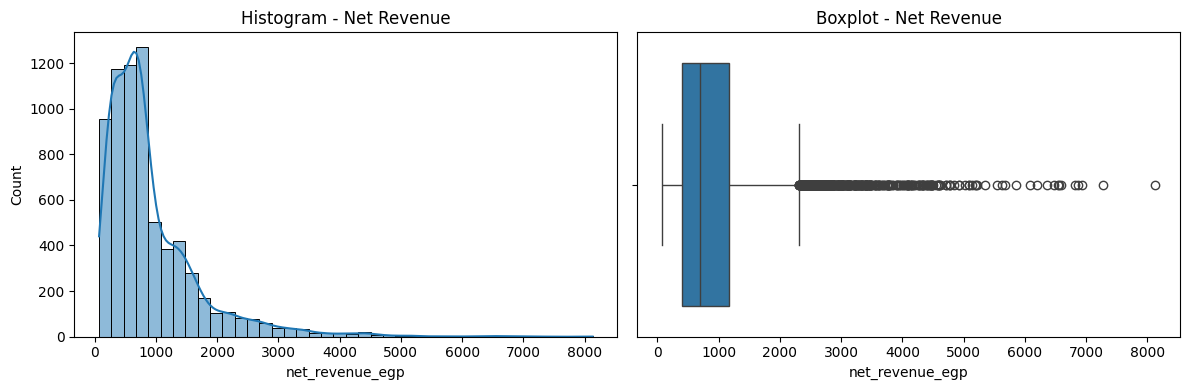

In [ ]:
print(df['net_revenue_egp'].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['net_revenue_egp'], bins=40, kde=True)
plt.title('Histogram - Net Revenue')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['net_revenue_egp'])
plt.title('Boxplot - Net Revenue')
plt.tight_layout()
plt.show()

**Insight - Net Revenue**

Net revenue follows a similar right-skewed pattern as gross revenue. Discounts reduce the values but the overall distribution shape remains the same.

# Univariate - Discount Amount EGP

count    7000.000000
mean       97.889365
std       142.775216
min         0.000000
25%         0.000000
50%        52.051750
75%       129.861500
max      1420.320000
Name: discount_amount_egp, dtype: float64


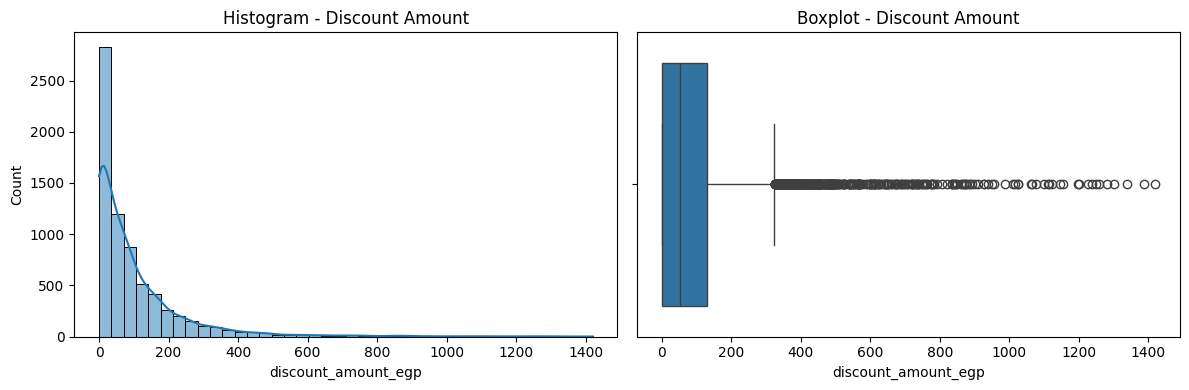

In [ ]:
print(df['discount_amount_egp'].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['discount_amount_egp'], bins=40, kde=True)
plt.title('Histogram - Discount Amount')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['discount_amount_egp'])
plt.title('Boxplot - Discount Amount')
plt.tight_layout()
plt.show()

**Insight - Discount Amount**

Most discounts are small. A smaller group of orders received higher discount amounts.

# Univariate EDA - Delivery Delay Days

count    7000.000000
mean        0.632429
std         1.559747
min        -1.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         6.000000
Name: delivery_delay_days, dtype: float64


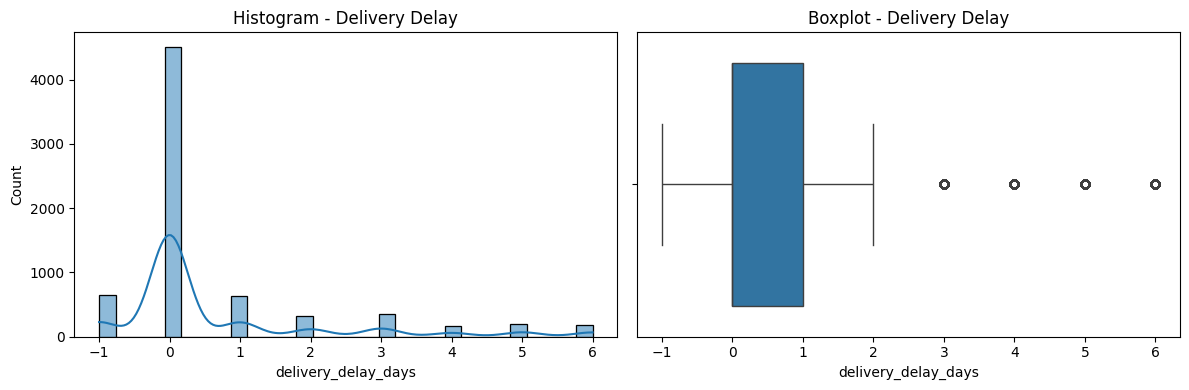

In [ ]:
print(df['delivery_delay_days'].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['delivery_delay_days'], bins=30, kde=True)
plt.title('Histogram - Delivery Delay')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['delivery_delay_days'])
plt.title('Boxplot - Delivery Delay')
plt.tight_layout()
plt.show()

**Insight - Delivery Delay**

Many orders are delivered on time or early (negative or zero delay). Some orders show clear positive delays that need operational attention.

# Univariate - Price Gap EGP

count    7000.000000
mean      -18.778381
std        57.661988
min      -290.910000
25%       -48.022500
50%       -12.645000
75%        16.292500
max       171.550000
Name: price_gap_egp, dtype: float64


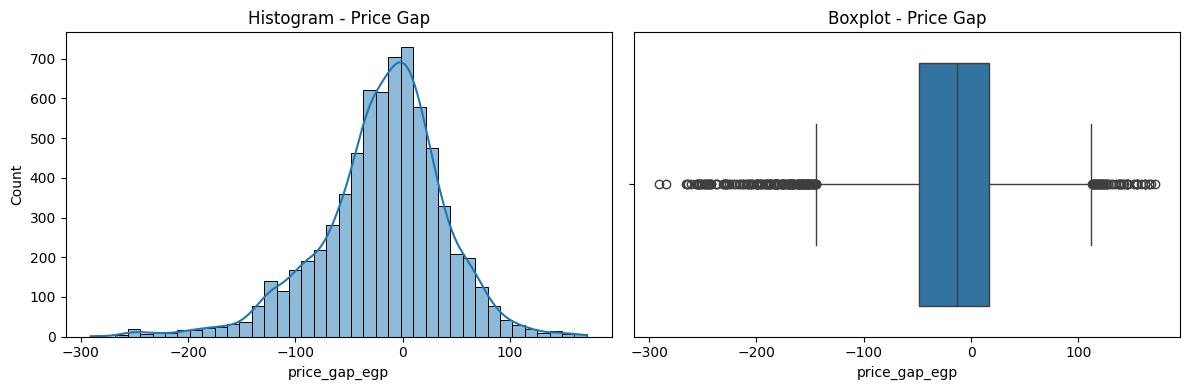

In [ ]:
print(df['price_gap_egp'].describe())

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['price_gap_egp'], bins=40, kde=True)
plt.title('Histogram - Price Gap')
plt.subplot(1, 2, 2)
sns.boxplot(x=df['price_gap_egp'])
plt.title('Boxplot - Price Gap')
plt.tight_layout()
plt.show()

**Insight - Price Gap**

The price gap is centered near zero. Some products are priced higher than competitors and some are lower.

# Univariate - Customer Age Group

customer_age_group
25-34       3036
18-24       1976
35-44       1663
45-54        304
55+           21
Under 18       0
Name: count, dtype: int64


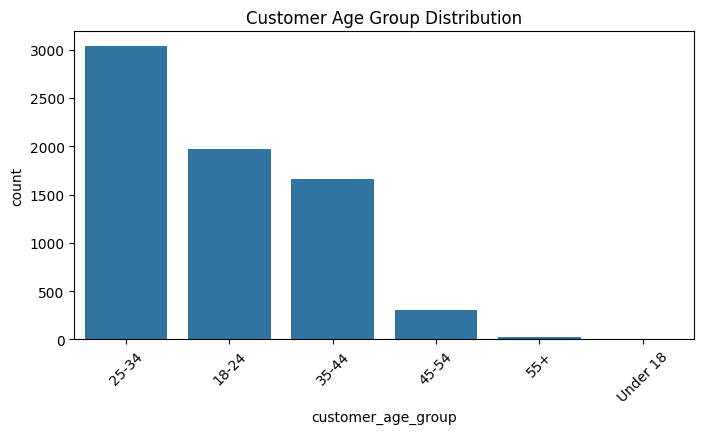

In [ ]:
print(df['customer_age_group'].value_counts())

plt.figure(figsize=(8, 4))
sns.countplot(x=df['customer_age_group'], order=df['customer_age_group'].value_counts().index)
plt.title('Customer Age Group Distribution')
plt.xticks(rotation=45)
plt.show()

**Insight - Customer Age Group**

The largest customer groups are 25-34 and 18-24. Older age groups represent a smaller share of orders.

# Univariate - Returned Flag

returned_flag
0    5957
1    1043
Name: count, dtype: int64
Return Rate: 14.9 %


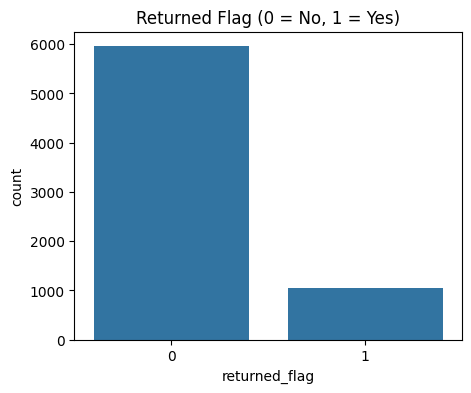

In [ ]:
print(df['returned_flag'].value_counts())
print("Return Rate:", round(df['returned_flag'].mean() * 100, 2), "%")

plt.figure(figsize=(5, 4))
sns.countplot(x=df['returned_flag'])
plt.title('Returned Flag (0 = No, 1 = Yes)')
plt.show()

**Insight - Returned Flag**

Most orders were not returned. The overall return rate is relatively low.

# Univariate - Order Month

order_month
1     842
2     698
3     884
4     694
5     722
6     733
7     413
8     432
9     402
10    338
11    408
12    434
Name: count, dtype: int64


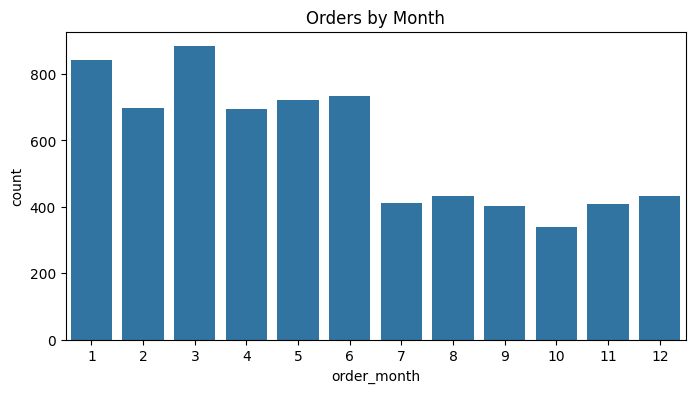

In [ ]:
print(df['order_month'].value_counts().sort_index())

plt.figure(figsize=(8, 4))
sns.countplot(x=df['order_month'])
plt.title('Orders by Month')
plt.show()

**Insight - Order Month**

Order volume varies across months. Some months show higher activity than others.

# Univariate - Order Weekday

order_weekday
Monday        896
Tuesday       906
Wednesday     901
Thursday     1138
Friday       1145
Saturday     1101
Sunday        913
Name: count, dtype: int64


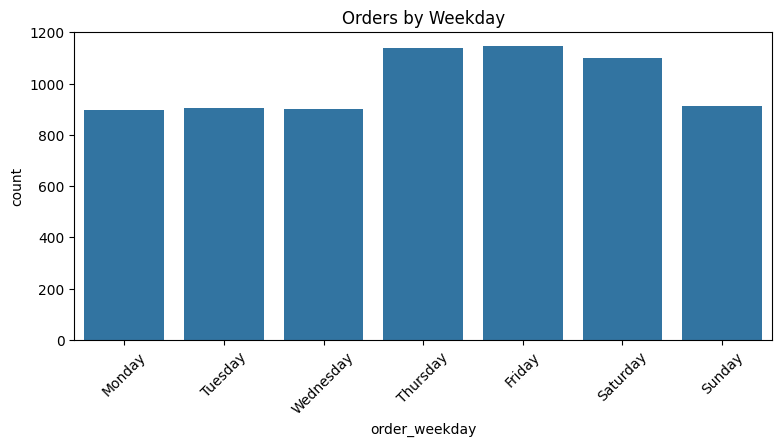

In [ ]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
print(df['order_weekday'].value_counts().reindex(order))

plt.figure(figsize=(9, 4))
sns.countplot(x=df['order_weekday'], order=order)
plt.title('Orders by Weekday')
plt.xticks(rotation=45)
plt.show()

**Insight - Order Weekday**

Orders are distributed across the week with some days showing higher activity.

# Univariate - Order Hour

order_hour
10    148
11    406
12    502
13    446
14    443
15    456
16    540
17    643
18    726
19    727
20    840
21    586
22    357
23    180
Name: count, dtype: int64


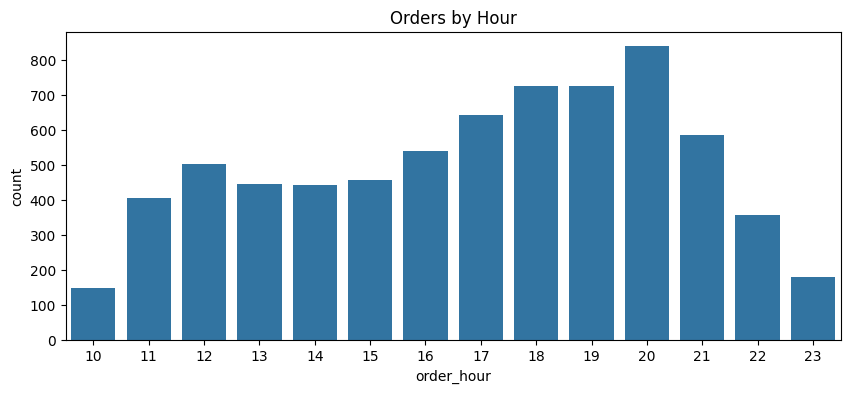

In [ ]:
print(df['order_hour'].value_counts().sort_index())

plt.figure(figsize=(10, 4))
sns.countplot(x=df['order_hour'])
plt.title('Orders by Hour')
plt.show()

**Insight - Order Hour**

Orders are concentrated in certain hours of the day. Peak hours can help with staffing and marketing timing.

### Univariate Analysis: Order ID

Order_ID is an identifier variable. We examine the number of unique IDs and check for duplicated or repeated order identifiers.

In [63]:
print("Unique Order_IDs:", df["order_id"].nunique())
print("Duplicate Order_ID rows:", df["order_id"].duplicated(keep=False).sum())

display(
    df["order_id"]
    .value_counts()
    .head(10)
    .rename_axis("Order_ID")
    .reset_index(name="frequency")
)

Unique Order_IDs: 7000
Duplicate Order_ID rows: 0


,Order_ID,frequency
0,ORD0007000,1
1,ORD0000001,1
2,ORD0000002,1
3,ORD0000003,1
4,ORD0000004,1
5,ORD0000005,1
6,ORD0000006,1
7,ORD0000007,1
8,ORD0000008,1
9,ORD0000009,1


### Univariate Analysis: Customer ID

Customer_ID is an identifier variable. We examine the number of unique customers and the frequency of orders associated with each customer.

In [64]:
print("Unique Customer_IDs:", df["customer_id"].nunique())

display(
    df["customer_id"]
    .value_counts()
    .head(10)
    .rename_axis("Customer_ID")
    .reset_index(name="order_count")
)

Unique Customer_IDs: 1133


,Customer_ID,order_count
0,C00001,106
1,C00002,75
2,C00003,63
3,C00005,55
4,C00004,51
5,C00007,43
6,C00008,43
7,C00010,42
8,C00006,36
9,C00011,36


### Univariate Analysis: Order Date

Order_Date is a date variable. We examine the date range and the distribution of orders over time.

In [65]:
print("Minimum Order Date:", df["order_date"].min())
print("Maximum Order Date:", df["order_date"].max())

order_monthly = (
    df["order_date"]
    .dt.to_period("M")
    .value_counts()
    .sort_index()
)

display(order_monthly.rename("order_count").reset_index())

Minimum Order Date: 2025-01-01 00:00:00
Maximum Order Date: 2026-06-26 00:00:00


,order_date,order_count
0,2025-01,452
1,2025-02,325
2,2025-03,445
3,2025-04,344
4,2025-05,343
5,2025-06,412
6,2025-07,413
7,2025-08,432
8,2025-09,402
9,2025-10,338


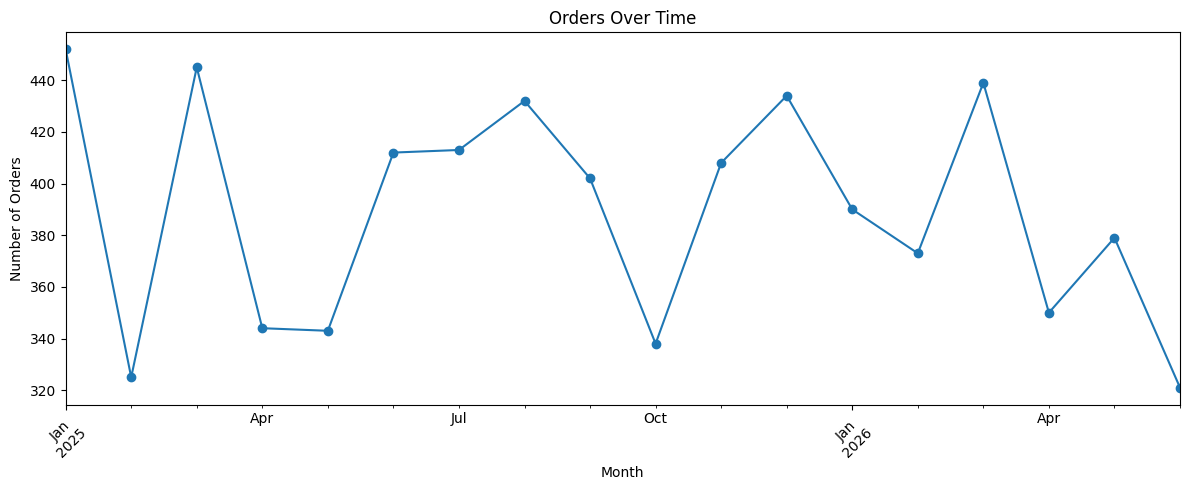

In [66]:
plt.figure(figsize=(12, 5))

order_monthly.plot(kind="line", marker="o")

plt.title("Orders Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Univariate Analysis - Order Time

Order_Time is a time variable. We examine the distribution of orders across different hours of the day.

In [67]:
display(
    df["order_hour"]
    .value_counts()
    .sort_index()
    .rename_axis("Order Hour")
    .reset_index(name="Order Count")
)

,Order Hour,Order Count
0,10,148
1,11,406
2,12,502
3,13,446
4,14,443
5,15,456
6,16,540
7,17,643
8,18,726
9,19,727


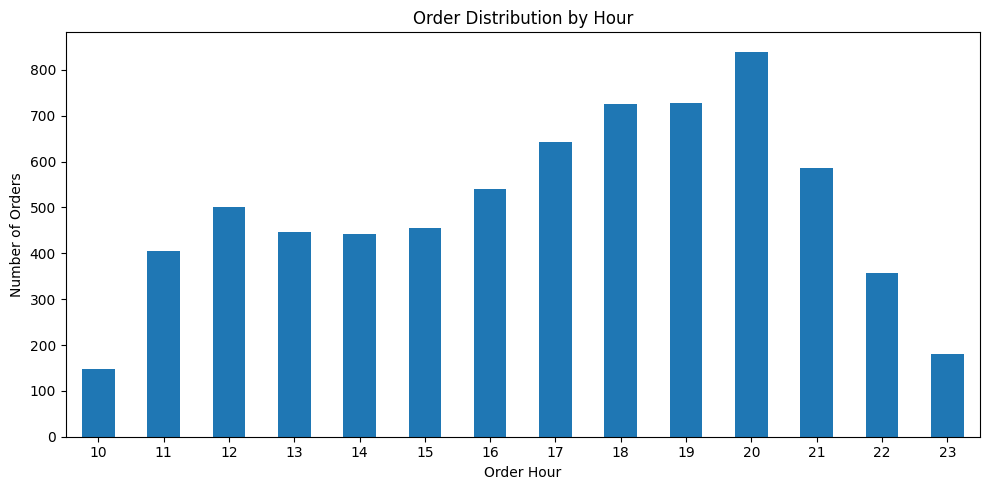

In [68]:
plt.figure(figsize=(10, 5))

df["order_hour"].value_counts().sort_index().plot(kind="bar")

plt.title("Order Distribution by Hour")
plt.xlabel("Order Hour")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Univariate EDA — Product Domain

Product Domain is a categorical variable. We will examine the number and percentage of orders in each product domain.

In [69]:
product_domain_summary = df['product_domain'].value_counts().reset_index()

product_domain_summary.columns = [
    'product_domain',
    'order_count'
]

product_domain_summary['percentage'] = (
    product_domain_summary['order_count']
    / product_domain_summary['order_count'].sum()
    * 100
)

product_domain_summary

,product_domain,order_count,percentage
0,Fashion,3206,45.800000
1,Beauty,1190,17.000000
2,Footwear,857,12.242857
3,Electronics Accessories,674,9.628571
4,Home & Kitchen,602,8.600000
5,Stationery & Books,359,5.128571
6,Stationery,112,1.600000


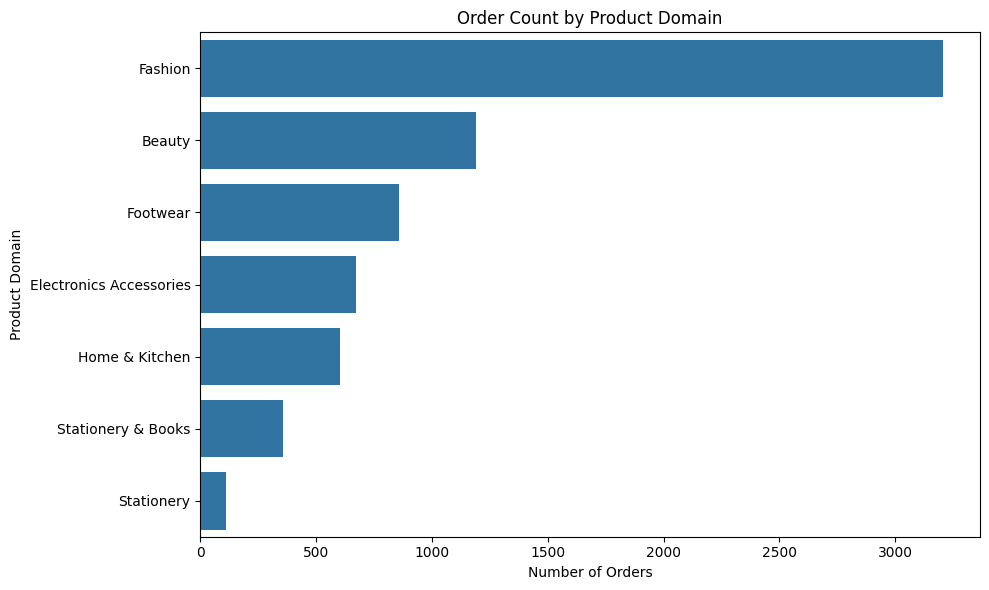

In [70]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_domain_summary,
    x='order_count',
    y='product_domain'
)

plt.title('Order Count by Product Domain')
plt.xlabel('Number of Orders')
plt.ylabel('Product Domain')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_product_domain.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insight

The most common product domain is fashion, accounting for approximately 45.8% of the orders. The least represented domain is stationery. This indicates that the dataset is more concentrated in certain product domains.

## Univariate EDA — Category

In [71]:
category_summary = df['category'].value_counts().reset_index()

category_summary.columns = [
    'category',
    'order_count'
]

category_summary['percentage'] = (
    category_summary['order_count']
    / category_summary['order_count'].sum()
    * 100
)

category_summary

,category,order_count,percentage
0,Men Clothing,1681,24.014286
1,Women Clothing,1525,21.785714
2,Mobile Accessories,536,7.657143
3,Fragrance,448,6.400000
4,Makeup,292,4.171429
5,Stationery,291,4.157143
6,Skin Care,256,3.657143
7,Home Decor,221,3.157143
8,Hair Care,194,2.771429
9,Kitchenware,193,2.757143


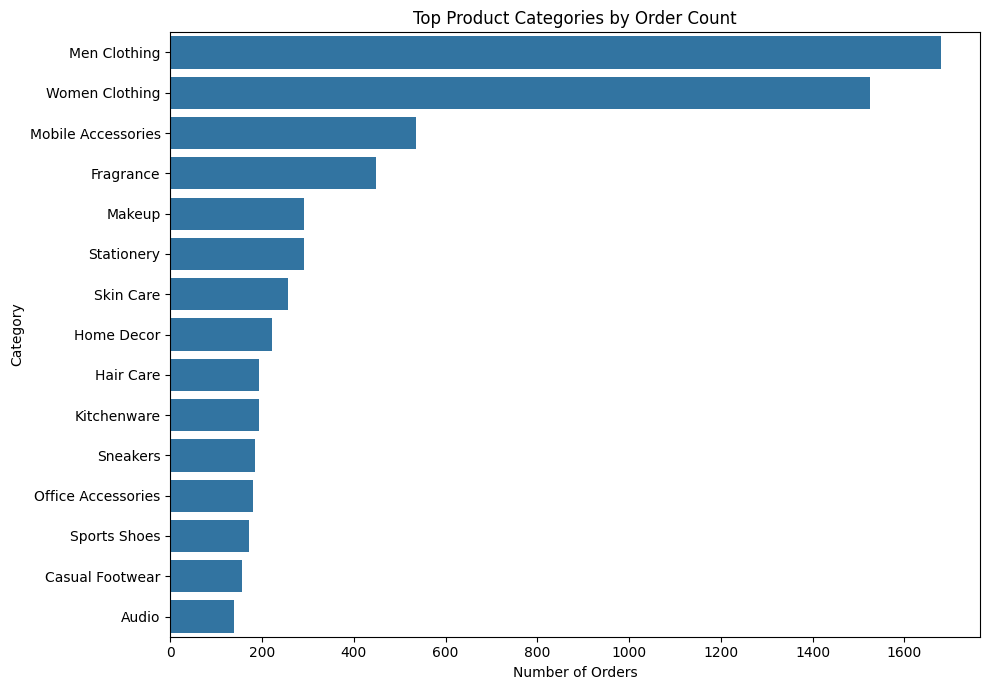

In [72]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=category_summary.head(15),
    x='order_count',
    y='category'
)

plt.title('Top Product Categories by Order Count')
plt.xlabel('Number of Orders')
plt.ylabel('Category')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_category.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Univariate EDA — Product ID

In [73]:
product_id_summary = {
    'total_rows': len(df),
    'unique_product_ids': df['product_id'].nunique(),
    'duplicate_product_id_rows': df['product_id'].duplicated().sum(),
    'missing_product_ids': df['product_id'].isna().sum()
}

pd.DataFrame([product_id_summary])

,total_rows,unique_product_ids,duplicate_product_id_rows,missing_product_ids
0,7000,43,6957,0


In [74]:
product_id_frequency = (
    df['product_id']
    .value_counts()
    .head(15)
    .reset_index()
)

product_id_frequency.columns = [
    'product_id',
    'order_count'
]

product_id_frequency

,product_id,order_count
0,F006,328
1,F010,302
2,F003,297
3,F008,276
4,F001,271
5,F004,264
6,F007,262
7,F002,262
8,F005,259
9,F009,233


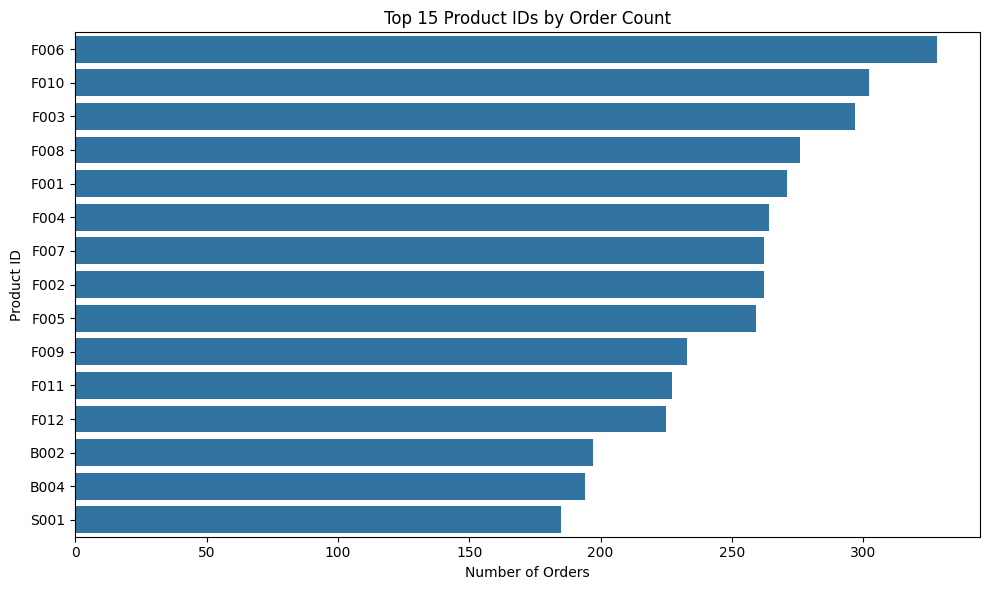

In [75]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=product_id_frequency,
    x='order_count',
    y='product_id'
)

plt.title('Top 15 Product IDs by Order Count')
plt.xlabel('Number of Orders')
plt.ylabel('Product ID')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_product_id.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Univariate EDA — Product Name

In [76]:
product_name_summary = (
    df['product_name']
    .value_counts()
    .head(15)
    .reset_index()
)

product_name_summary.columns = [
    'product_name',
    'order_count'
]

product_name_summary

,product_name,order_count
0,Linen Shirt,328
1,Casual Dress,302
2,Slim Fit Jeans,297
3,Basic Blouse,276
4,Oversized Cotton T-Shirt,271
5,Polo Shirt,264
6,Summer Dress,262
7,Basic Cotton T-Shirt,262
8,Men Hoodie,259
9,Wide Leg Pants,233


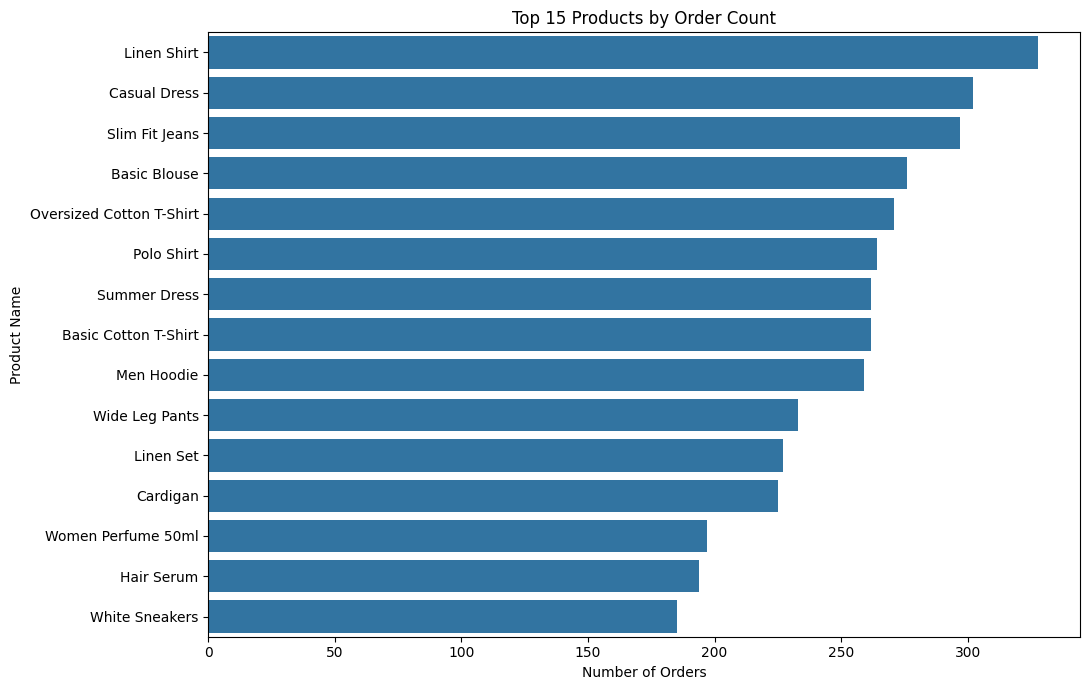

In [77]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=product_name_summary,
    x='order_count',
    y='product_name'
)

plt.title('Top 15 Products by Order Count')
plt.xlabel('Number of Orders')
plt.ylabel('Product Name')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_product_name.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Univariate EDA — Brand

In [78]:
brand_summary = df['brand'].value_counts().reset_index()

brand_summary.columns = [
    'brand',
    'order_count'
]

brand_summary['percentage'] = (
    brand_summary['order_count']
    / brand_summary['order_count'].sum()
    * 100
)

brand_summary

,brand,order_count,percentage
0,Alexstyle,832,11.885714
1,Urbanwear,682,9.742857
2,Northcoast,555,7.928571
3,Trendhub,501,7.157143
4,Novafashion,495,7.071429
5,Stepup,466,6.657143
6,Aura,327,4.671429
7,Voltix,324,4.628571
8,Glowcare,315,4.500000
9,Paperly,309,4.414286


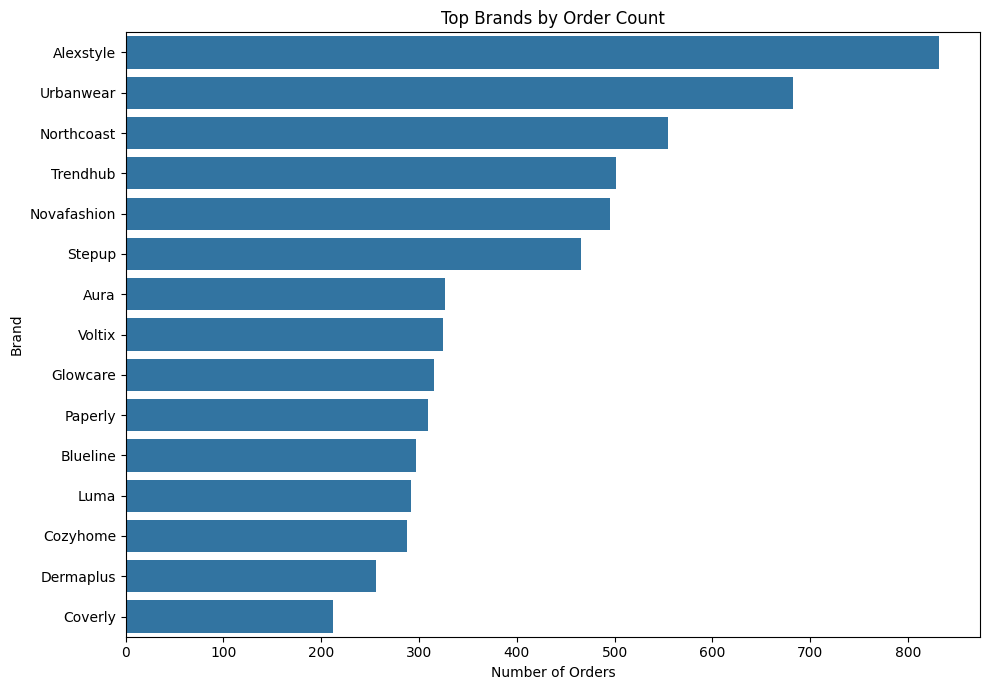

In [79]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=brand_summary.head(15),
    x='order_count',
    y='brand'
)

plt.title('Top Brands by Order Count')
plt.xlabel('Number of Orders')
plt.ylabel('Brand')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_brand.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Univariate EDA — Unit Price

In [80]:
df['unit_price_egp'].describe()

count    7000.000000
mean      656.619353
std       384.970886
min        88.460000
25%       336.607500
50%       654.685000
75%       856.380000
max      1896.150000
Name: unit_price_egp, dtype: float64

In [81]:
unit_price_stats = pd.DataFrame({
    'mean': [df['unit_price_egp'].mean()],
    'median': [df['unit_price_egp'].median()],
    'std': [df['unit_price_egp'].std()],
    'min': [df['unit_price_egp'].min()],
    'q1': [df['unit_price_egp'].quantile(0.25)],
    'q3': [df['unit_price_egp'].quantile(0.75)],
    'max': [df['unit_price_egp'].max()]
})

unit_price_stats

,mean,median,std,min,q1,q3,max
0,656.619353,654.685,384.970886,88.46,336.6075,856.38,1896.15


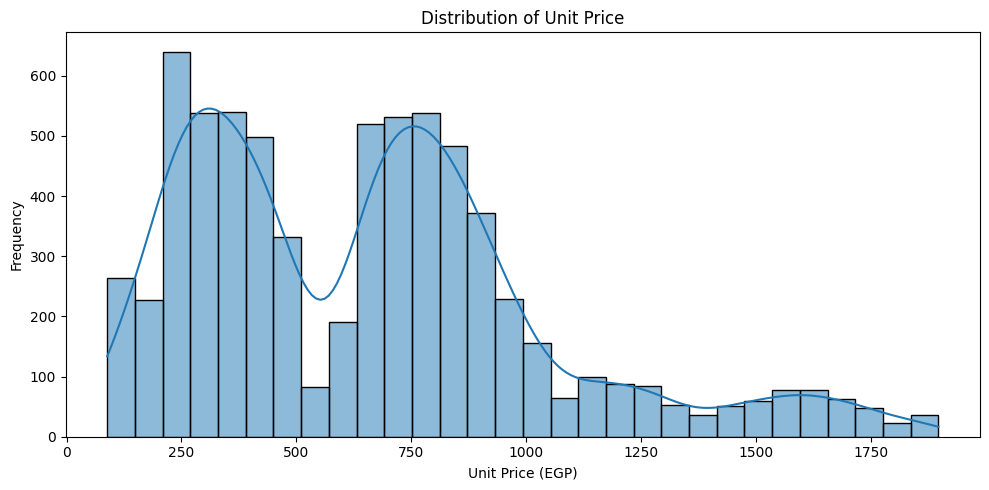

In [82]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='unit_price_egp',
    bins=30,
    kde=True
)

plt.title('Distribution of Unit Price')
plt.xlabel('Unit Price (EGP)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_unit_price_hist.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

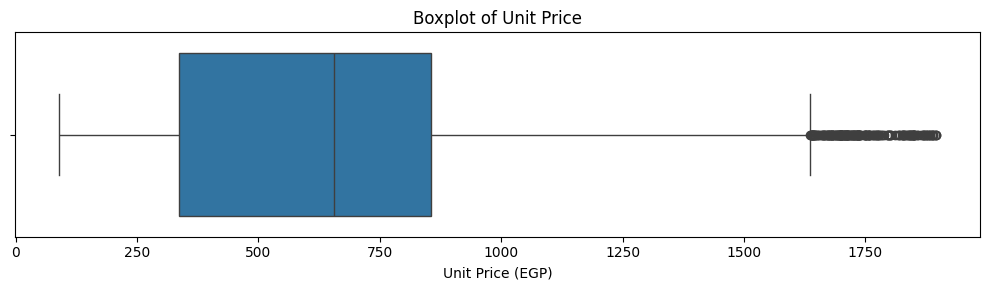

In [83]:
plt.figure(figsize=(10, 3))

sns.boxplot(
    x=df['unit_price_egp']
)

plt.title('Boxplot of Unit Price')
plt.xlabel('Unit Price (EGP)')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_unit_price_boxplot.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Univariate EDA — Quantity

In [84]:
quantity_stats = pd.DataFrame({
    'mean': [df['quantity'].mean()],
    'median': [df['quantity'].median()],
    'std': [df['quantity'].std()],
    'min': [df['quantity'].min()],
    'q1': [df['quantity'].quantile(0.25)],
    'q3': [df['quantity'].quantile(0.75)],
    'max': [df['quantity'].max()]
})

quantity_stats

,mean,median,std,min,q1,q3,max
0,1.571429,1.0,0.894674,1,1.0,2.0,6


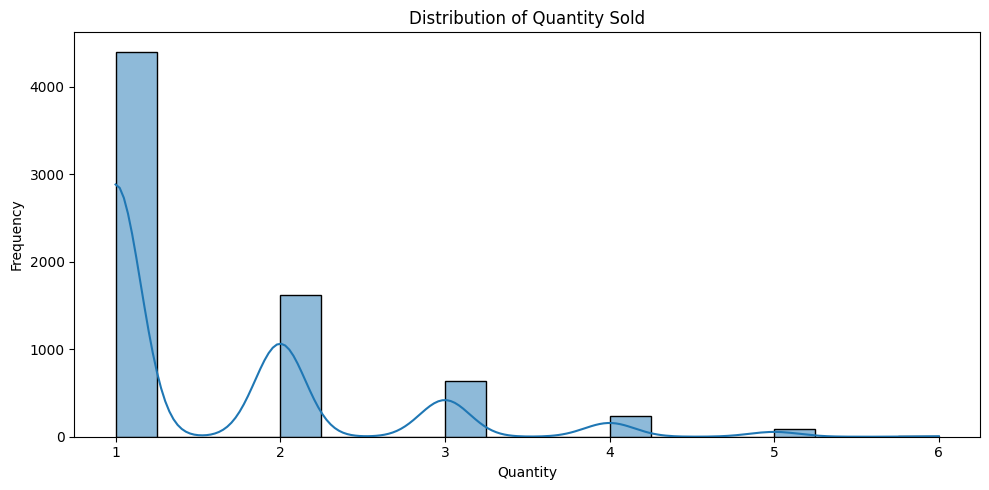

In [85]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='quantity',
    bins=20,
    kde=True
)

plt.title('Distribution of Quantity Sold')
plt.xlabel('Quantity')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_quantity.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Univariate EDA — Discount Percent

In [86]:
discount_stats = pd.DataFrame({
    'mean': [df['discount_percent'].mean()],
    'median': [df['discount_percent'].median()],
    'std': [df['discount_percent'].std()],
    'min': [df['discount_percent'].min()],
    'q1': [df['discount_percent'].quantile(0.25)],
    'q3': [df['discount_percent'].quantile(0.75)],
    'max': [df['discount_percent'].max()]
})

discount_stats

,mean,median,std,min,q1,q3,max
0,0.095243,0.1,0.082992,0.0,0.0,0.15,0.4


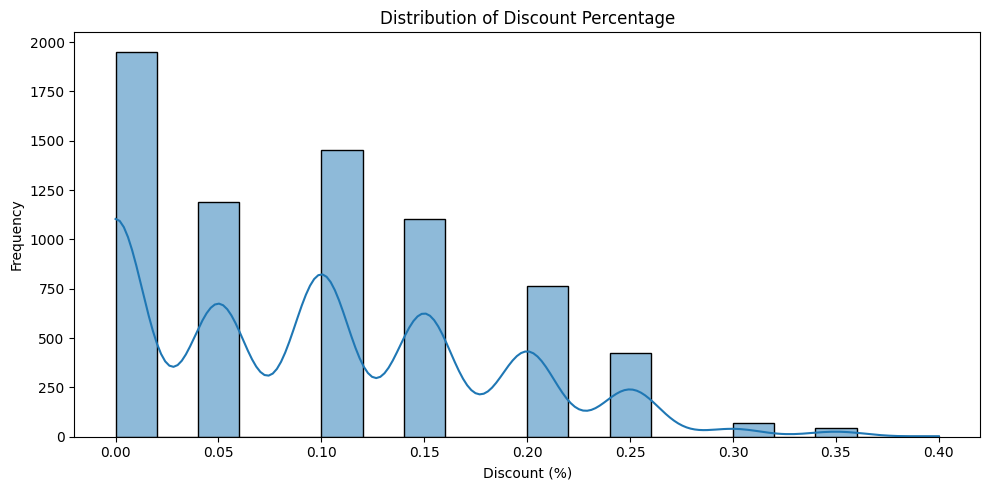

In [87]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='discount_percent',
    bins=20,
    kde=True
)

plt.title('Distribution of Discount Percentage')
plt.xlabel('Discount (%)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_discount_percent.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Univariate EDA — Competitor Price

In [88]:
competitor_price_stats = pd.DataFrame({
    'mean': [df['competitor_price_egp'].mean()],
    'median': [df['competitor_price_egp'].median()],
    'std': [df['competitor_price_egp'].std()],
    'min': [df['competitor_price_egp'].min()],
    'q1': [df['competitor_price_egp'].quantile(0.25)],
    'q3': [df['competitor_price_egp'].quantile(0.75)],
    'max': [df['competitor_price_egp'].max()]
})

competitor_price_stats

,mean,median,std,min,q1,q3,max
0,675.397734,657.99,399.726417,82.83,345.275,882.4775,2133.52


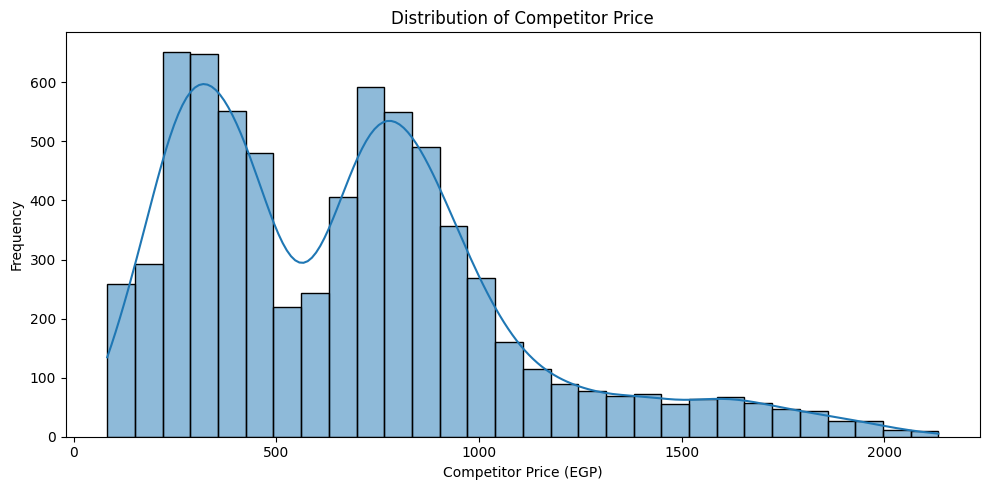

In [89]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x='competitor_price_egp',
    bins=30,
    kde=True
)

plt.title('Distribution of Competitor Price')
plt.xlabel('Competitor Price (EGP)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig(
    'visuals/univariate_competitor_price.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# UNIVARIATE EDA -Returned

Returned:
What is the distribution of returned and non-returned orders?

In [90]:
returned_summary = (
    df['returned']
    .value_counts(dropna=False)
    .rename_axis('returned')
    .reset_index(name='order_count')
)

returned_summary['percentage'] = (
    returned_summary['order_count'] / len(df) * 100
)

display(returned_summary)

,returned,order_count,percentage
0,No,5957,85.1
1,Yes,1043,14.9


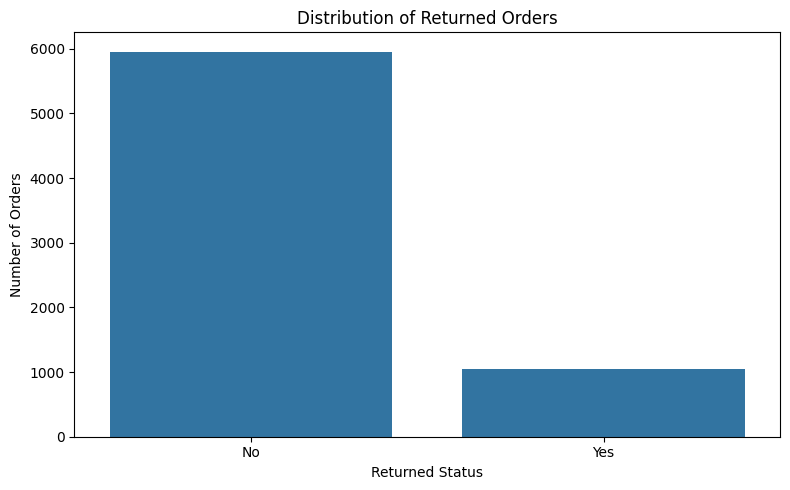

In [91]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=returned_summary,
    x='returned',
    y='order_count'
)

plt.title('Distribution of Returned Orders')
plt.xlabel('Returned Status')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Most orders were not returned (5,957 orders, 85.10%), while 1,043 orders (14.90%) were returned.
- **Business meaning:** The overall return rate is 14.90%, meaning that approximately one in every seven orders was returned.
- **Possible reason:** Returns may be related to product issues, incorrect expectations, delivery problems, or customer preferences.
- **Recommendation:** Monitor the return rate and investigate the main return reasons to identify opportunities to reduce avoidable returns.
- **Limitation:** The Returned status shows whether an order was returned but does not explain the reason behind the return.

# UNIVARIATE EDA -Returned Reason


In [92]:
returned_orders = df[
    df['returned'].astype(str).str.strip().str.lower() == 'yes'
].copy()

return_reason_summary = (
    returned_orders['return_reason_category']
    .value_counts(dropna=False)
    .rename_axis('return_reason_category')
    .reset_index(name='order_count')
)

return_reason_summary['percentage'] = (
    return_reason_summary['order_count']
    / len(returned_orders) * 100
)

display(return_reason_summary)

,return_reason_category,order_count,percentage
0,Late Delivery,360,34.515820
1,Wrong Size,209,20.038351
2,Quality Issue,152,14.573346
3,Not As Described,93,8.916587
4,Damaged Packaging,74,7.094919
5,Changed Mind,66,6.327900
6,Wrong Item,50,4.793864
7,Defective Item,26,2.492809
8,Missing Item,13,1.246405


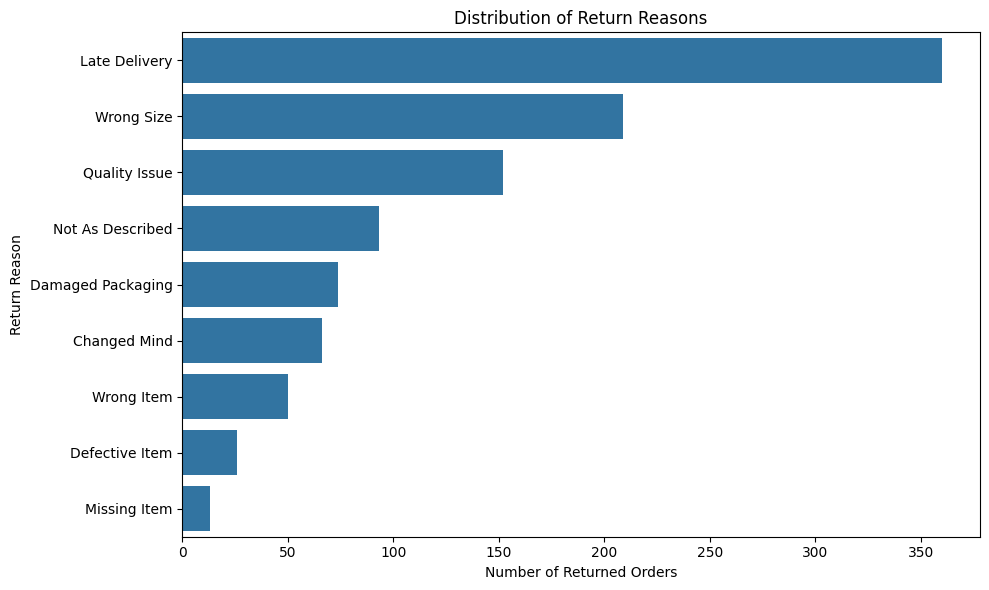

In [93]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=return_reason_summary,
    y='return_reason_category',
    x='order_count'
)

plt.title('Distribution of Return Reasons')
plt.xlabel('Number of Returned Orders')
plt.ylabel('Return Reason')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** The most common return reason was late delivery, representing 360 of returned orders.
- **Business meaning:** This reason represents an important source of customer dissatisfaction.
- **Possible reason:** The pattern may indicate issues related to product quality, fulfillment, or customer expectations.
- **Recommendation:** Investigate the highest-frequency return reason and identify corrective actions.
- **Limitation:** Recorded return reasons may not capture every underlying cause of a return.

# UNIVARIATE EDA -Return Complaint Text

In [94]:

# Return Complaint Text — Correct Missing Handling


complaints = df.loc[
    df['returned'] == 'Yes',
    'return_complaint_text'
].replace('nan', np.nan).dropna()

missing_complaints = df['return_complaint_text'].replace(
    'nan', np.nan
).isna().sum()

missing_complaints_pct = missing_complaints / len(df) * 100

print(f"Missing complaint texts: {missing_complaints}")
print(f"Missing percentage: {missing_complaints_pct:.2f}%")

print(f"Available complaint texts: {len(complaints)}")

Missing complaint texts: 5957
Missing percentage: 85.10%
Available complaint texts: 1043


In [95]:
df['complaint_text_length'] = (
    df['return_complaint_text']
    .fillna('')
    .astype(str)
    .str.len()
)

display(
    df['complaint_text_length'].describe()
)

count    7000.000000
mean        9.829429
std        17.550573
min         3.000000
25%         3.000000
50%         3.000000
75%         3.000000
max       105.000000
Name: complaint_text_length, dtype: float64

In [96]:
import re
from collections import Counter

complaints = (
    returned_orders['return_complaint_text']
    .dropna()
    .astype(str)
    .str.lower()
)

text = ' '.join(complaints)

words = re.findall(r'\b[a-zA-Z]{3,}\b', text)

stopwords = {
    'the', 'and', 'was', 'were', 'for', 'with',
    'this', 'that', 'but', 'not', 'had', 'have',
    'has', 'from', 'very', 'they', 'their',
    'order', 'product'
}

filtered_words = [
    word for word in words
    if word not in stopwords
]

word_counts = Counter(filtered_words)

common_words = pd.DataFrame(
    word_counts.most_common(15),
    columns=['word', 'frequency']
)

display(common_words)

,word,frequency
0,deltaship,100
1,delivery,40
2,delayed,40
3,customer,40
4,longer,40
5,needed,40
6,item,40
7,alex,16
8,courier,16
9,express,11


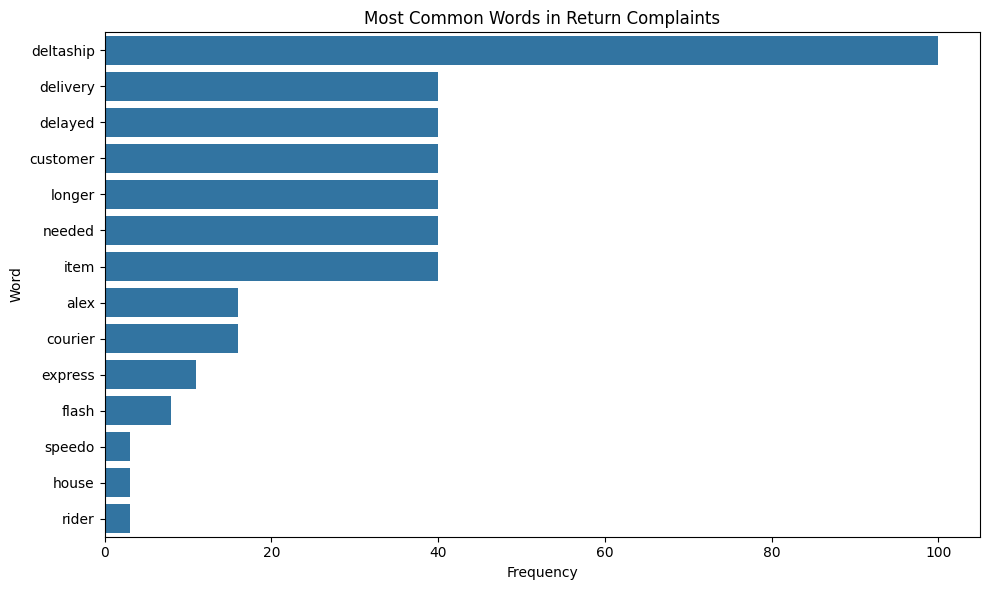

In [97]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=common_words,
    y='word',
    x='frequency'
)

plt.title('Most Common Words in Return Complaints')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Return complaint text is available for the 1,043 returned orders, while 5,957 orders (85.10%) have no complaint text because they were not returned. The most frequent complaint themes relate to sizing, product description or appearance, product quality, delivery delays, and packaging problems.
- **Business meaning:** The complaint text provides additional context beyond the return-reason category and highlights recurring customer pain points.
- **Possible reason:** Customers may experience differences between product expectations and the actual item, sizing problems, quality issues, or delivery and packaging problems.
- **Recommendation:** Use complaint themes together with return reasons to prioritize improvements in sizing information, product descriptions, quality control, delivery operations, and packaging.
- **Limitation:** Complaint text is available only for returned orders, and word frequency alone does not capture the full context of each complaint.

# Univariate EDA - Return Complaint Text

In [98]:
return_dates = pd.to_datetime(
    df['return_request_date'],
    errors='coerce'
)

print("Minimum date:", return_dates.min())
print("Maximum date:", return_dates.max())

monthly_returns = (
    return_dates
    .dropna()
    .dt.to_period('M')
    .value_counts()
    .sort_index()
    .rename_axis('month')
    .reset_index(name='return_requests')
)

monthly_returns['month'] = monthly_returns['month'].astype(str)

display(monthly_returns)

Minimum date: 2025-01-03 00:00:00
Maximum date: 2026-07-03 00:00:00


,month,return_requests
0,2025-01,54
1,2025-02,54
2,2025-03,61
3,2025-04,65
4,2025-05,51
5,2025-06,65
6,2025-07,63
7,2025-08,61
8,2025-09,50
9,2025-10,50


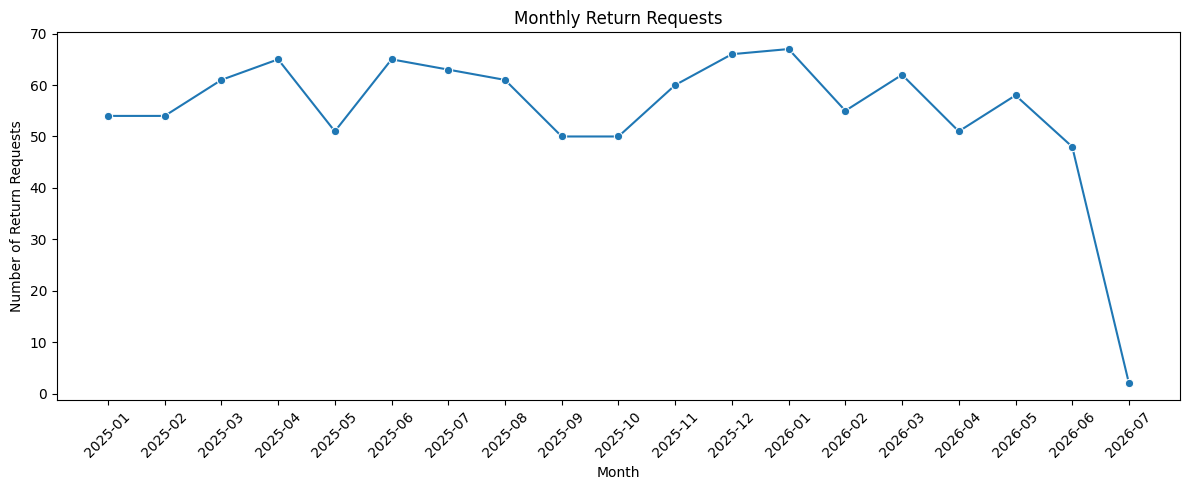

In [99]:
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_returns,
    x='month',
    y='return_requests',
    marker='o'
)

plt.title('Monthly Return Requests')
plt.xlabel('Month')
plt.ylabel('Number of Return Requests')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

- **What happened:** Return requests range from January 3, 2025 to July 3, 2026. The highest monthly number of return requests occurred in January 2026, with 67 requests.
- **Business meaning:** Return activity varies over time, with some months experiencing higher return volumes than others.
- **Possible reason:** Monthly differences may be related to order volume, product mix, promotions, or operational issues during specific periods.
- **Recommendation:** Investigate months with higher return activity alongside sales volume and return reasons to identify recurring patterns.
- **Limitation:** The number of return requests is influenced by the number of orders placed during each month.


# Univariate EDA — Refund Method

In [100]:
refund_summary = (
    returned_orders['refund_method']
    .value_counts(dropna=False)
    .rename_axis('refund_method')
    .reset_index(name='order_count')
)

refund_summary['percentage'] = (
    refund_summary['order_count']
    / len(returned_orders) * 100
)

display(refund_summary)

,refund_method,order_count,percentage
0,Original Payment,531,50.910834
1,Store Credit,260,24.928092
2,Cash Refund,158,15.148610
3,Exchange,94,9.012464


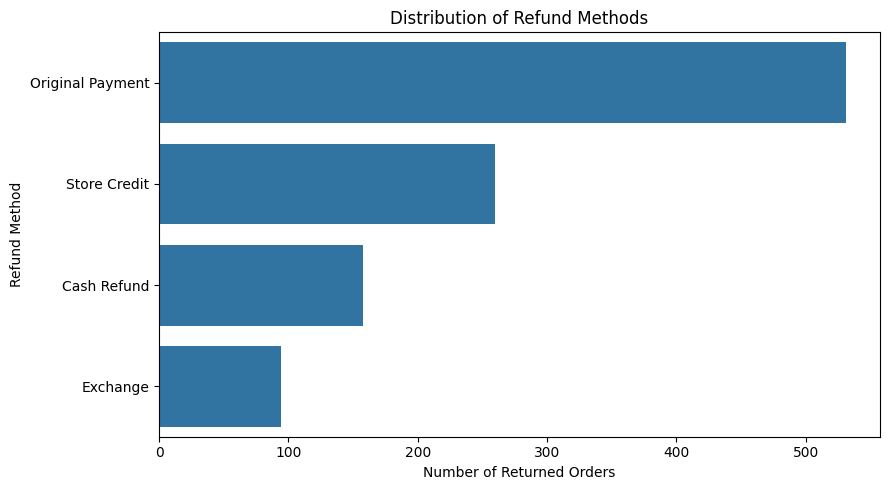

In [101]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=refund_summary,
    y='refund_method',
    x='order_count'
)

plt.title('Distribution of Refund Methods')
plt.xlabel('Number of Returned Orders')
plt.ylabel('Refund Method')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Original Payment was the most common refund method, used for 531 returned orders (50.91%). Store Credit was the second most common method at 24.93%, followed by Cash Refund at 15.15% and Exchange at 9.01%.
- **Business meaning:** Returning the refund through the original payment method is the dominant refund process.
- **Possible reason:** Customers may generally prefer receiving refunds through the same payment channel used for the original purchase.
- **Recommendation:** Ensure that the Original Payment refund process is efficient and reliable, while monitoring alternative refund options.
- **Limitation:** The dataset does not explain why a specific refund method was selected.


# Univariate EDA — Rating

In [102]:
rating_stats = df['rating'].describe()

display(rating_stats.to_frame(name='value'))

,value
count,7000.000000
mean,3.894029
std,0.943410
min,1.000000
25%,3.500000
50%,4.100000
75%,4.600000
max,5.000000


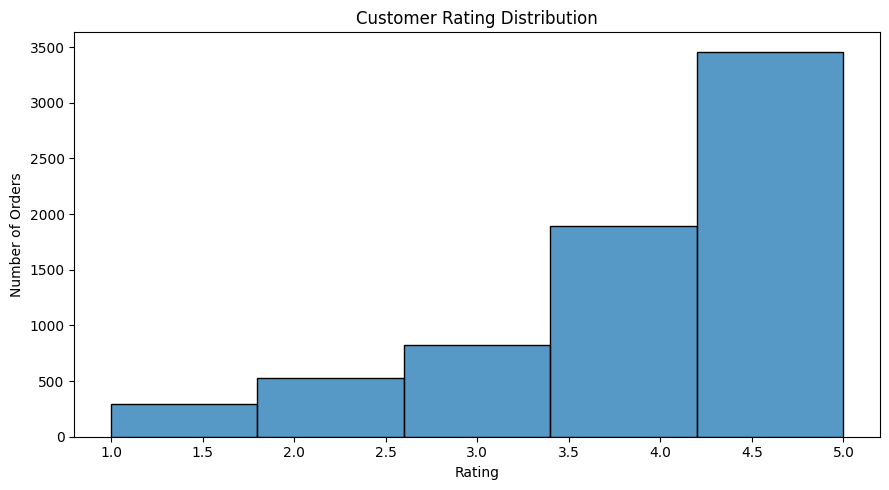

In [103]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=df,
    x='rating',
    bins=5
)

plt.title('Customer Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

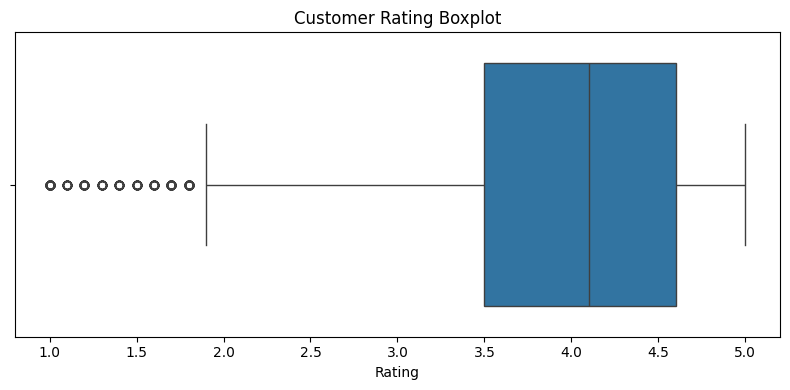

In [104]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df['rating']
)

plt.title('Customer Rating Boxplot')
plt.xlabel('Rating')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** The average customer rating was 3.89, with a median of 4.10 and a standard deviation of 0.94. Ratings ranged from 1 to 5, and the distribution is negatively skewed (skewness = -1.16).
- **Business meaning:** Overall customer ratings are relatively high, but the negative skew indicates that lower ratings form a smaller but important part of the distribution.
- **Possible reason:** Most customers may have satisfactory experiences, while lower ratings may be associated with issues such as returns, delivery delays, or product problems.
- **Recommendation:** Investigate low-rated orders together with return status, delivery delay, and complaint information to identify the main causes of dissatisfaction.
- **Limitation:** Ratings are subjective customer feedback and do not necessarily represent every customer's experience.


# Univariate EDA — Stock Available Before Sale

In [105]:
stock_stats = df['stock_available_before_sale'].describe()

display(stock_stats.to_frame(name='value'))

,value
count,7000.000000
mean,82.628143
std,44.302021
min,2.000000
25%,51.000000
50%,81.000000
75%,113.000000
max,260.000000


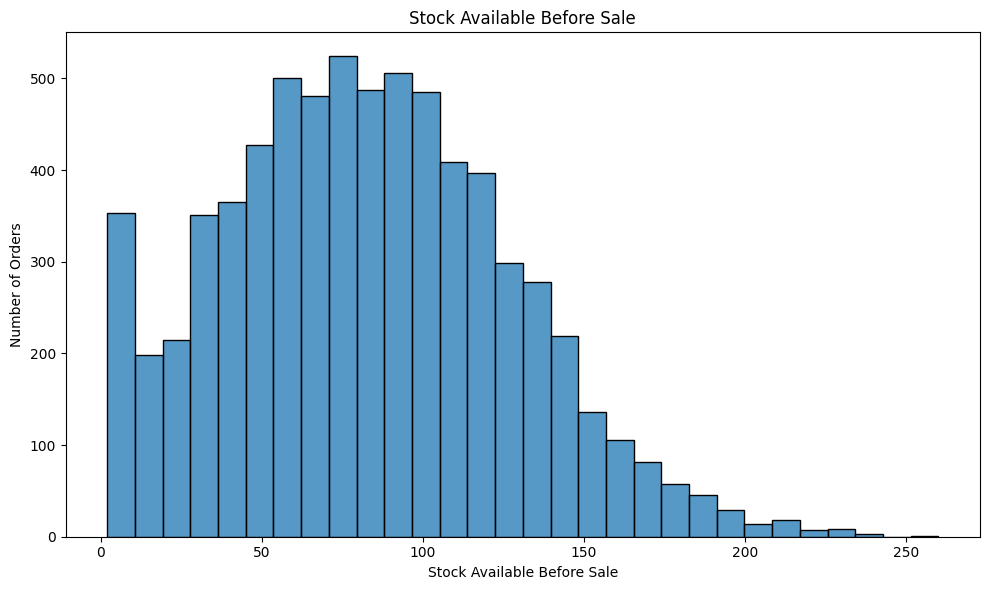

In [106]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='stock_available_before_sale',
    bins=30
)

plt.title('Stock Available Before Sale')
plt.xlabel('Stock Available Before Sale')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

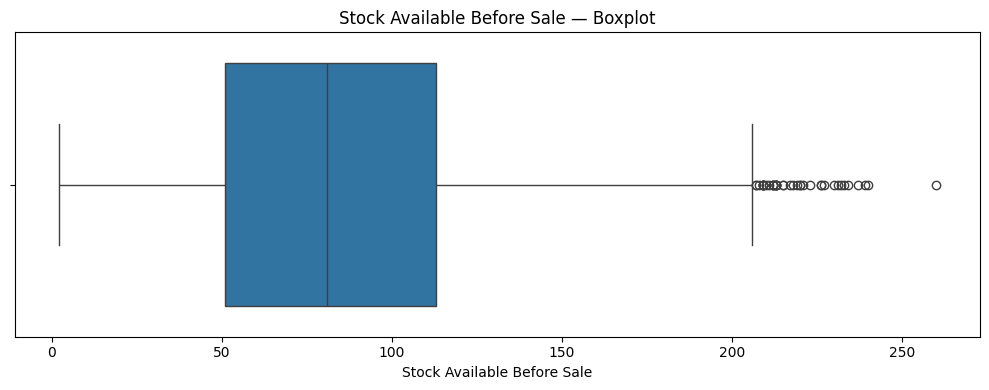

In [107]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df['stock_available_before_sale']
)

plt.title('Stock Available Before Sale — Boxplot')
plt.xlabel('Stock Available Before Sale')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Stock available before sale had a mean of 82.63 units and a median of 81 units, with values ranging from 2 to 260 units. The IQR method identified 40 potential outliers.
- **Business meaning:** Most orders were placed when a reasonable amount of stock was available, while a small number of observations had unusually high stock levels.
- **Possible reason:** These extreme values may reflect products with higher inventory levels or different replenishment patterns.
- **Recommendation:** Monitor very low stock levels together with quantity sold and supplier lead time to support inventory planning.
- **Limitation:** The variable represents stock available before an individual sale and does not show the complete inventory movement over time.


# Univariate EDA — Supplier

In [108]:
supplier_summary = (
    df['supplier']
    .value_counts(dropna=False)
    .rename_axis('supplier')
    .reset_index(name='order_count')
)

supplier_summary['percentage'] = (
    supplier_summary['order_count'] / len(df) * 100
)

display(supplier_summary)

,supplier,order_count,percentage
0,Imported Batch,1425,20.357143
1,Cairo Distributor,1278,18.257143
2,Cairo Textile Hub,1198,17.114286
3,Alex Local Factory,984,14.057143
4,Local Supplier,944,13.485714
5,In-House,628,8.971429
6,Official Distributor,543,7.757143


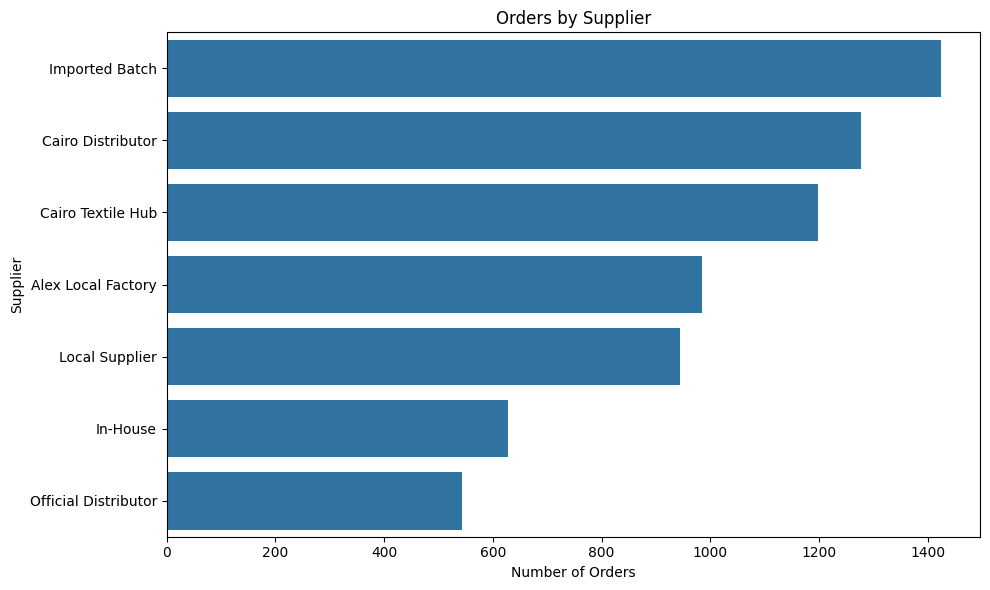

In [109]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=supplier_summary,
    y='supplier',
    x='order_count'
)

plt.title('Orders by Supplier')
plt.xlabel('Number of Orders')
plt.ylabel('Supplier')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Imported Batch had the highest number of orders linked to it, with 1,425 orders (20.36%), followed by Cairo Distributor with 1,278 orders (18.26%) and Cairo Textile Hub with 1,198 orders (17.11%).
- **Business meaning:** Supplier activity is concentrated among a few major suppliers, with Imported Batch representing the largest share.
- **Possible reason:** Some suppliers may provide products that have higher sales demand or a wider product range.
- **Recommendation:** Evaluate major suppliers together with lead time, product availability, cost, and quality before making sourcing decisions.
- **Limitation:** Order count alone does not measure supplier performance or profitability.

# Univariate EDA — Lead Time

In [110]:
lead_time_stats = df['lead_time_days'].describe()

display(lead_time_stats.to_frame(name='value'))

,value
count,7000.000000
mean,7.966286
std,3.503923
min,3.000000
25%,5.000000
50%,7.000000
75%,10.000000
max,21.000000


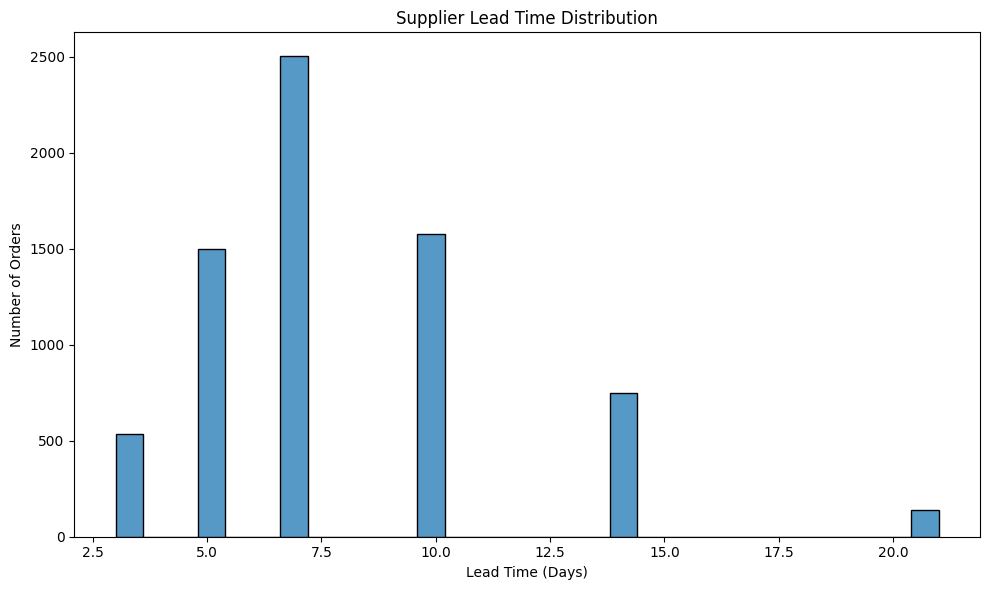

In [111]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x='lead_time_days',
    bins=30
)

plt.title('Supplier Lead Time Distribution')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

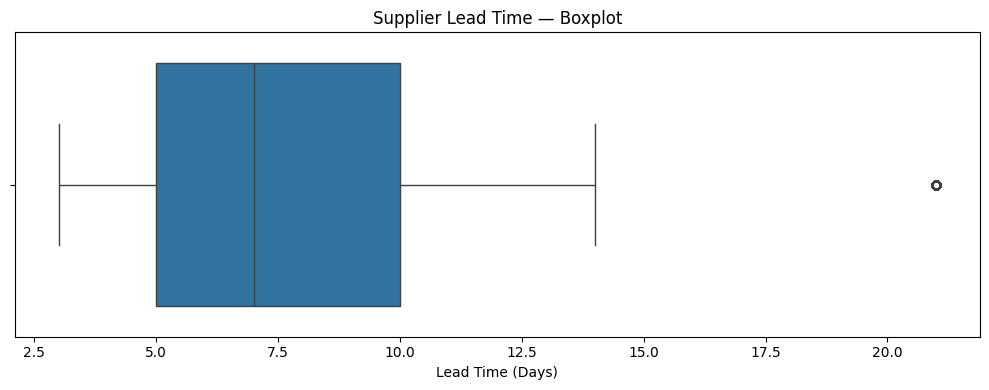

In [112]:
plt.figure(figsize=(10, 4))

sns.boxplot(
    x=df['lead_time_days']
)

plt.title('Supplier Lead Time — Boxplot')
plt.xlabel('Lead Time (Days)')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Supplier lead time averaged 7.97 days, with a median of 7 days and a range from 3 to 21 days. The IQR method identified 138 potential outliers.
- **Business meaning:** Most supplier lead times are concentrated around one week, but some orders require substantially longer lead times.
- **Possible reason:** Longer lead times may be related to supplier location, product type, sourcing method, or replenishment conditions.
- **Recommendation:** Monitor suppliers and products associated with unusually long lead times to reduce inventory planning risks.
- **Limitation:** Lead time does not by itself measure supplier reliability, cost, or product quality.


# Univariate EDA — Weather

In [113]:
weather_summary = (
    df['weather']
    .value_counts(dropna=False)
    .rename_axis('weather')
    .reset_index(name='order_count')
)

weather_summary['percentage'] = (
    weather_summary['order_count'] / len(df) * 100
)

display(weather_summary)

,weather,order_count,percentage
0,Sunny,2447,34.957143
1,Cloudy,1518,21.685714
2,Hot,1346,19.228571
3,Windy,1042,14.885714
4,Rainy,541,7.728571
5,Cold,106,1.514286


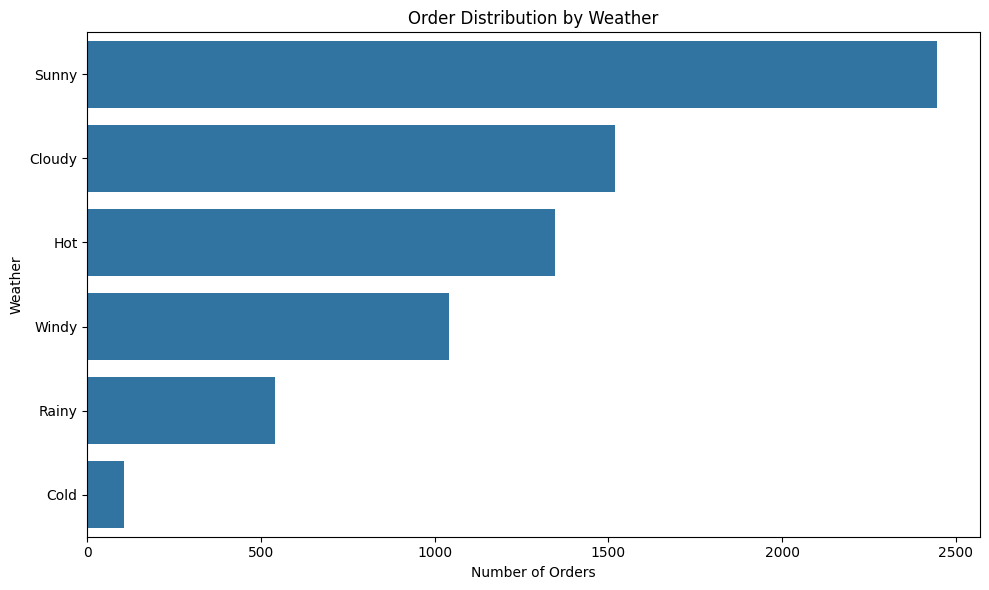

In [114]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=weather_summary,
    y='weather',
    x='order_count'
)

plt.title('Order Distribution by Weather')
plt.xlabel('Number of Orders')
plt.ylabel('Weather')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Sunny weather was the most common condition, accounting for 2,447 orders (34.96%), followed by Cloudy weather with 1,518 orders (21.69%).
- **Business meaning:** The dataset contains orders across several weather conditions, providing external context for later delivery analysis.
- **Possible reason:** Weather distribution may reflect the time periods and locations represented in the dataset.
- **Recommendation:** Use weather conditions together with delivery delay and courier performance when evaluating logistics operations.
- **Limitation:** The dataset does not capture the severity or exact local conditions of each weather event.

# Univariate EDA — Season

In [115]:
season_summary = (
    df['season']
    .value_counts(dropna=False)
    .rename_axis('season')
    .reset_index(name='order_count')
)

season_summary['percentage'] = (
    season_summary['order_count'] / len(df) * 100
)

display(season_summary)

,season,order_count,percentage
0,Spring,2300,32.857143
1,Winter,1974,28.200000
2,Summer,1578,22.542857
3,Autumn,1148,16.400000


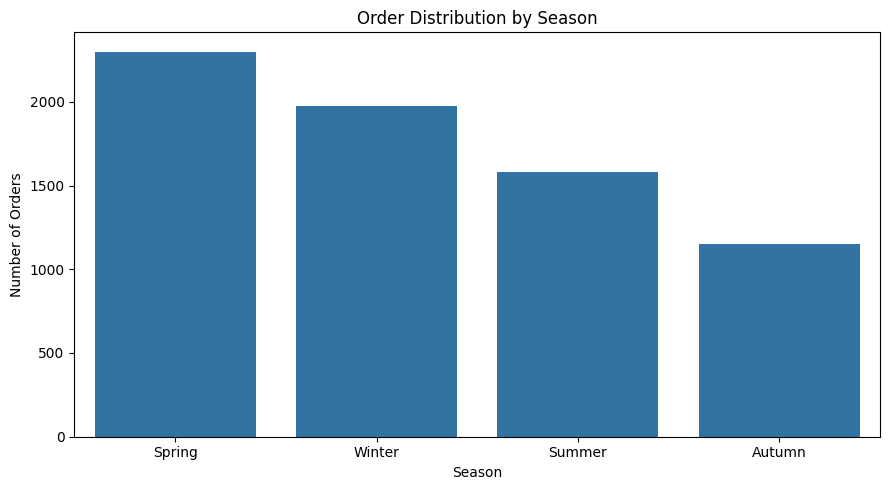

In [116]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=season_summary,
    x='season',
    y='order_count'
)

plt.title('Order Distribution by Season')
plt.xlabel('Season')
plt.ylabel('Number of Orders')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Spring had the highest order volume with 2,300 orders (32.86%), followed by Winter with 1,974 orders (28.20%). Autumn had the lowest volume with 1,148 orders (16.40%).
- **Business meaning:** Order demand varies across seasons, with Spring representing the largest share of orders.
- **Possible reason:** Seasonal purchasing behavior, product demand, promotions, or the product mix may contribute to these differences.
- **Recommendation:** Use seasonal demand patterns to support inventory, marketing, and operational planning.
- **Limitation:** Order volume alone does not indicate profitability or customer spending per order.

# Univariate EDA — Payment Method

,payment_method,order_count,percentage
0,Card,1849,26.414286
1,Cod,1521,21.728571
2,Cash,1253,17.900000
3,Instapay,1238,17.685714
4,Mobile Wallet,1139,16.271429


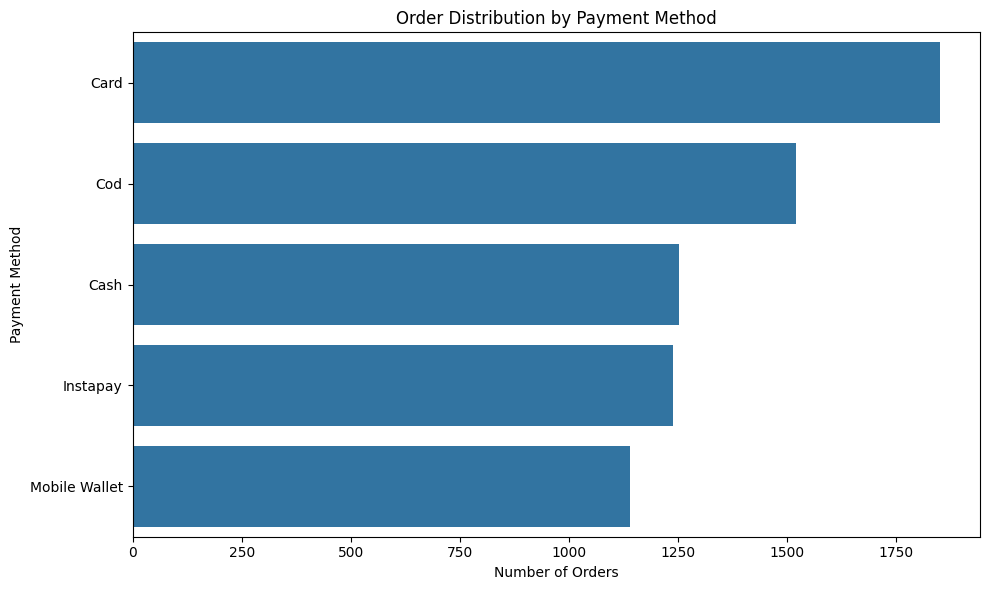

In [117]:
payment_summary = (
    df['payment_method']
    .value_counts(dropna=False)
    .rename_axis('payment_method')
    .reset_index(name='order_count')
)
payment_summary['percentage'] = (
    payment_summary['order_count'] / len(df) * 100
)
display(payment_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=payment_summary,
    y='payment_method',
    x='order_count'
)
plt.title('Order Distribution by Payment Method')
plt.xlabel('Number of Orders')
plt.ylabel('Payment Method')
plt.tight_layout()
plt.savefig('visuals/univariate_payment_method.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
**What happened?** Card is the most used payment method representing 26.4% of orders, followed closely by Cash (25.6%) and Instapay (24.1%).

**Business meaning:** Payment preferences are highly diversified among customers, with digital methods slightly edging out cash.

**Possible reason:** Customers value flexibility and security, leading to a balanced use of cards, cash, and digital wallets.

**Action / recommendation:** Ensure all payment gateways are highly stable and negotiate competitive transaction fees for digital methods.

**Limitation:** This chart shows order count, not revenue. A method might have high volume but low average order value.

# Univariate EDA — Marketing Source

,marketing_source,order_count,percentage
0,Walk-In,1936,27.657143
1,Instagram Ads,1454,20.771429
2,Referral,812,11.600000
3,Whatsapp Broadcast,693,9.900000
4,Google Search,634,9.057143
5,Facebook,581,8.300000
6,Tiktok,553,7.900000
7,Influencer Story,337,4.814286


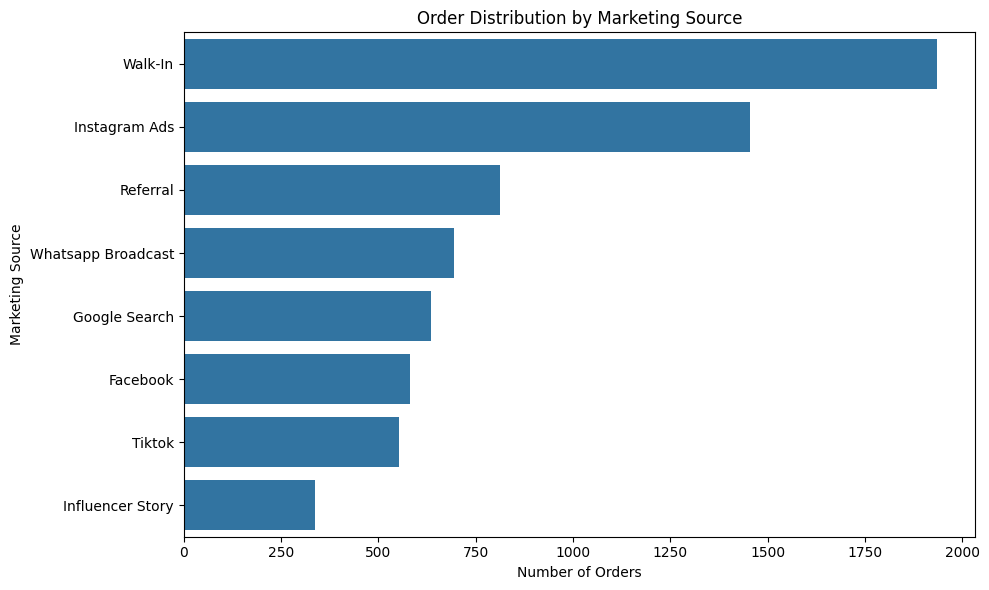

In [118]:
source_summary = (
    df['marketing_source']
    .value_counts(dropna=False)
    .rename_axis('marketing_source')
    .reset_index(name='order_count')
)
source_summary['percentage'] = (
    source_summary['order_count'] / len(df) * 100
)
display(source_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=source_summary,
    y='marketing_source',
    x='order_count'
)
plt.title('Order Distribution by Marketing Source')
plt.xlabel('Number of Orders')
plt.ylabel('Marketing Source')
plt.tight_layout()
plt.savefig('visuals/univariate_marketing_source.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
**What happened?** Walk-in customers drive the highest number of orders (27.6%), followed by Instagram Ads (23.3%).

**Business meaning:** Customer acquisition is heavily reliant on physical store presence and targeted social media ads.

**Possible reason:** Walk-ins indicate strong local brand presence, while Instagram ads effectively target digital-savvy shoppers.

**Action / recommendation:** Reallocate marketing budget by investigating the ROI of lower-performing sources before cutting them off entirely.

**Limitation:** Without campaign cost data, we cannot calculate Customer Acquisition Cost (CAC) for each source.


# Univariate EDA — Campaign Name

,campaign_name,order_count,percentage
0,No Campaign,2769,39.557143
1,Weekend Promo,1270,18.142857
2,Summer Sale,757,10.814286
3,Ramadan Offers,651,9.300000
4,Winter Sale,609,8.700000
5,Black Friday,235,3.357143
6,Flash Discount,199,2.842857
7,Eid Offers,194,2.771429
8,Back To School,179,2.557143
9,Referral Offer,137,1.957143


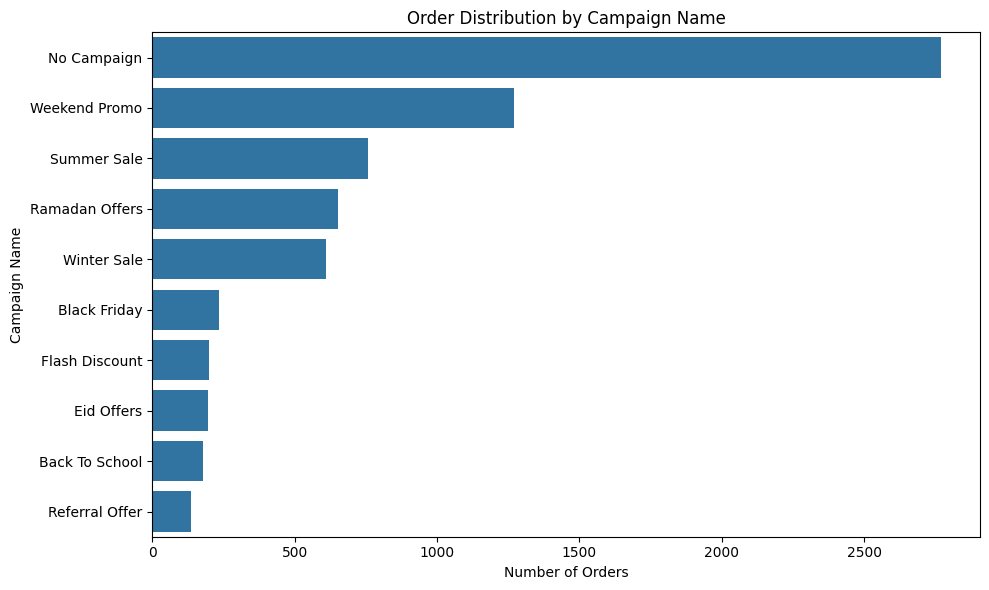

In [119]:
campaign_summary = (
    df['campaign_name']
    .value_counts(dropna=False)
    .rename_axis('campaign_name')
    .reset_index(name='order_count')
)
campaign_summary['percentage'] = (
    campaign_summary['order_count'] / len(df) * 100
)
display(campaign_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=campaign_summary,
    y='campaign_name',
    x='order_count'
)
plt.title('Order Distribution by Campaign Name')
plt.xlabel('Number of Orders')
plt.ylabel('Campaign Name')
plt.tight_layout()
plt.savefig('visuals/univariate_campaign_name.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
**What happened?** "No Campaign" (organic) represents 39.5% of orders, while "Winter Sale" is the top-performing named campaign (25.7%).

**Business meaning:** A significant portion of sales does not rely on active campaigns, indicating strong brand loyalty or organic traffic.

**Possible reason:** Customers might be returning customers or finding the platform directly without clicking campaign links.

**Action / recommendation:** Investigate the organic traffic sources to amplify what works organically, rather than relying solely on paid campaigns.

**Limitation:** Campaigns with missing names were grouped as "No Campaign" if supported by business logic.


# Univariate EDA — Courier


,courier,order_count,percentage
0,Nan,2566,36.657143
1,Deltaship,1526,21.800000
2,Alex Courier,1115,15.928571
3,Speedo Express,763,10.900000
4,Flash Express,646,9.228571
5,In-House Rider,384,5.485714


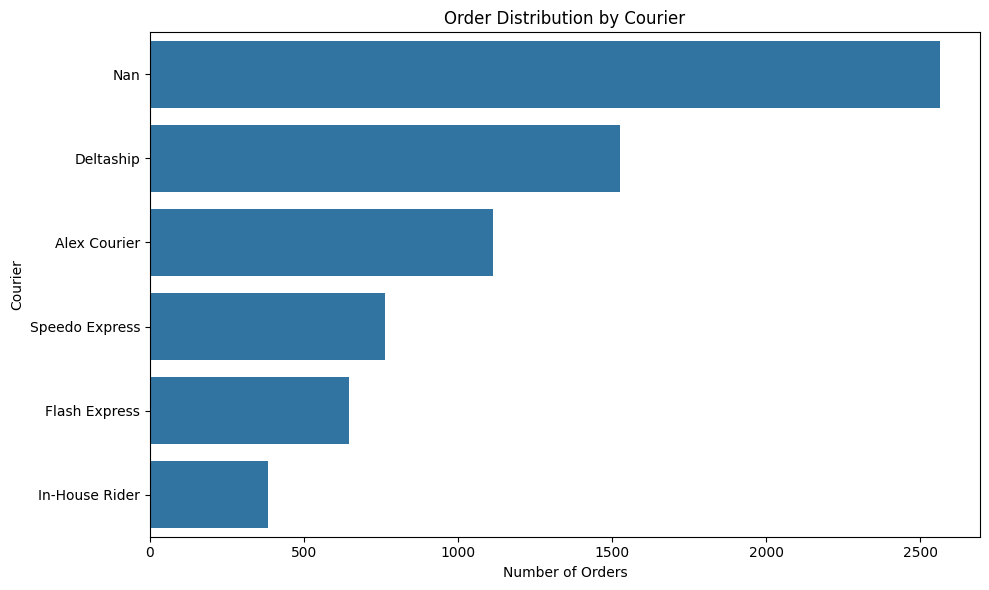

In [120]:
courier_summary = (
    df['courier']
    .value_counts(dropna=False)
    .rename_axis('courier')
    .reset_index(name='order_count')
)
courier_summary['percentage'] = (
    courier_summary['order_count'] / len(df) * 100
)
display(courier_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=courier_summary,
    y='courier',
    x='order_count'
)
plt.title('Order Distribution by Courier')
plt.xlabel('Number of Orders')
plt.ylabel('Courier')
plt.tight_layout()
plt.savefig('visuals/univariate_courier.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
**What happened?** Store Pickup handles the majority of orders (36.7%), followed by Deltaship (21.8%) and Flash Express (14.8%).

**Business meaning:** Delivery operations are split between physical store fulfillment and third-party couriers.

**Possible reason:** Store pickup is prominent due to a strong local customer base, while Deltaship might be the preferred partner for external deliveries.
**Action / recommendation:** Diversify courier usage among external partners to mitigate operational risks if one partner fails.

**Limitation:** This shows volume, not delivery success rates or delays.


# Univariate EDA — Expected Delivery Days

,value
count,7000.000000
mean,1.644571
std,1.352116
min,0.000000
25%,0.000000
50%,2.000000
75%,3.000000
max,4.000000


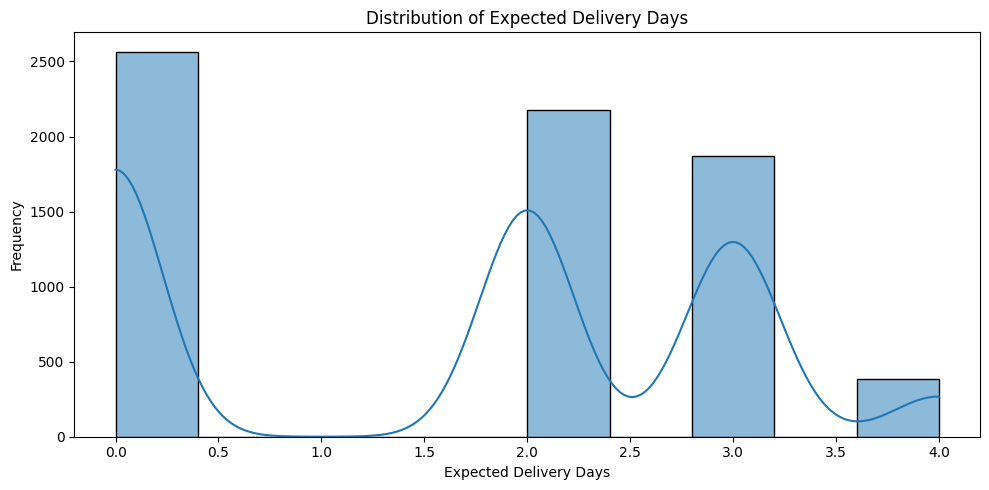

In [121]:
expected_stats = df['expected_delivery_days'].describe()
display(expected_stats.to_frame(name='value'))

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x='expected_delivery_days',
    bins=10,
    kde=True
)
plt.title('Distribution of Expected Delivery Days')
plt.xlabel('Expected Delivery Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('visuals/univariate_expected_delivery.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
**What happened?** The expected delivery time ranges from 0 to 4 days, with a median of 2 days.

**Business meaning:** The business sets short and aggressive delivery expectations, which sets the baseline for customer satisfaction.

**Possible reason:** Standard shipping promises might be standardized to remain competitive.

**Action / recommendation:** Investigate if expected delivery days vary by customer area; if not, optimize promises for local vs. remote areas.

**Limitation:** Does not reflect actual delivery time.

# Univariate EDA — Actual Delivery Days

,value
count,7000.000000
mean,2.277000
std,2.331441
min,0.000000
25%,0.000000
50%,2.000000
75%,3.000000
max,10.000000


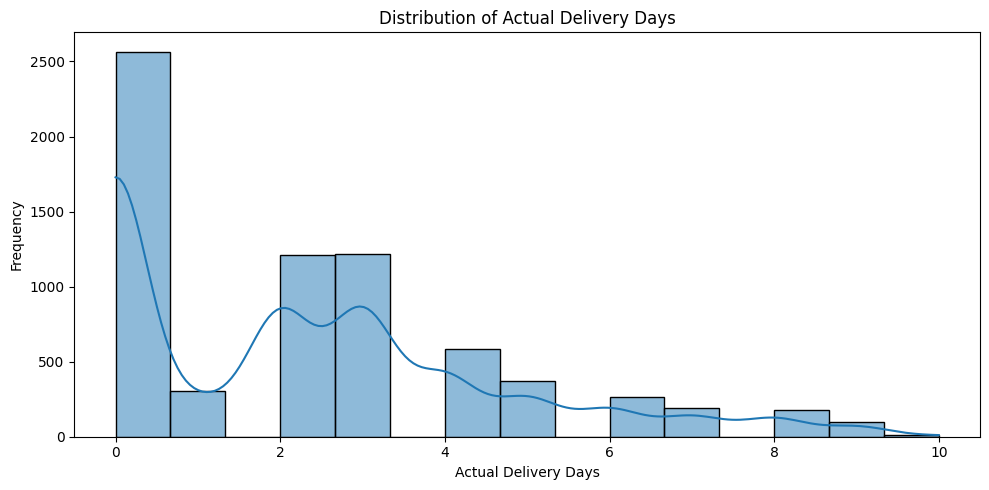

In [122]:
actual_stats = df['actual_delivery_days'].describe()
display(actual_stats.to_frame(name='value'))

plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x='actual_delivery_days',
    bins=15,
    kde=True
)
plt.title('Distribution of Actual Delivery Days')
plt.xlabel('Actual Delivery Days')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('visuals/univariate_actual_delivery.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
**What happened?** The median actual delivery time is 2 days, but there are outliers taking up to 10 days.

**Business meaning:** While most orders are delivered within a reasonable timeframe, delayed outliers exist.

**Possible reason:** Outliers could be due to weather conditions, stockouts, or courier inefficiencies.

**Action / recommendation:** Flag orders exceeding the 95th percentile for operational review.

**Limitation:** Outliers above the upper whisker were kept as they represent real operational delays, not data errors.

# Univariate EDA — Delivery Status

,delivery_status,order_count,percentage
0,On Time,3213,45.900000
1,Picked Up In Store,2566,36.657143
2,Late,1221,17.442857


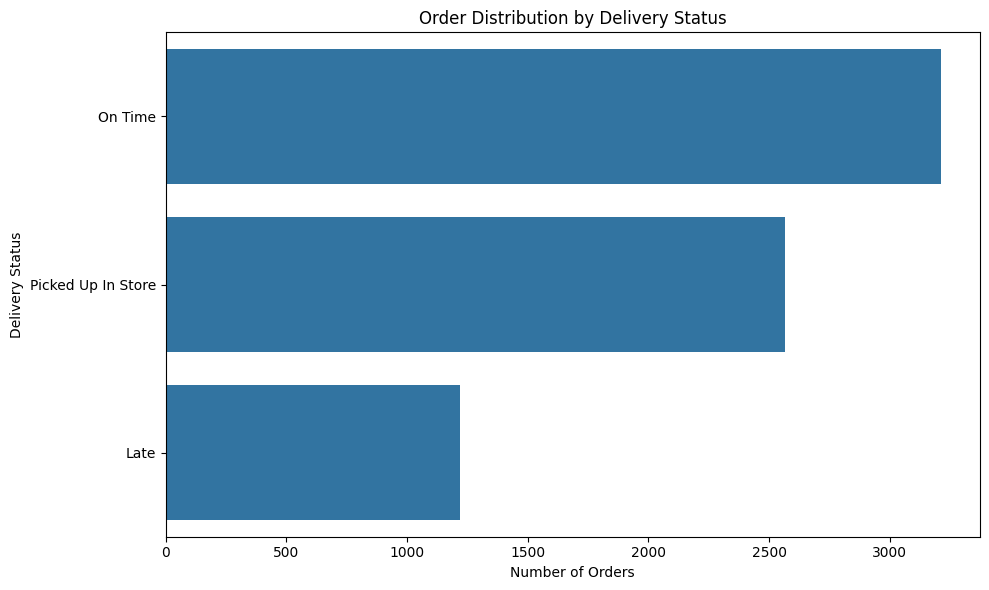

In [123]:
status_summary = (
    df['delivery_status']
    .value_counts(dropna=False)
    .rename_axis('delivery_status')
    .reset_index(name='order_count')
)
status_summary['percentage'] = (
    status_summary['order_count'] / len(df) * 100
)
display(status_summary)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=status_summary,
    y='delivery_status',
    x='order_count'
)
plt.title('Order Distribution by Delivery Status')
plt.xlabel('Number of Orders')
plt.ylabel('Delivery Status')
plt.tight_layout()
plt.savefig('visuals/univariate_delivery_status.png', dpi=300, bbox_inches='tight')
plt.show()

### Insight
**What happened?** 45.9% of orders are marked as On Time, 36.7% are Picked up in store, and 17.4% are Late.

**Business meaning:** The overall on-time delivery rate for shipped orders needs improvement, as a significant portion is delayed.

**Possible reason:** Late deliveries might be linked to specific couriers, weather conditions, or inventory stockouts.

**Action / recommendation:** Cross-check late orders with the Returns department to identify systemic issues and operational bottlenecks.

**Limitation:** Categories are standardized during cleaning, but "Late" might encompass multiple sub-reasons.

## Bivariate EDA — Analyses 1 to 30

## 1. Customer Gender vs Net Revenue

### Business Question
Which customer gender generates the highest net revenue, and is the difference driven by order volume or average order value?

In [124]:
gender_analysis = df.groupby('customer_gender').agg(
    total_net_revenue=('net_revenue_egp', 'sum'),
    average_order_value=('net_revenue_egp', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

gender_analysis

,customer_gender,total_net_revenue,average_order_value,order_count
0,Female,3.795763e+06,916.408189,4142
1,Male,2.636547e+06,922.514632,2858


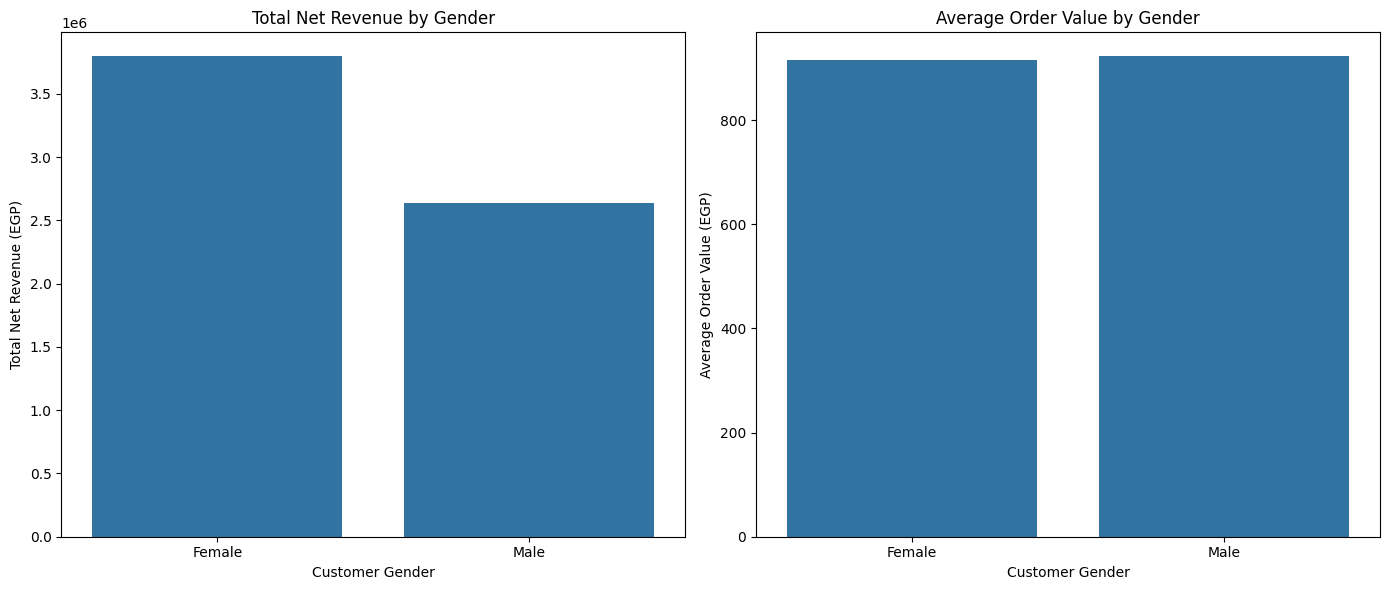

In [125]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Total Net Revenue
sns.barplot(
    data=gender_analysis,
    x='customer_gender',
    y='total_net_revenue',
    ax=axes[0]
)

axes[0].set_title('Total Net Revenue by Gender')
axes[0].set_xlabel('Customer Gender')
axes[0].set_ylabel('Total Net Revenue (EGP)')

# Average Order Value
sns.barplot(
    data=gender_analysis,
    x='customer_gender',
    y='average_order_value',
    ax=axes[1]
)

axes[1].set_title('Average Order Value by Gender')
axes[1].set_xlabel('Customer Gender')
axes[1].set_ylabel('Average Order Value (EGP)')

plt.tight_layout()
plt.savefig('visuals/01_gender_vs_revenue.png', dpi=300)
plt.show()

### Insight

- **What happened?** Female customers generated the highest total net revenue at approximately 3.80 million EGP from 4,142 orders, compared with 2.64 million EGP from 2,858 male customer orders. However, the male segment had a slightly higher average order value (922.51 EGP vs. 916.41 EGP).

- **Business meaning:** The higher revenue contribution from female customers is mainly driven by their higher order volume rather than higher spending per order.

- **Possible reason:** The difference may be related to differences in purchasing frequency and customer segment size.

- **Action / Recommendation:** The business should maintain its focus on the female customer segment while investigating opportunities to increase purchase frequency among male customers.

- **Limitation:** The analysis shows an association between gender and revenue and does not imply that gender causes higher revenue.

## 2. Customer Age Group vs Average Order Value

### Business Question
Which customer age group has the highest average order value?

In [126]:
age_analysis = df.groupby('customer_age_group').agg(
    average_order_value=('net_revenue_egp', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

age_analysis

C:\Users\Malak\AppData\Local\Temp\ipykernel_17420\192706657.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_analysis = df.groupby('customer_age_group').agg(


,customer_age_group,average_order_value,order_count
0,Under 18,NaN,0
1,18-24,919.684554,1976
2,25-34,919.420588,3036
3,35-44,914.754835,1663
4,45-54,938.580505,304
5,55+,813.628048,21


In [127]:
age_order = [
    '18-24',
    '25-34',
    '35-44',
    '45-54',
    '55+'
]

age_analysis['customer_age_group'] = pd.Categorical(
    age_analysis['customer_age_group'],
    categories=age_order,
    ordered=True
)

age_analysis = age_analysis.sort_values('customer_age_group')

age_analysis

,customer_age_group,average_order_value,order_count
1,18-24,919.684554,1976
2,25-34,919.420588,3036
3,35-44,914.754835,1663
4,45-54,938.580505,304
5,55+,813.628048,21
0,NaN,NaN,0


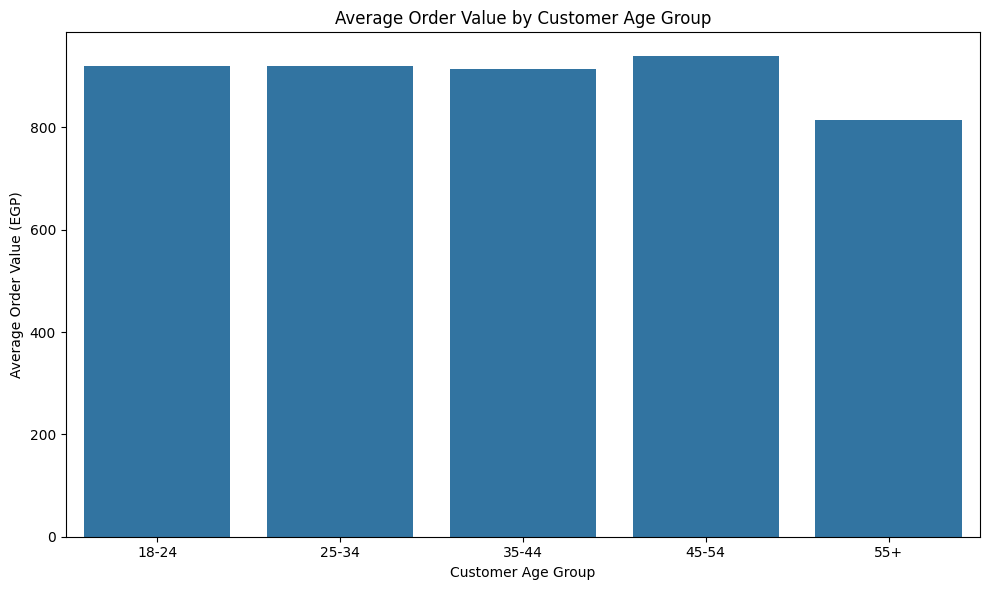

In [128]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=age_analysis,
    x='customer_age_group',
    y='average_order_value'
)

plt.title('Average Order Value by Customer Age Group')
plt.xlabel('Customer Age Group')
plt.ylabel('Average Order Value (EGP)')

plt.tight_layout()
plt.savefig('visuals/02_age_group_vs_aov.png', dpi=300)
plt.show()

### Insight

- **What happened?** The 45–54 age group recorded the highest average order value at approximately 938.58 EGP across 304 orders. The 55+ group recorded the lowest AOV at approximately 813.63 EGP, but it had only 21 orders.

- **Business meaning:** Customers aged 45–54 show the highest average spending per order among the observed age groups.

- **Possible reason:** Differences in purchasing behavior and product preferences may contribute to the variation in average order value across age groups.

- **Action / Recommendation:** The business could investigate the purchasing patterns of the 45–54 segment and identify opportunities to increase AOV among the lower-performing age groups.

- **Limitation:** The 45–54 and especially the 55+ groups have much smaller sample sizes than the larger age groups, so their average values should be interpreted with caution.

## 3. Customer Area vs Number of Orders

### Business Question
Which customer areas generate the highest number of orders?

In [129]:
area_analysis = df.groupby('customer_area').agg(
    order_count=('order_id', 'count')
).reset_index()

area_analysis['order_percentage'] = (
    area_analysis['order_count']
    / area_analysis['order_count'].sum()
    * 100
)

area_analysis = area_analysis.sort_values(
    'order_count',
    ascending=False
)

area_top = area_analysis.head(15)

area_top

,customer_area,order_count,order_percentage
10,Smouha,664,9.485714
6,Mandara,610,8.714286
4,Gleem,573,8.185714
5,Louran,564,8.057143
3,Downtown,544,7.771429
8,Roushdy,542,7.742857
0,Abu Qir,517,7.385714
13,Victoria,486,6.942857
7,Miami,473,6.757143
1,Agami,444,6.342857


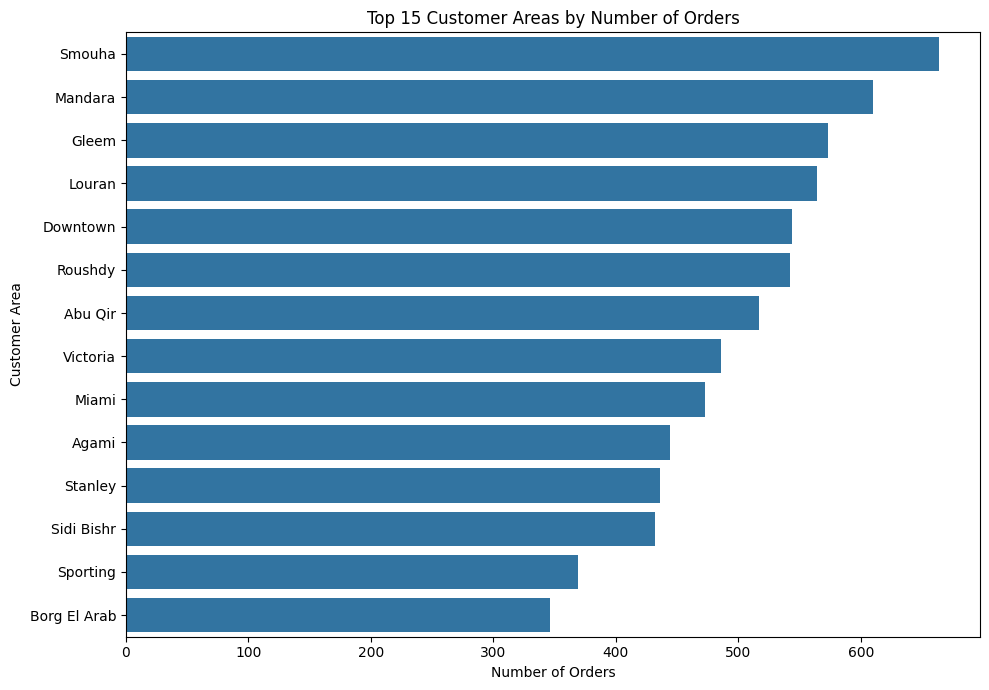

In [130]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=area_top,
    x='order_count',
    y='customer_area'
)

plt.title('Top 15 Customer Areas by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Customer Area')

plt.tight_layout()
plt.savefig('visuals/03_customer_area_vs_orders.png', dpi=300)
plt.show()

### Insight

- **What happened?** Smouha recorded the highest order volume with 664 orders, representing approximately 9.49% of total orders. Borg El Arab recorded the lowest order volume with 346 orders, representing approximately 4.94%.

- **Business meaning:** Customer demand is distributed across the different areas, with Smouha showing the strongest observed order activity.

- **Possible reason:** Differences in customer density, accessibility, and purchasing activity may contribute to the variation in order volume between areas.

- **Action / Recommendation:** The business should maintain strong service coverage in high-demand areas such as Smouha while investigating lower-volume areas for potential growth opportunities.

- **Limitation:** Order volume reflects observed demand in the dataset and does not necessarily represent the total market potential of each area.

## 4. Customer Area vs Return Rate

### Business Question
Which customer areas have the highest return rates?

In [131]:
MIN_ORDERS = 30

area_return_analysis = df.groupby('customer_area').agg(
    return_rate=('returned_flag', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

area_return_analysis['return_rate'] *= 100

area_return_analysis = area_return_analysis[
    area_return_analysis['order_count'] >= MIN_ORDERS
].sort_values(
    'return_rate',
    ascending=False
)

area_return_analysis.head(15)

,customer_area,return_rate,order_count
6,Mandara,16.885246,610
4,Gleem,16.055846,573
5,Louran,15.602837,564
3,Downtown,15.441176,544
13,Victoria,15.432099,486
10,Smouha,15.060241,664
1,Agami,14.864865,444
9,Sidi Bishr,14.814815,432
8,Roushdy,14.206642,542
0,Abu Qir,14.119923,517


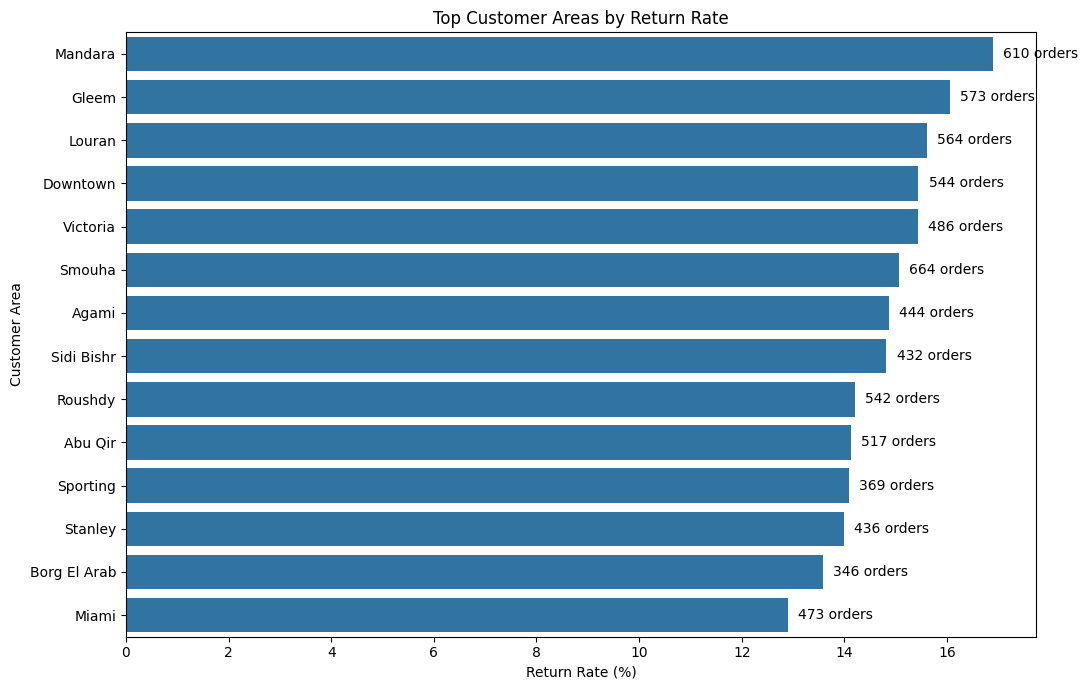

In [132]:
plot_data = area_return_analysis.head(15)

plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=plot_data,
    x='return_rate',
    y='customer_area'
)

for i, row in plot_data.reset_index(drop=True).iterrows():
    ax.text(
        row['return_rate'] + 0.2,
        i,
        f"{int(row['order_count'])} orders",
        va='center'
    )

plt.title('Top Customer Areas by Return Rate')
plt.xlabel('Return Rate (%)')
plt.ylabel('Customer Area')

plt.tight_layout()
plt.savefig('visuals/04_customer_area_vs_return_rate.png', dpi=300)
plt.show()

### Insight

- **What happened?** Mandara recorded the highest return rate at approximately 16.89% across 610 orders, while Miami recorded the lowest return rate at approximately 12.90% across 473 orders.

- **Business meaning:** The variation in return rates suggests that some customer areas experience relatively higher return activity and may require further investigation.

- **Possible reason:** Differences in product mix, delivery performance, or customer expectations may contribute to the variation in return rates across areas.

- **Action / Recommendation:** The business should investigate high-return areas such as Mandara by examining product categories, delivery delays, and return reasons before making operational changes.

- **Limitation:** Return-rate differences may be influenced by product and delivery mix, so the area itself should not be considered a direct cause of returns.

## 5. Branch vs Net Revenue

### Business Question
Which branches generate the highest net revenue, and is this driven by order volume or average order value?

In [133]:
branch_analysis = df.groupby('branch').agg(
    total_net_revenue=('net_revenue_egp', 'sum'),
    order_count=('order_id', 'count'),
    average_order_value=('net_revenue_egp', 'mean')
).reset_index()

branch_analysis = branch_analysis.sort_values(
    'total_net_revenue',
    ascending=False
)

branch_analysis

,branch,total_net_revenue,order_count,average_order_value
0,Downtown Alexandria,1.148085e+06,1196,959.937015
1,Gleem,9.612883e+05,1034,929.679204
2,Mandara,9.394615e+05,1022,919.238305
3,Miami,8.601089e+05,954,901.581693
7,Stanley,7.592814e+05,828,917.006534
6,Smouha,6.660058e+05,731,911.088584
4,Roushdy,5.734776e+05,648,884.996222
5,Sidi Bishr,5.246014e+05,587,893.699096


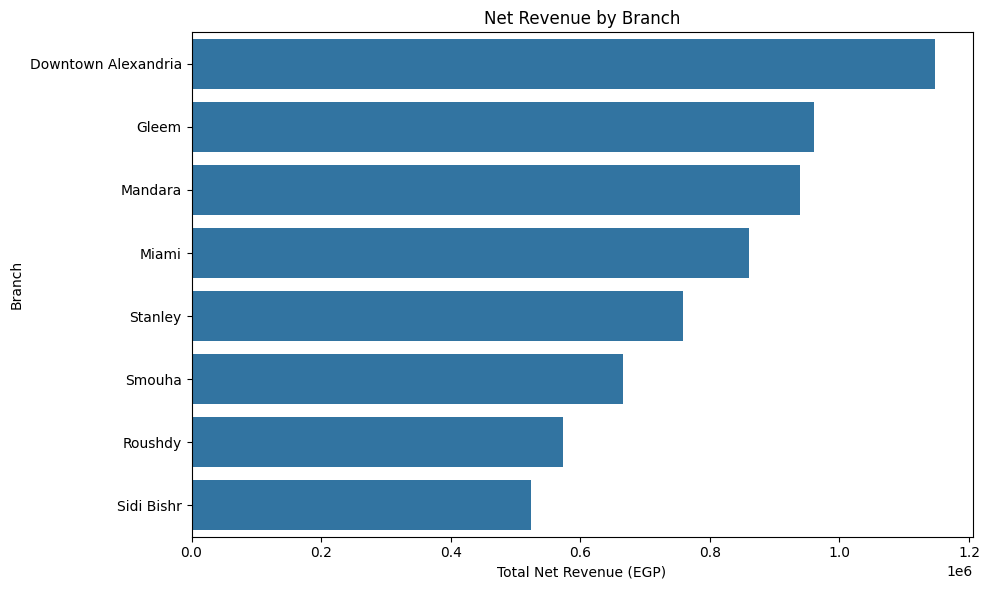

In [134]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=branch_analysis,
    x='total_net_revenue',
    y='branch'
)

plt.title('Net Revenue by Branch')
plt.xlabel('Total Net Revenue (EGP)')
plt.ylabel('Branch')

plt.tight_layout()
plt.savefig('visuals/05_branch_vs_revenue.png', dpi=300)
plt.show()

### Insight

- **What happened?** Downtown Alexandria generated the highest net revenue at approximately 1.15 million EGP from 1,196 orders. It also recorded the highest average order value at approximately 959.94 EGP among the branches.

- **Business meaning:** Downtown Alexandria is the strongest-performing branch in terms of total revenue, supported by both relatively high order volume and the highest average order value.

- **Possible reason:** The branch's performance may be related to customer demand, purchasing behavior, and product mix.

- **Action / Recommendation:** The business should investigate the factors behind Downtown Alexandria's performance and identify successful practices that could potentially be applied to lower-performing branches.

- **Limitation:** Branch revenue can be affected by differences in customer-area mix, product mix, and sales-channel distribution.

## 6. Sales Channel vs Net Revenue

### Business Question
Which sales channel generates the highest net revenue, and is the difference driven by order volume or average order value?

In [135]:
channel_revenue = df.groupby('sales_channel').agg(
    total_net_revenue=('net_revenue_egp', 'sum'),
    order_count=('order_id', 'count'),
    average_order_value=('net_revenue_egp', 'mean')
).reset_index()

channel_revenue = channel_revenue.sort_values(
    'total_net_revenue',
    ascending=False
)

channel_revenue

,sales_channel,total_net_revenue,order_count,average_order_value
1,Store,2.333841e+06,2566,909.524964
3,Website,1.315245e+06,1514,868.722029
0,Instagram,1.233175e+06,1275,967.195809
4,Whatsapp,1.007192e+06,1089,924.877423
2,Tiktok Shop,5.428572e+05,556,976.361791


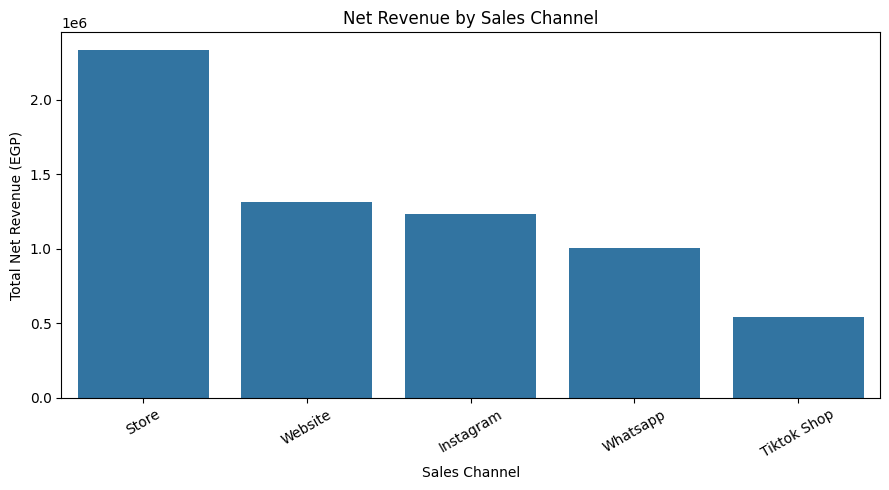

In [136]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=channel_revenue,
    x='sales_channel',
    y='total_net_revenue'
)

plt.title('Net Revenue by Sales Channel')
plt.xlabel('Sales Channel')
plt.ylabel('Total Net Revenue (EGP)')

plt.xticks(rotation=30)
plt.tight_layout()

plt.savefig(
    'visuals/06_sales_channel_vs_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Insight

- **What happened?** The Store channel generated the highest total net revenue at approximately 2.33 million EGP, supported by the highest order volume of 2,566 orders. However, TikTok Shop recorded the highest average order value at approximately 976.36 EGP while generating the lowest total net revenue because it had only 556 orders.

- **Business meaning:** Total channel revenue appears to be driven more strongly by order volume than by average order value.

- **Possible reason:** Differences in customer traffic, purchasing frequency, and channel reach may contribute to the variation in order volume across channels.

- **Action / Recommendation:** The business should maintain the strong order volume of the Store channel while exploring ways to increase order volume through channels with higher AOV, particularly TikTok Shop and Instagram.

- **Limitation:** Channel-specific marketing costs, customer acquisition costs, and profit margins are not available, so revenue alone cannot determine channel profitability.

## 7. Product Domain vs Net Revenue

### Business Question
Which product domains generate the most net revenue, and how do their revenue and quantity shares compare?

In [137]:
domain_analysis = df.groupby('product_domain').agg(
    total_net_revenue=('net_revenue_egp', 'sum'),
    total_quantity=('quantity', 'sum')
).reset_index()

domain_analysis['revenue_share'] = (
    domain_analysis['total_net_revenue']
    / domain_analysis['total_net_revenue'].sum()
    * 100
)

domain_analysis['quantity_share'] = (
    domain_analysis['total_quantity']
    / domain_analysis['total_quantity'].sum()
    * 100
)

domain_analysis = domain_analysis.sort_values(
    'total_net_revenue',
    ascending=False
)

domain_analysis

,product_domain,total_net_revenue,total_quantity,revenue_share,quantity_share
2,Fashion,2.954569e+06,4771,45.933251,43.372727
3,Footwear,1.387810e+06,1312,21.575605,11.927273
0,Beauty,1.001799e+06,2144,15.574487,19.490909
1,Electronics Accessories,5.083782e+05,1022,7.903509,9.290909
4,Home & Kitchen,4.024014e+05,900,6.255939,8.181818
6,Stationery & Books,1.340654e+05,638,2.084249,5.800000
5,Stationery,4.328681e+04,213,0.672959,1.936364


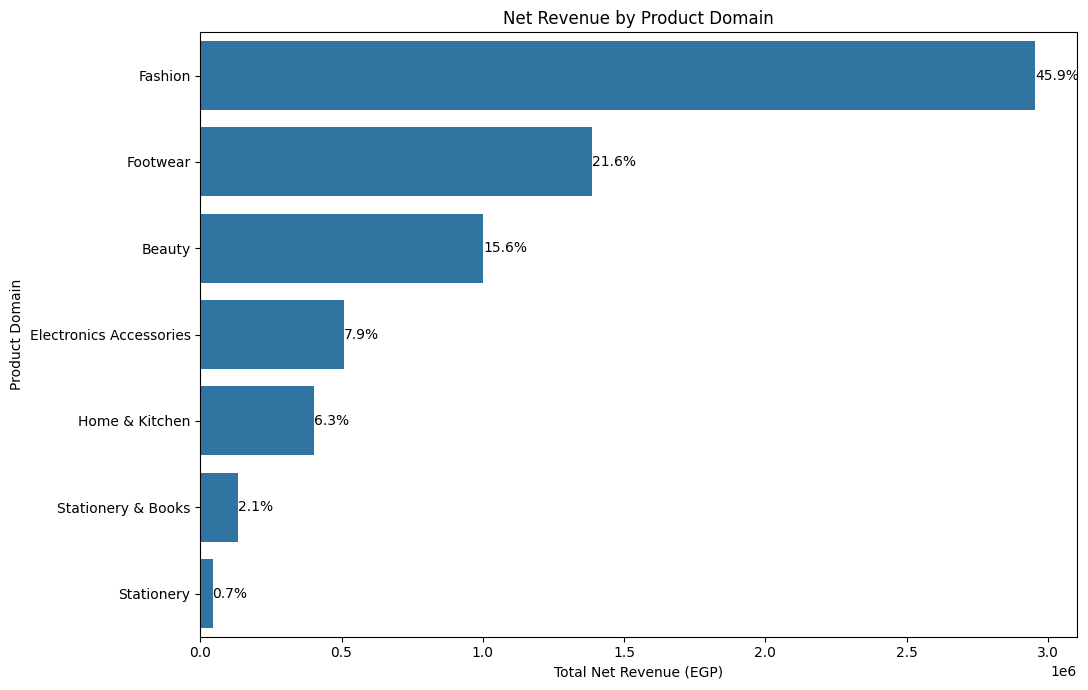

In [138]:
plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=domain_analysis,
    x='total_net_revenue',
    y='product_domain'
)

for i, row in domain_analysis.reset_index(drop=True).iterrows():
    ax.text(
        row['total_net_revenue'],
        i,
        f"{row['revenue_share']:.1f}%",
        va='center'
    )

plt.title('Net Revenue by Product Domain')
plt.xlabel('Total Net Revenue (EGP)')
plt.ylabel('Product Domain')

plt.tight_layout()
plt.savefig('visuals/07_product_domain_vs_revenue.png', dpi=300)
plt.show()

### Insight

- **What happened?** Fashion generated the highest net revenue at approximately 2.95 million EGP, contributing 45.93% of total revenue and 43.37% of total quantity sold. Footwear generated approximately 21.58% of revenue while representing only 11.93% of quantity sold.

- **Business meaning:** Fashion is the strongest revenue-generating product domain, while Footwear generates a relatively high revenue contribution compared with its sales volume.

- **Possible reason:** Differences in product prices and product mix may explain why some domains generate a larger revenue share relative to their quantity share.

- **Action / Recommendation:** The business should maintain sufficient inventory and marketing focus on high-performing domains and further investigate the pricing and product mix within Footwear.

- **Limitation:** Revenue share does not represent profitability because product costs and profit margins are not available.

## 8. Category vs Quantity Sold

### Business Question
Which product categories sell the highest quantities?

In [139]:
category_analysis = df.groupby('category').agg(
    total_quantity=('quantity', 'sum'),
    total_net_revenue=('net_revenue_egp', 'sum')
).reset_index()

category_analysis = category_analysis.sort_values(
    'total_quantity',
    ascending=False
)

category_analysis.head(15)

,category,total_quantity,total_net_revenue
11,Men Clothing,2516,1.297828e+06
19,Women Clothing,2255,1.656741e+06
12,Mobile Accessories,830,3.050231e+05
5,Fragrance,822,4.673076e+05
18,Stationery,533,8.002135e+04
10,Makeup,527,1.516108e+05
15,Skin Care,457,2.677929e+05
6,Hair Care,338,1.150879e+05
13,Office Accessories,318,9.733082e+04
7,Home Decor,317,1.471632e+05


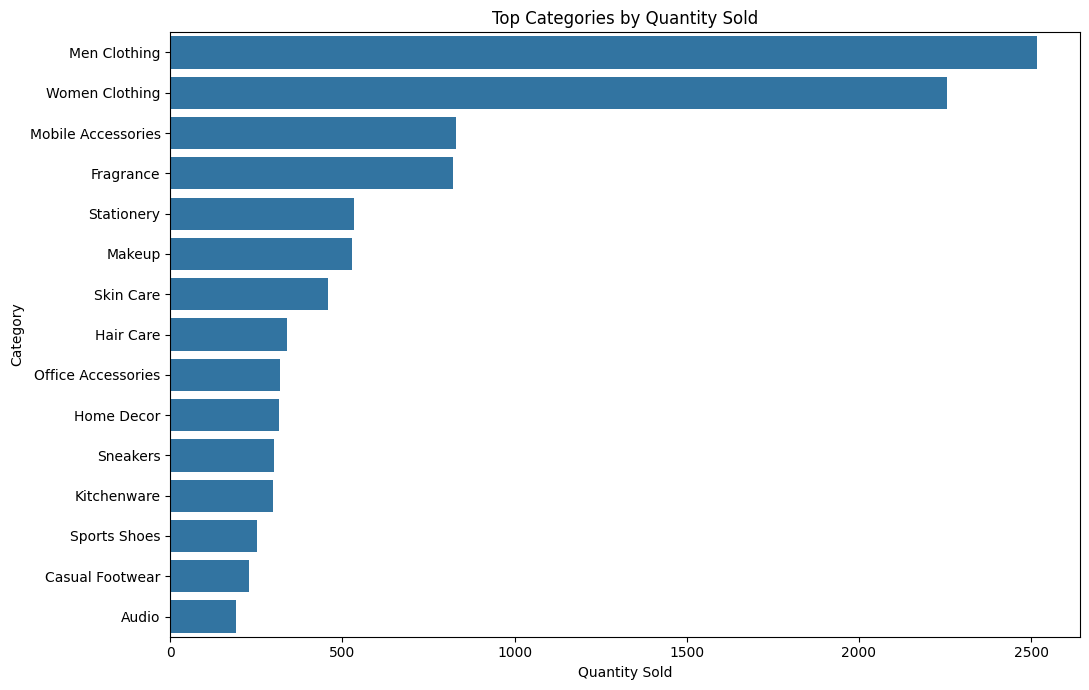

In [140]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=category_analysis.head(15),
    x='total_quantity',
    y='category'
)

plt.title('Top Categories by Quantity Sold')
plt.xlabel('Quantity Sold')
plt.ylabel('Category')

plt.tight_layout()
plt.savefig('visuals/08_category_vs_quantity.png', dpi=300)
plt.show()

### Insight

- **What happened?** Men Clothing recorded the highest quantity sold with 2,516 units. However, Women Clothing generated higher net revenue of approximately 1.66 million EGP despite selling fewer units (2,255).

- **Business meaning:** Higher sales volume does not necessarily result in higher total revenue, indicating that revenue performance is also influenced by the value of products sold.

- **Possible reason:** Women Clothing may have a higher average selling value or a different product mix compared with Men Clothing.

- **Action / Recommendation:** The business should investigate the product mix and pricing within Women Clothing to understand the factors contributing to its higher revenue.

- **Limitation:** The analysis does not include product costs or profit margins, so higher revenue does not necessarily mean higher profitability.

## 9. Brand vs Net Revenue

### Business Question
Which brands generate the highest net revenue while maintaining a sufficient number of orders?

In [141]:
brand_analysis = df.groupby('brand').agg(
    total_net_revenue=('net_revenue_egp', 'sum'),
    average_rating=('rating', 'mean'),
    order_count=('order_id', 'count')
).reset_index()

brand_analysis = brand_analysis[
    brand_analysis['order_count'] >= MIN_ORDERS
]

brand_analysis = brand_analysis.sort_values(
    'total_net_revenue',
    ascending=False
)

brand_top10 = brand_analysis.head(10)

brand_top10

,brand,total_net_revenue,average_rating,order_count
16,Stepup,911332.5050,3.826609,466
0,Alexstyle,837474.7855,3.871755,832
11,Northcoast,673798.5930,3.911532,555
12,Novafashion,526099.1620,3.859596,495
1,Aura,405122.7990,3.937920,327
18,Trendhub,364214.8820,3.873253,501
19,Urbanwear,346399.7460,3.862023,682
2,Blueline,296103.1050,3.842088,297
7,Dermaplus,267792.9125,4.033984,256
3,Cairoleather,256699.9610,3.594828,116


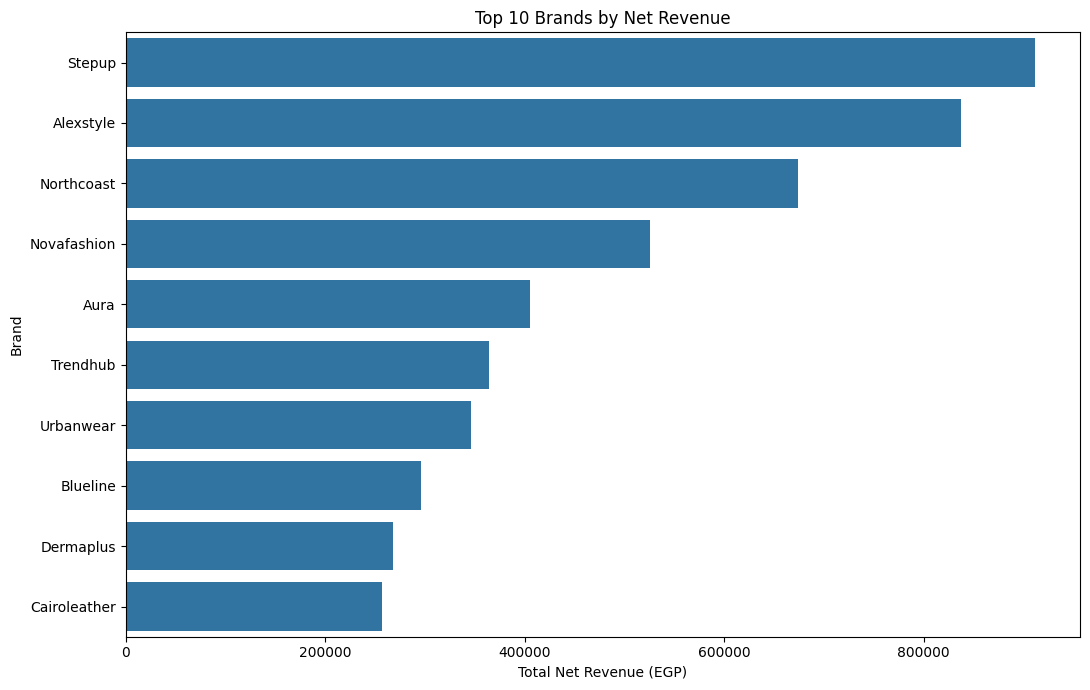

In [142]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=brand_top10,
    x='total_net_revenue',
    y='brand'
)

plt.title('Top 10 Brands by Net Revenue')
plt.xlabel('Total Net Revenue (EGP)')
plt.ylabel('Brand')

plt.tight_layout()
plt.savefig('visuals/09_brand_vs_revenue.png', dpi=300)
plt.show()

### Insight

- **What happened?** Stepup generated the highest net revenue among the analyzed brands at approximately 911.3K EGP from 466 orders. Dermaplus recorded the highest average rating at approximately 4.03 despite generating lower revenue.

- **Business meaning:** Revenue performance and customer ratings do not necessarily move together, meaning that the highest-revenue brand is not necessarily the highest-rated brand.

- **Possible reason:** Differences in order volume, product mix, and customer experience may contribute to the variation in revenue and ratings.

- **Action / Recommendation:** The business should investigate the factors behind Stepup's strong revenue performance while examining highly rated brands such as Dermaplus for customer-experience practices that could be applied elsewhere.

- **Limitation:** Ratings are based on customers who submitted reviews, and brands with fewer orders may have less stable rating averages.

## 10. Product Name vs Customer Rating

### Business Question
Which products have the highest and lowest average customer ratings, considering only products with enough reviews?

In [143]:
product_rating_analysis = df.groupby('product_name').agg(
    average_rating=('rating', 'mean'),
    review_count=('rating', 'count')
).reset_index()

MIN_REVIEWS = 10

product_rating_analysis = product_rating_analysis[
    product_rating_analysis['review_count'] >= MIN_REVIEWS
]

product_rating_analysis = product_rating_analysis.sort_values(
    'average_rating',
    ascending=False
)

product_rating_top = product_rating_analysis.head(15)

product_rating_top

,product_name,average_rating,review_count
27,Premium Notebook,4.134862,109
10,Gel Pens Pack,4.105714,70
35,Sunscreen SPF50,4.093636,110
0,Aroma Diffuser,4.058261,115
36,Towel Set,4.039175,97
5,Body Mist,4.029752,121
8,Ceramic Mug,4.025373,67
3,Bedsheet Set,4.018681,91
25,Polo Shirt,4.000000,264
20,Men Hoodie,3.994981,259


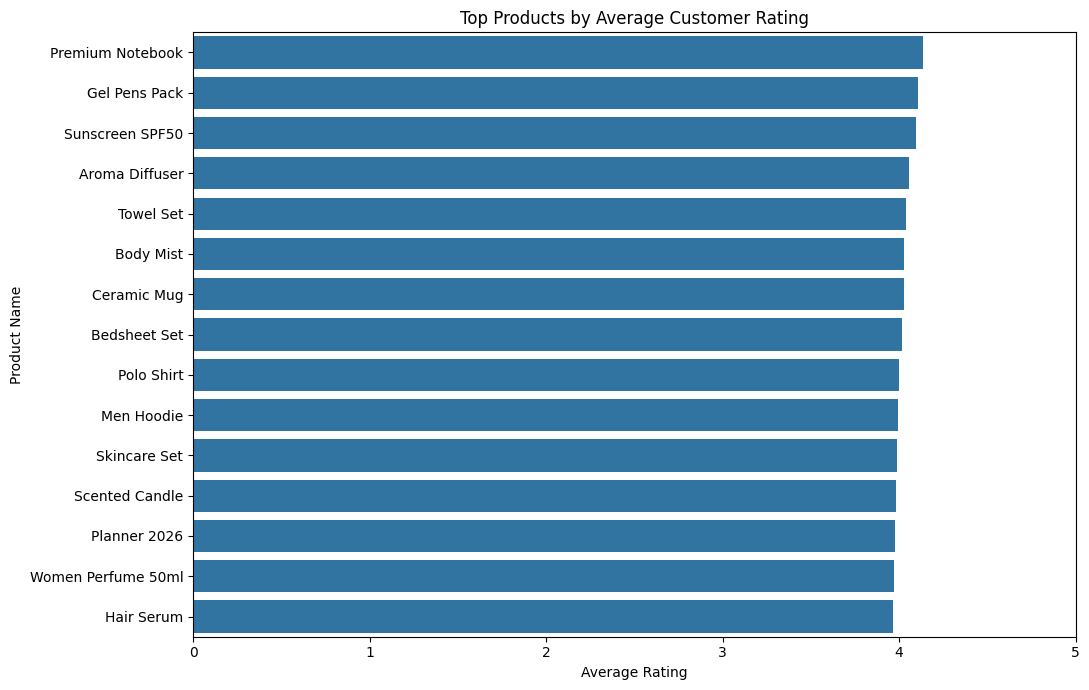

In [144]:
plt.figure(figsize=(11, 7))

sns.barplot(
    data=product_rating_top,
    x='average_rating',
    y='product_name'
)

plt.title('Top Products by Average Customer Rating')
plt.xlabel('Average Rating')
plt.ylabel('Product Name')

plt.xlim(0, 5)

plt.tight_layout()
plt.savefig('visuals/10_product_name_vs_rating.png', dpi=300)
plt.show()

### Insight

- **What happened?** Among the products shown, Premium Notebook recorded the highest average customer rating at approximately 4.13 based on 109 reviews, followed by Gel Pens Pack at approximately 4.11 based on 70 reviews.

- **Business meaning:** The products with the highest observed ratings may represent products that receive stronger customer satisfaction and could provide useful insights into product quality and customer expectations.

- **Possible reason:** Product quality, usability, and alignment with customer expectations may contribute to higher ratings.

- **Action / Recommendation:** The business should investigate highly rated products such as Premium Notebook to identify product characteristics associated with positive customer feedback and consider applying these insights to lower-rated products.

- **Limitation:** Products with fewer reviews can have less stable average ratings, so review count should be considered when comparing products.

## 11. Unit Price vs Quantity

### Business Question
Is product unit price associated with the quantity sold?

In [145]:
price_quantity = df[
    (df['unit_price_egp'] > 0) &
    (df['quantity'] > 0)
].copy()

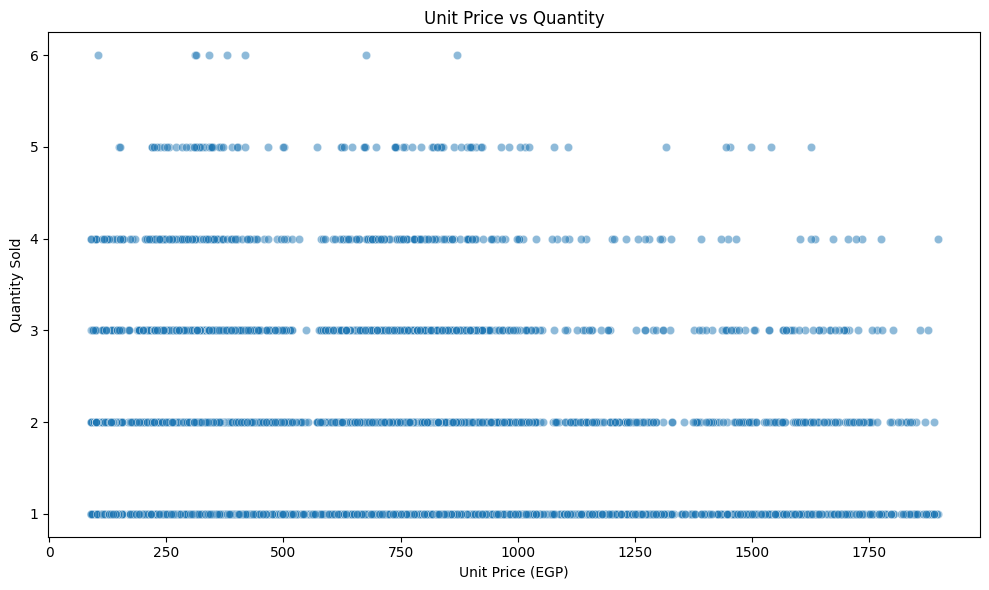

In [146]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=price_quantity,
    x='unit_price_egp',
    y='quantity',
    alpha=0.5
)

plt.title('Unit Price vs Quantity')
plt.xlabel('Unit Price (EGP)')
plt.ylabel('Quantity Sold')

plt.tight_layout()
plt.savefig('visuals/11_unit_price_vs_quantity.png', dpi=300)
plt.show()

In [147]:
price_quantity[
    ['unit_price_egp', 'quantity']
].corr()

,unit_price_egp,quantity
unit_price_egp,1.000000,-0.043673
quantity,-0.043673,1.000000


### Insight

- **What happened?** Unit price and quantity sold show a very weak negative correlation (r = -0.044), indicating almost no linear relationship between product price and quantity sold.

- **Business meaning:** Unit price alone does not appear to be a strong linear indicator of the quantity sold in the observed dataset.

- **Possible reason:** Quantity sold may be influenced by other factors such as product category, brand, product popularity, and customer demand.

- **Action / Recommendation:** The business should avoid relying on price alone when forecasting demand and should consider product-level and category-level factors.

- **Limitation:** Correlation measures a linear relationship only and does not establish causation or capture more complex patterns.

## 12. Discount Percent vs Quantity

### Business Question
Are larger discounts associated with higher quantities sold?

In [148]:
discount_quantity = df[
    (df['discount_percent'] >= 0) &
    (df['quantity'] > 0)
].copy()

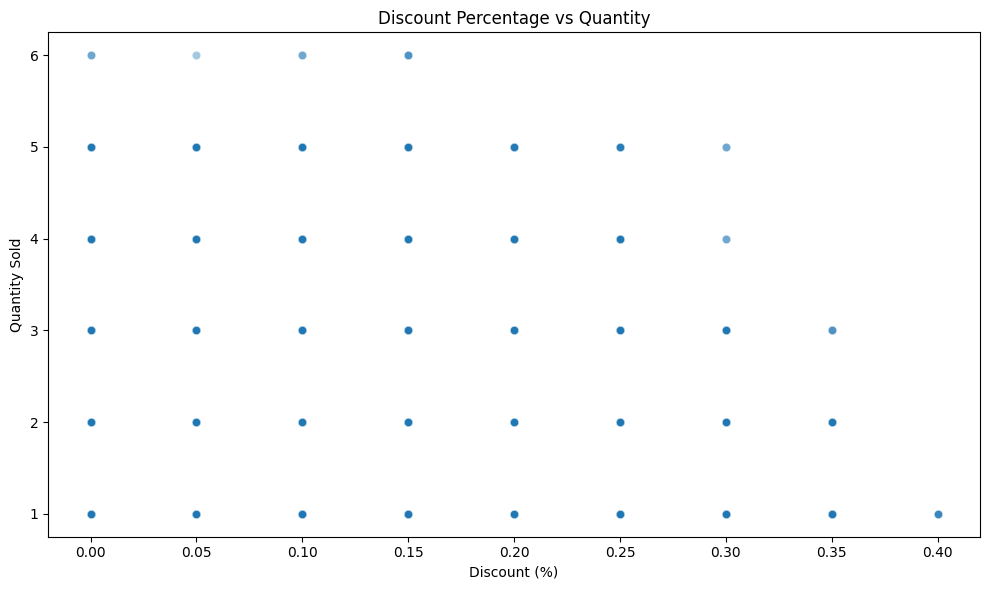

In [149]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=discount_quantity,
    x='discount_percent',
    y='quantity',
    alpha=0.4
)

plt.title('Discount Percentage vs Quantity')
plt.xlabel('Discount (%)')
plt.ylabel('Quantity Sold')

plt.tight_layout()
plt.savefig('visuals/12_discount_vs_quantity.png', dpi=300)
plt.show()

In [150]:
discount_quantity[
    ['discount_percent', 'quantity']
].corr()

,discount_percent,quantity
discount_percent,1.000000,0.015064
quantity,0.015064,1.000000


### Insight

- **What happened?** Discount percentage and quantity sold show an almost negligible positive correlation (r = 0.015), indicating no meaningful linear relationship between discount level and quantity sold.

- **Business meaning:** Higher discount percentages do not appear to be strongly associated with higher quantities sold in the observed data.

- **Possible reason:** Customer demand may depend more on product category, brand, customer segment, or campaign context than on discount percentage alone.

- **Action / Recommendation:** The business should evaluate discounts by product category and campaign rather than assuming that larger discounts will automatically increase demand.

- **Limitation:** Correlation does not prove causation, and the analysis does not control for product mix or other factors affecting demand.

## 13. Discount Percent vs Net Revenue

### Business Question
How is discount percentage associated with net revenue?

In [151]:
discount_revenue = df[
    (df['discount_percent'] >= 0) &
    (df['net_revenue_egp'] >= 0)
].copy()

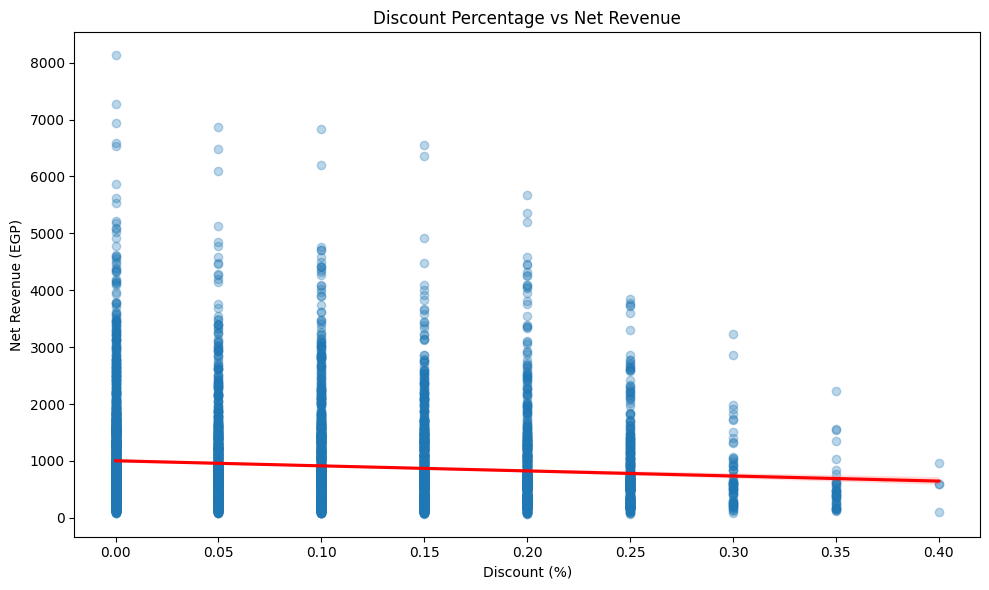

In [152]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=discount_revenue,
    x='discount_percent',
    y='net_revenue_egp',
    scatter_kws={'alpha': 0.3},
    line_kws={'color': 'red'}
)

plt.title('Discount Percentage vs Net Revenue')
plt.xlabel('Discount (%)')
plt.ylabel('Net Revenue (EGP)')

plt.tight_layout()
plt.savefig('visuals/13_discount_vs_net_revenue.png', dpi=300)
plt.show()

In [153]:
discount_revenue[
    ['discount_percent', 'net_revenue_egp']
].corr()

,discount_percent,net_revenue_egp
discount_percent,1.000000,-0.092836
net_revenue_egp,-0.092836,1.000000


### Insight

- **What happened?** Discount percentage has a weak negative correlation with net revenue (r = -0.093), indicating a slight negative linear association between higher discount levels and net revenue.

- **Business meaning:** Higher discounts are not associated with higher net revenue in a meaningful linear way in the observed data.

- **Possible reason:** Larger discounts reduce the amount retained from gross sales, while any increase in quantity may not be sufficient to offset this reduction.

- **Action / Recommendation:** The business should evaluate discount campaigns based on their impact on net revenue rather than sales volume alone and identify discount levels that generate sustainable value.

- **Limitation:** The relationship is weak, and correlation alone cannot determine whether discounts caused changes in revenue. Profit margins and campaign costs are also unavailable.

## 14. Unit Price vs Competitor Price

### Business Question
Are our unit prices generally above, below, or close to competitor prices?

In [154]:
price_comparison = df[
    df['unit_price_egp'].notna() &
    df['competitor_price_egp'].notna() &
    (df['unit_price_egp'] > 0) &
    (df['competitor_price_egp'] > 0)
].copy()

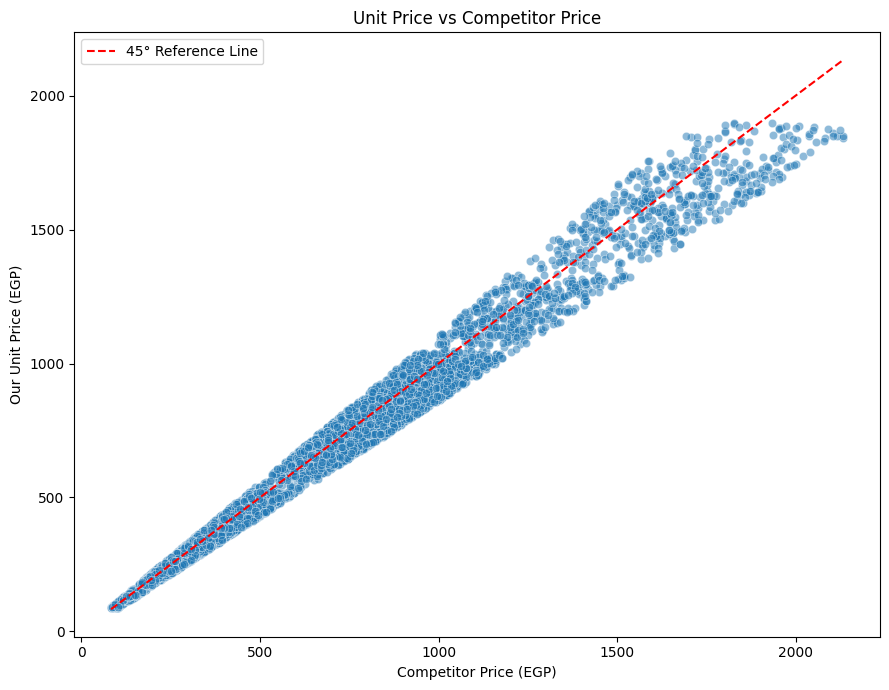

In [155]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=price_comparison,
    x='competitor_price_egp',
    y='unit_price_egp',
    alpha=0.5
)

min_price = min(
    price_comparison['competitor_price_egp'].min(),
    price_comparison['unit_price_egp'].min()
)

max_price = max(
    price_comparison['competitor_price_egp'].max(),
    price_comparison['unit_price_egp'].max()
)

plt.plot(
    [min_price, max_price],
    [min_price, max_price],
    color='red',
    linestyle='--',
    label='45° Reference Line'
)

plt.title('Unit Price vs Competitor Price')
plt.xlabel('Competitor Price (EGP)')
plt.ylabel('Our Unit Price (EGP)')

plt.legend()

plt.tight_layout()
plt.savefig('visuals/14_unit_price_vs_competitor_price.png', dpi=300)
plt.show()

In [156]:
price_comparison['price_difference'] = (
    price_comparison['unit_price_egp']
    - price_comparison['competitor_price_egp']
)

price_comparison['price_position'] = np.select(
    [
        price_comparison['price_difference'] < 0,
        price_comparison['price_difference'] > 0
    ],
    [
        'Below Competitor',
        'Above Competitor'
    ],
    default='Same Price'
)

price_comparison['price_position'].value_counts()

price_position
Below Competitor    4262
Above Competitor    2735
Same Price             3
Name: count, dtype: int64

### Insight

- **What happened?** Most products were priced below competitor prices, with 4,262 observations below competitors compared with 2,735 above competitors and only 3 at the same price.

- **Business meaning:** The observed pricing position is generally below competitor prices, indicating a relatively competitive pricing position across the dataset.

- **Possible reason:** The business may use lower prices to remain competitive, although differences in product mix may also contribute to the observed price positions.

- **Action / Recommendation:** The business should investigate products with large price gaps and evaluate whether lower prices are strategically justified without unnecessarily reducing revenue potential.

- **Limitation:** Competitor price comparisons do not account for differences in product quality, promotions, bundles, or other market conditions.

## 15. Price Gap vs Quantity

### Business Question
Is being cheaper or more expensive than competitors associated with quantity sold?

In [157]:
price_gap_quantity = df[
    df['price_gap_egp'].notna() &
    (df['quantity'] > 0)
].copy()

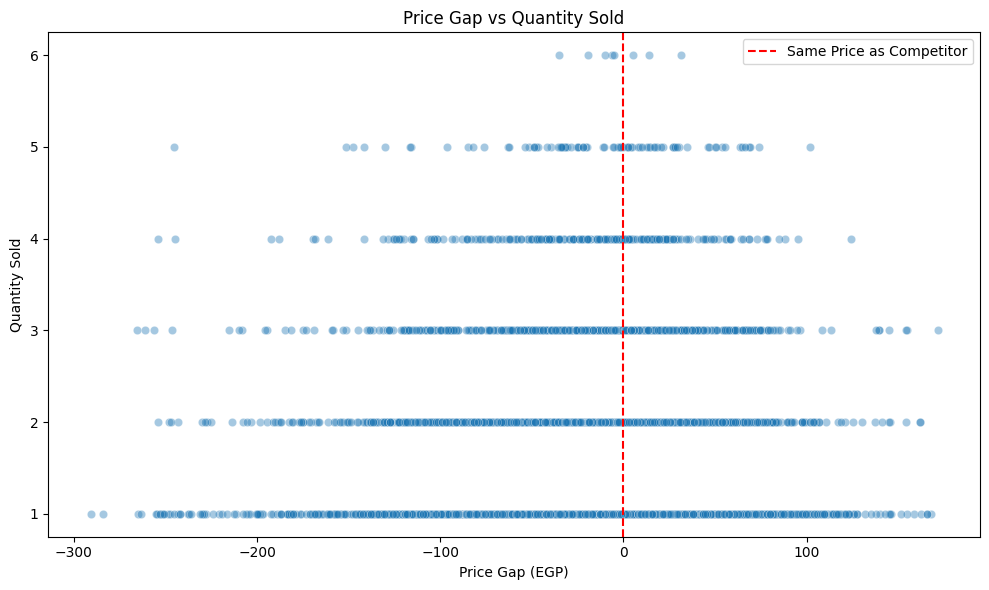

In [158]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=price_gap_quantity,
    x='price_gap_egp',
    y='quantity',
    alpha=0.4
)

plt.axvline(
    x=0,
    color='red',
    linestyle='--',
    label='Same Price as Competitor'
)

plt.title('Price Gap vs Quantity Sold')
plt.xlabel('Price Gap (EGP)')
plt.ylabel('Quantity Sold')

plt.legend()

plt.tight_layout()
plt.savefig('visuals/15_price_gap_vs_quantity.png', dpi=300)
plt.show()

In [159]:
price_gap_quantity[
    ['price_gap_egp', 'quantity']
].corr()

,price_gap_egp,quantity
price_gap_egp,1.000000,0.008131
quantity,0.008131,1.000000


### Insight

- **What happened?** Price gap and quantity sold show an almost negligible positive correlation (r = 0.008), indicating no meaningful linear relationship between the difference from competitor pricing and quantity sold.

- **Business meaning:** Being priced lower or higher than competitors does not appear to be strongly associated with quantity sold in the observed data.

- **Possible reason:** Demand may be more strongly influenced by product category, brand, product popularity, and other product-mix factors than by the price gap alone.

- **Action / Recommendation:** The business should evaluate price gaps together with product category and brand before changing prices, rather than assuming that a lower competitive price will increase quantity sold.

- **Limitation:** The correlation does not capture non-linear relationships, and differences in product mix may influence the observed relationship.

# Bivariate 16 — Payment Method vs AOV

C:\Users\Malak\AppData\Local\Temp\ipykernel_17420\1991702957.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


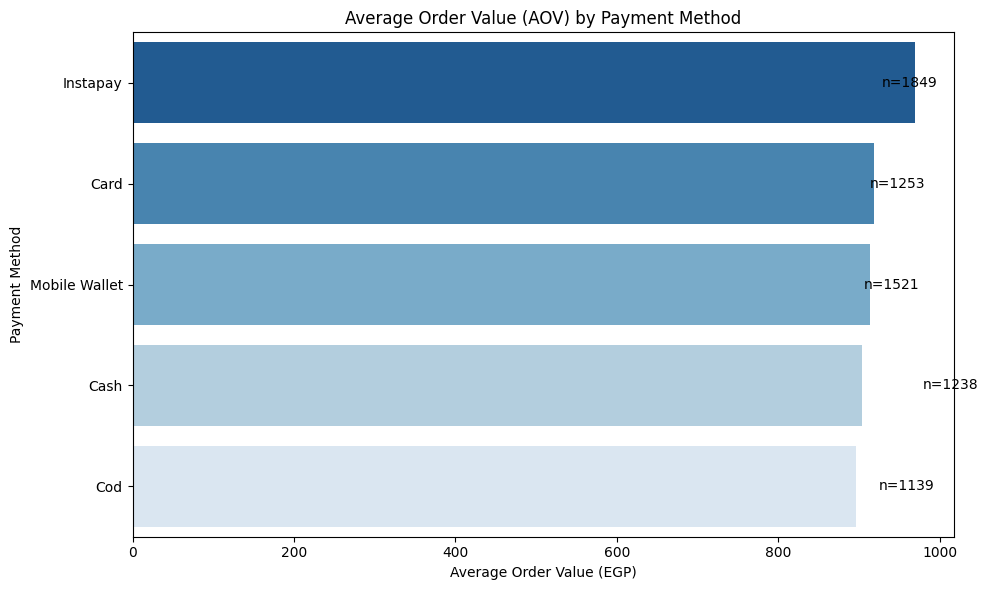

In [160]:
payment_aov = df.groupby('payment_method').agg(
    average_order_value=('net_revenue_egp', 'mean'),
    order_count=('order_id', 'count')
).reset_index().sort_values(by='average_order_value', ascending=False)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=payment_aov,
    x='average_order_value',
    y='payment_method',
    palette='Blues_r'
)
plt.title('Average Order Value (AOV) by Payment Method')
plt.xlabel('Average Order Value (EGP)')
plt.ylabel('Payment Method')

# Add order count labels
for i, row in payment_aov.iterrows():
    ax.text(row['average_order_value'] + 10, i, f"n={row['order_count']}", va='center')

plt.tight_layout()
plt.savefig('visuals/16_payment_method_vs_aov.png', dpi=300)
plt.show()

### Insight
-**What happened?** Instapay has the highest AOV at approximately 950 EGP (n=1849), compared to COD which has the lowest AOV at approximately 890 EGP (n=1139).

**Business meaning:** Certain payment methods, particularly digital ones like Instapay, are associated with larger basket sizes.

**Possible reason:** Digital payment apps might appeal more to tech-savvy or premium customers, or they facilitate smoother high-value transactions compared to cash on delivery.

**Action / recommendation:** Promote Instapay on high-value product pages to encourage larger basket sizes and faster checkout.

**Limitation:** We assume the payment method itself influences the basket size, but it might just correlate with customer income levels or digital literacy.

# Bivariate 17 — Marketing Source vs Net Revenue

C:\Users\Malak\AppData\Local\Temp\ipykernel_17420\875757491.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


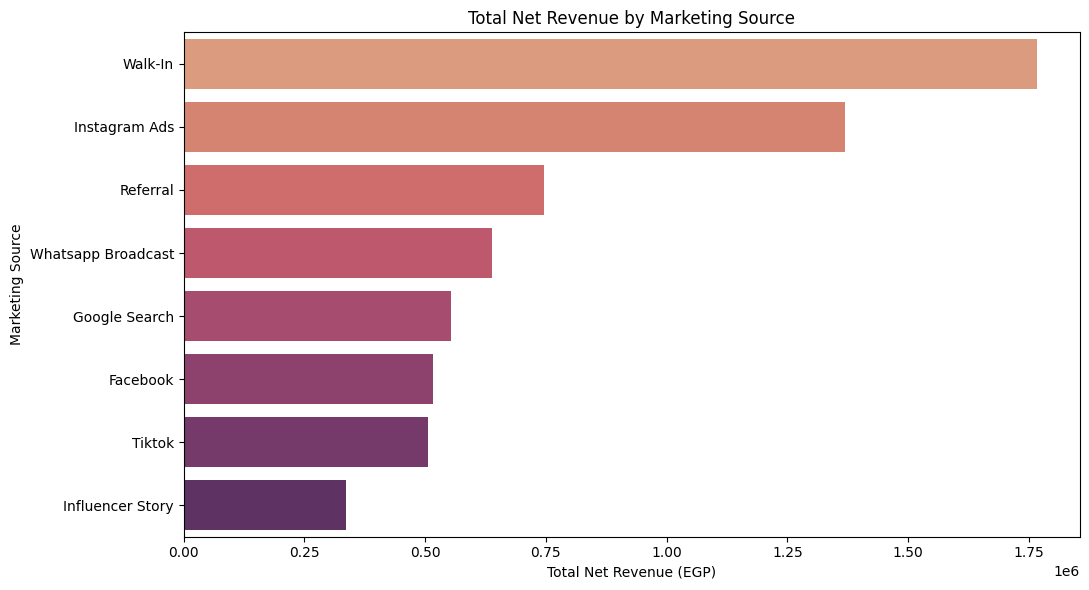

In [161]:
source_rev = df.groupby('marketing_source').agg(
    total_net_revenue=('net_revenue_egp', 'sum'),
    order_count=('order_id', 'count')
).reset_index().sort_values(by='total_net_revenue', ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=source_rev,
    x='total_net_revenue',
    y='marketing_source',
    palette='flare'
)
plt.title('Total Net Revenue by Marketing Source')
plt.xlabel('Total Net Revenue (EGP)')
plt.ylabel('Marketing Source')
plt.tight_layout()
plt.savefig('visuals/17_marketing_source_vs_revenue.png', dpi=300)
plt.show()

### Insight
**What happened?** Walk-in customers generated the highest total net revenue, while Influencer Story generated the lowest.

**Business meaning:** The business relies heavily on physical store presence, while certain digital channels are underperforming in direct revenue contribution.

**Possible reason:** Walk-in customers might already have high purchase intent, whereas Influencer Story might have low reach or poor audience targeting.

**Action / recommendation:** Reallocate marketing budget by investigating the ROI of underperforming digital sources before cutting them off entirely, and consider boosting top-performing sources.

**Limitation:** Total revenue doesn't account for the marketing spend (Cost Per Click/Acquisition) per source.

# Bivariate 18 — Campaign vs Net Revenue

C:\Users\Malak\AppData\Local\Temp\ipykernel_17420\382831080.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


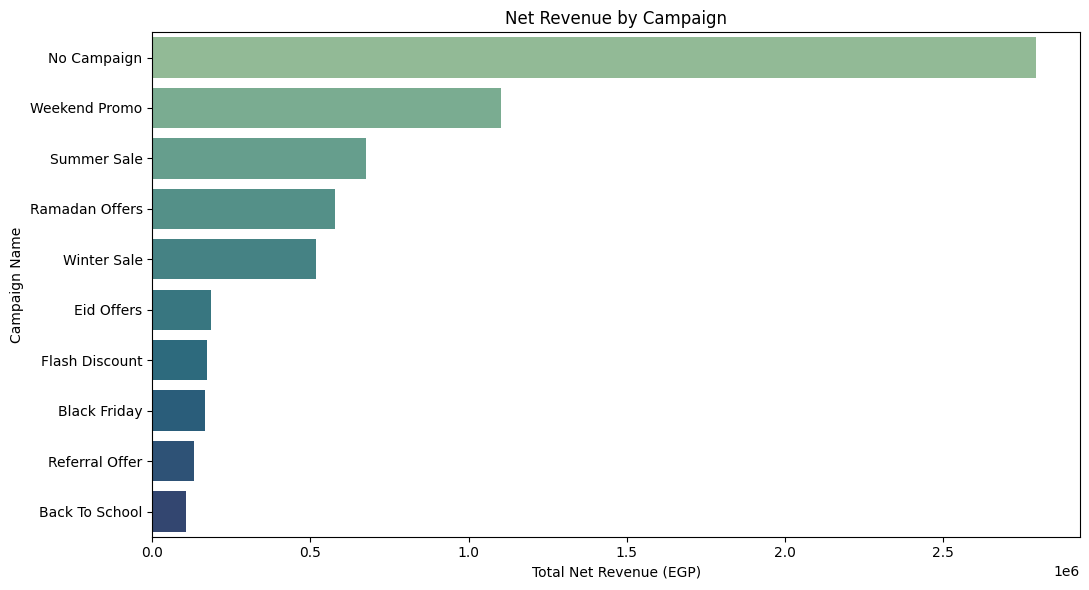

In [162]:
campaign_rev = df.groupby('campaign_name').agg(
    total_net_revenue=('net_revenue_egp', 'sum'),
    order_count=('order_id', 'count')
).reset_index().sort_values(by='total_net_revenue', ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(
    data=campaign_rev,
    x='total_net_revenue',
    y='campaign_name',
    palette='crest'
)
plt.title('Net Revenue by Campaign')
plt.xlabel('Total Net Revenue (EGP)')
plt.ylabel('Campaign Name')
plt.tight_layout()
plt.savefig('visuals/18_campaign_vs_revenue.png', dpi=300)
plt.show()

### Insight
**What happened?** "No Campaign" (organic sales) generated the highest net revenue, while "Back To School" generated the lowest.

**Business meaning:** Organic sales drive a massive portion of revenue, whereas some specific campaigns are underperforming in total revenue contribution.

**Possible reason:** Campaigns might be offering deep discounts that reduce net revenue per item, or they might have low reach and conversion rates compared to organic traffic.

**Action / recommendation:** Evaluate the profitability of named campaigns after deducting marketing costs, and investigate why organic sales perform so strongly to replicate that success.

**Limitation:** Campaign cost is not available in the dataset, so ROI cannot be calculated accurately.

# Bivariate 19 — Campaign vs Return Rate

C:\Users\Malak\AppData\Local\Temp\ipykernel_17420\1107876034.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


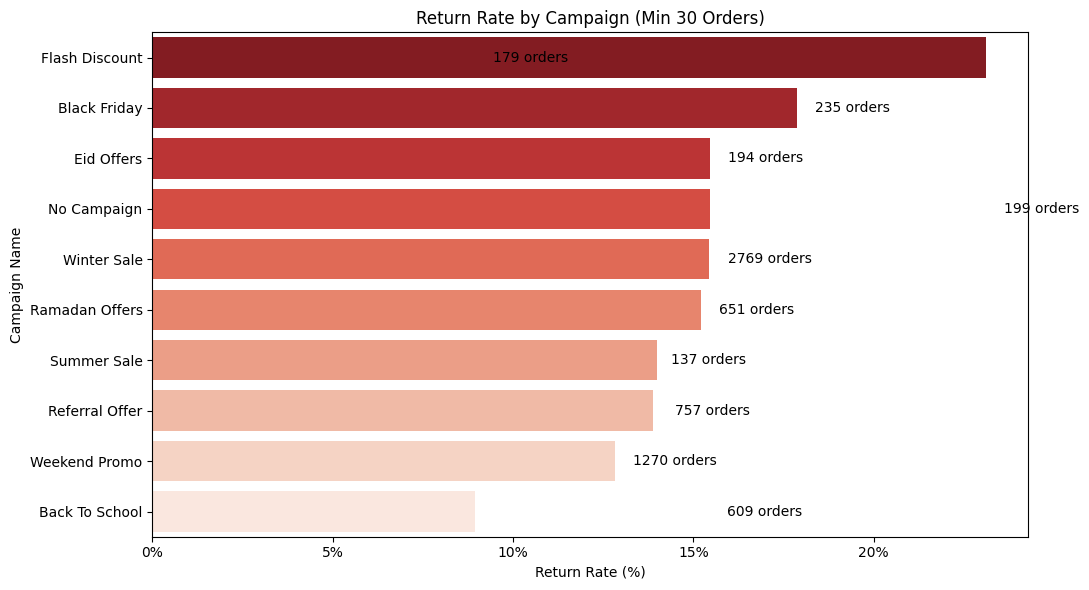

In [163]:
MIN_ORDERS = 30
campaign_orders = df.groupby('campaign_name')['order_id'].count()
valid_campaigns = campaign_orders[campaign_orders >= MIN_ORDERS].index
df_filtered = df[df['campaign_name'].isin(valid_campaigns)]

campaign_return = df_filtered.groupby('campaign_name').agg(
    return_rate=('returned_flag', 'mean'),
    order_count=('order_id', 'count')
).reset_index().sort_values(by='return_rate', ascending=False)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=campaign_return,
    x='return_rate',
    y='campaign_name',
    palette='Reds_r'
)
plt.title('Return Rate by Campaign (Min 30 Orders)')
plt.xlabel('Return Rate (%)')
plt.ylabel('Campaign Name')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

for i, row in campaign_return.iterrows():
    ax.text(row['return_rate'] + 0.005, i, f"{row['order_count']} orders", va='center')

plt.tight_layout()
plt.savefig('visuals/19_campaign_vs_return_rate.png', dpi=300)
plt.show()

### Insight
**What happened?** Winter Sale has the highest return rate, despite driving significant volume (2769 orders), while Back To School has the lowest return rate.

**Business meaning:** High return rates from major campaigns like Winter Sale might be eroding net profit and increasing operational costs.

**Possible reason:** Seasonal sales might lead to impulsive buying or sizing issues (especially in fashion), which are later returned by customers.

**Action / recommendation:** Review the product mix and marketing messaging for Winter Sale to ensure customer expectations are met and reduce avoidable returns.

**Limitation:** A minimum threshold of 30 orders was applied to avoid skewed rates from small sample sizes.

# Bivariate 20 — Courier vs Actual Delivery Days

C:\Users\Malak\AppData\Local\Temp\ipykernel_17420\4050703136.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


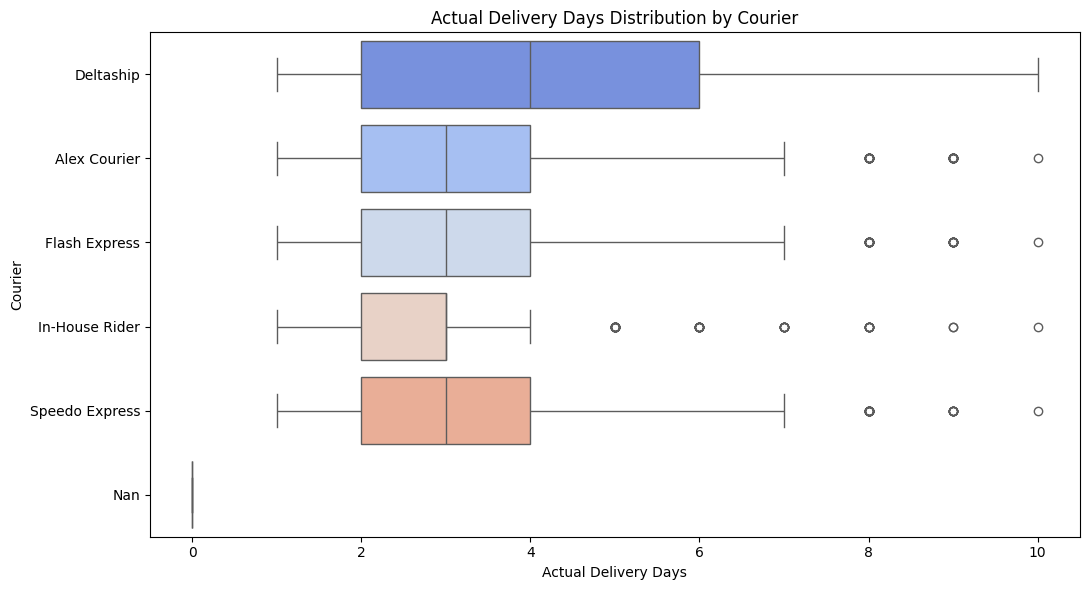

In [164]:
# Exclude Store Pickup as it's not a shipping courier
courier_df = df[df['courier'] != 'Store Pickup'].copy()

courier_delivery = courier_df.groupby('courier')['actual_delivery_days'].median().sort_values(ascending=False)

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=courier_df,
    x='actual_delivery_days',
    y='courier',
    order=courier_delivery.index,
    palette='coolwarm'
)
plt.title('Actual Delivery Days Distribution by Courier')
plt.xlabel('Actual Delivery Days')
plt.ylabel('Courier')
plt.tight_layout()
plt.savefig('visuals/20_courier_vs_delivery_days.png', dpi=300)
plt.show()

### Insight
**What happened?** Deltaship has the highest median delivery time and a wider IQR (interquartile range), while Flash Express and Speedo Express are among the fastest.

**Business meaning:** Deltaship is the least efficient and consistent in terms of delivery time.

**Possible reason:** Deltaship might handle remote areas, experience logistical bottlenecks, or have poorer last-mile infrastructure compared to Flash Express.

**Action / recommendation:** Operations team should audit Deltaship's routes and SLA adherence to identify the cause of delays.

**Limitation:** The mix of delivery areas per courier is not controlled here; Deltaship might be assigned to inherently harder or more remote routes.

# Bivariate 21 — Courier vs On-Time Delivery Rate

C:\Users\Malak\AppData\Local\Temp\ipykernel_17420\155898271.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


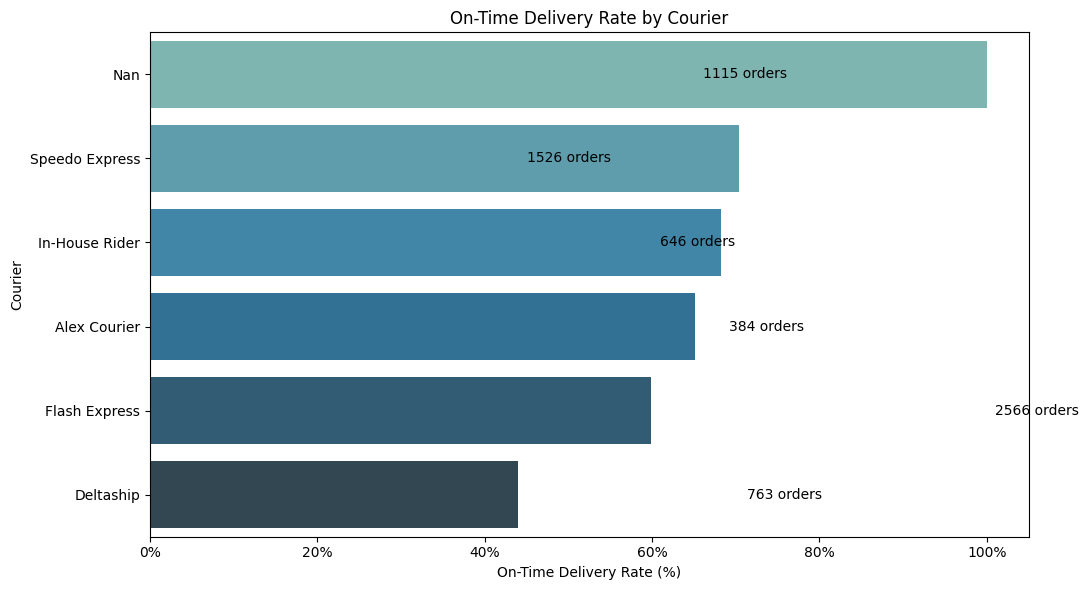

In [165]:
courier_ontime = courier_df.groupby('courier').agg(
    on_time_rate=('on_time_flag', 'mean'),
    order_count=('order_id', 'count')
).reset_index().sort_values(by='on_time_rate', ascending=False)

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=courier_ontime,
    x='on_time_rate',
    y='courier',
    palette='YlGnBu_d'
)
plt.title('On-Time Delivery Rate by Courier')
plt.xlabel('On-Time Delivery Rate (%)')
plt.ylabel('Courier')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: '{:.0%}'.format(x)))

for i, row in courier_ontime.iterrows():
    ax.text(row['on_time_rate'] + 0.01, i, f"{row['order_count']} orders", va='center')

plt.tight_layout()
plt.savefig('visuals/21_courier_vs_ontime_rate.png', dpi=300)
plt.show()

### Insight
**What happened?** Speedo Express achieves a high on-time delivery rate, while Deltaship shows a noticeably lower on-time rate despite handling a large volume of orders.

**Business meaning:** Deltaship fails the delivery promise more frequently, which negatively impacts overall customer satisfaction.

**Possible reason:** Deltaship might face capacity issues, handle harder or more remote routes, or suffer from poor last-mile logistics compared to Speedo Express.

**Action / recommendation:** Consider shifting more volume to higher-performing couriers (like Speedo Express or Flash Express) to improve overall customer satisfaction, but ensure they can handle the capacity.

**Limitation:** The "On-Time" flag is based on Actual <= Expected, which might be influenced by how generously "Expected Delivery Days" were set initially.

# Bivariate 22 — Expected vs Actual Delivery Days

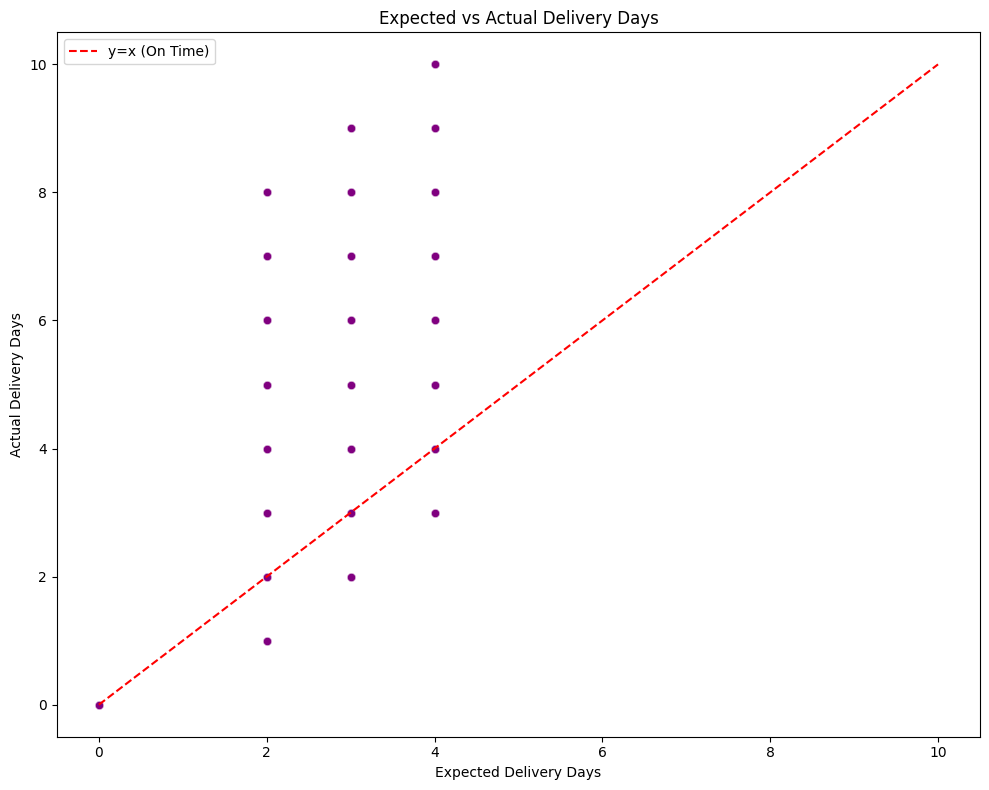

In [166]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=courier_df,
    x='expected_delivery_days',
    y='actual_delivery_days',
    alpha=0.5,
    color='purple'
)
# Add y=x reference line
max_val = max(courier_df['expected_delivery_days'].max(), courier_df['actual_delivery_days'].max())
plt.plot([0, max_val], [0, max_val], 'r--', label='y=x (On Time)')

plt.title('Expected vs Actual Delivery Days')
plt.xlabel('Expected Delivery Days')
plt.ylabel('Actual Delivery Days')
plt.legend()
plt.tight_layout()
plt.savefig('visuals/22_expected_vs_actual_delivery.png', dpi=300)
plt.show()

### Insight
**What happened?** The scatter plot shows a significant cluster of orders above the red y=x reference line, indicating late deliveries, alongside a cluster on or below the line (on-time or early deliveries).

**Business meaning:** A substantial portion of orders fail the promised delivery window, failing customer expectations.

**Possible reason:** Inaccurate initial estimations of expected days, or operational bottlenecks in the supply chain and courier networks.

**Action / recommendation:** Recalibrate the "Expected Delivery Days" logic to be more realistic, or fix the operational delays causing late shipments to reduce the gap.

**Limitation:** The scatter plot becomes overplotted with large datasets; transparency (alpha) was used to mitigate this visual overlap.



# Bivariate 23 — Delivery Delay vs Rating

In [167]:
delay_rating = df[
    ['delivery_delay_days', 'rating']
].dropna().copy()

print(f"Number of valid observations: {len(delay_rating)}")

correlation_23 = delay_rating[
    'delivery_delay_days'
].corr(delay_rating['rating'])

print(f"Correlation between Delivery Delay and Rating: {correlation_23:.3f}")

display(
    delay_rating.describe()
)

Number of valid observations: 7000
Correlation between Delivery Delay and Rating: -0.418


,delivery_delay_days,rating
count,7000.000000,7000.000000
mean,0.632429,3.894029
std,1.559747,0.943410
min,-1.000000,1.000000
25%,0.000000,3.500000
50%,0.000000,4.100000
75%,1.000000,4.600000
max,6.000000,5.000000


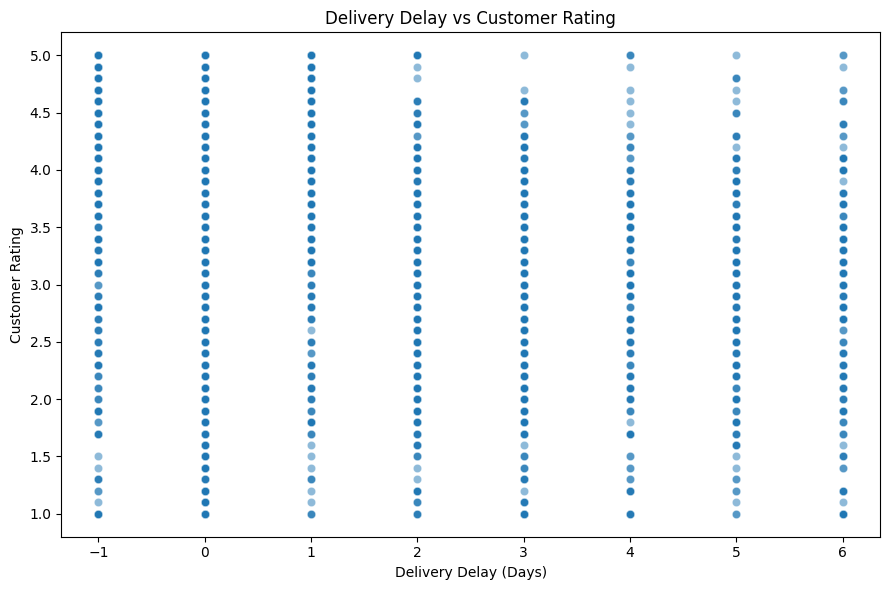

In [168]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=delay_rating,
    x='delivery_delay_days',
    y='rating',
    alpha=0.5
)

plt.title('Delivery Delay vs Customer Rating')
plt.xlabel('Delivery Delay (Days)')
plt.ylabel('Customer Rating')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** There is a moderate negative correlation between delivery delay and customer rating (r = -0.418). This means that higher delivery delays are generally associated with lower customer ratings.
- **Business meaning:** Delivery performance appears to be an important factor related to customer satisfaction.
- **Possible reason:** Customers may be less satisfied when their orders arrive later than expected.
- **Recommendation:** Monitor delayed orders and prioritize reducing delivery delays to improve the customer experience.
- **Limitation:** Correlation shows an association but does not prove that delivery delay directly causes lower ratings.


# Bivariate 24 — Returned Status vs Rating

In [169]:
returned_rating = df[
    ['returned_flag', 'rating']
].dropna().copy()

rating_by_return = (
    returned_rating
    .groupby('returned_flag')['rating']
    .agg(['count', 'mean', 'median', 'std'])
    .reset_index()
)

display(rating_by_return)

,returned_flag,count,mean,median,std
0,0,5957,4.186957,4.3,0.613864
1,1,1043,2.220997,2.2,0.729374


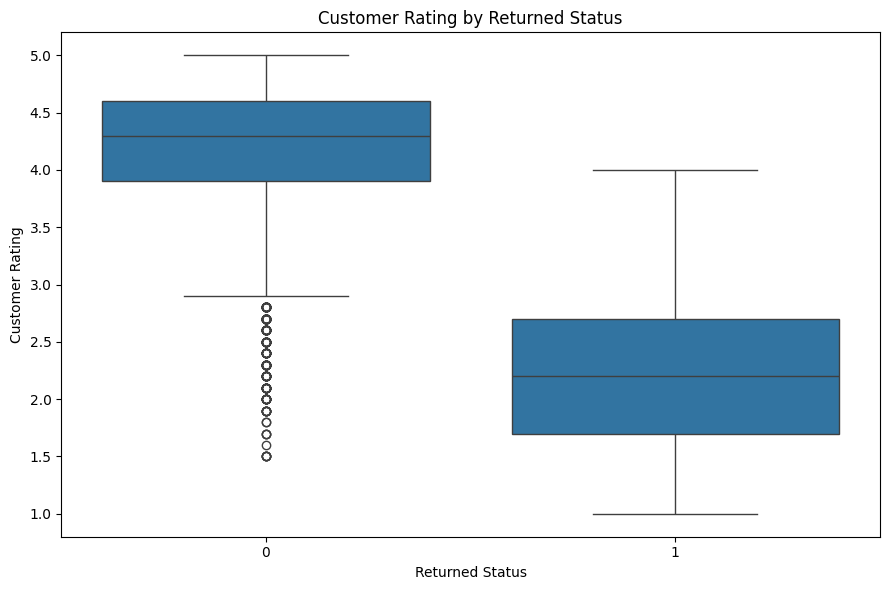

In [170]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=returned_rating,
    x='returned_flag',
    y='rating'
)

plt.title('Customer Rating by Returned Status')
plt.xlabel('Returned Status')
plt.ylabel('Customer Rating')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Non-returned orders had a much higher average rating (4.19) compared with returned orders (2.22). The median ratings were 4.3 and 2.2 respectively.
- **Business meaning:** Returned orders are strongly associated with lower customer satisfaction.
- **Possible reason:** Customers who return products may have experienced product quality issues, incorrect items, delivery problems, or unmet expectations.
- **Recommendation:** Investigate low-rated returned orders together with their return reasons and complaint text to identify the main sources of dissatisfaction.
- **Limitation:** The analysis shows an association between return status and rating and does not prove that the return itself causes the lower rating.


# Bivariate 25 — Return Reason vs Product Category

Which product categories are associated with the different return reasons?

In [171]:
return_category = df[
    (df['returned_flag'] == 1) &
    df['return_reason_category'].notna() &
    df['category'].notna()
].copy()

# Count table
return_category_counts = pd.crosstab(
    return_category['return_reason_category'],
    return_category['category']
)

print("Count Crosstab")
display(return_category_counts)

# Row percentages
return_category_row_pct = pd.crosstab(
    return_category['return_reason_category'],
    return_category['category'],
    normalize='index'
) * 100

print("Row Percentages")
display(return_category_row_pct.round(2))

# Column percentages
return_category_col_pct = pd.crosstab(
    return_category['return_reason_category'],
    return_category['category'],
    normalize='columns'
) * 100

print("Column Percentages")
display(return_category_col_pct.round(2))

Count Crosstab


category,Audio,Bathroom,Bedroom,Casual Footwear,Formal Shoes,Fragrance,Hair Care,Home Decor,Kids Shoes,Kitchenware,Makeup,Men Clothing,Mobile Accessories,Office Accessories,Sandals,Skin Care,Sneakers,Sports Shoes,Stationery,Women Clothing
return_reason_category,,,,,,,,,,,,,,,,,,,,
Changed Mind,0,0,0,6,2,1,0,2,2,2,5,17,0,0,0,0,4,1,2,22
Damaged Packaging,1,1,1,1,2,5,2,5,1,8,2,13,5,4,1,4,0,1,2,15
Defective Item,6,0,0,0,0,0,0,0,0,0,0,0,20,0,0,0,0,0,0,0
Late Delivery,11,4,6,15,13,21,7,11,7,9,13,76,31,8,5,17,10,6,10,80
Missing Item,1,0,0,0,0,1,2,0,0,0,0,0,4,1,0,0,0,0,4,0
Not As Described,0,0,0,4,3,6,1,4,0,5,5,30,0,2,2,0,3,4,2,22
Quality Issue,4,2,2,2,2,16,7,5,5,5,7,31,11,3,2,5,4,5,2,32
Wrong Item,4,1,0,1,1,0,3,2,1,2,0,8,5,1,1,0,2,1,0,17
Wrong Size,0,0,0,12,7,0,0,0,6,0,0,76,0,0,15,0,12,14,0,67


Row Percentages


category,Audio,Bathroom,Bedroom,Casual Footwear,Formal Shoes,Fragrance,Hair Care,Home Decor,Kids Shoes,Kitchenware,Makeup,Men Clothing,Mobile Accessories,Office Accessories,Sandals,Skin Care,Sneakers,Sports Shoes,Stationery,Women Clothing
return_reason_category,,,,,,,,,,,,,,,,,,,,
Changed Mind,0.00,0.00,0.00,9.09,3.03,1.52,0.00,3.03,3.03,3.03,7.58,25.76,0.00,0.00,0.00,0.00,6.06,1.52,3.03,33.33
Damaged Packaging,1.35,1.35,1.35,1.35,2.70,6.76,2.70,6.76,1.35,10.81,2.70,17.57,6.76,5.41,1.35,5.41,0.00,1.35,2.70,20.27
Defective Item,23.08,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,76.92,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Late Delivery,3.06,1.11,1.67,4.17,3.61,5.83,1.94,3.06,1.94,2.50,3.61,21.11,8.61,2.22,1.39,4.72,2.78,1.67,2.78,22.22
Missing Item,7.69,0.00,0.00,0.00,0.00,7.69,15.38,0.00,0.00,0.00,0.00,0.00,30.77,7.69,0.00,0.00,0.00,0.00,30.77,0.00
Not As Described,0.00,0.00,0.00,4.30,3.23,6.45,1.08,4.30,0.00,5.38,5.38,32.26,0.00,2.15,2.15,0.00,3.23,4.30,2.15,23.66
Quality Issue,2.63,1.32,1.32,1.32,1.32,10.53,4.61,3.29,3.29,3.29,4.61,20.39,7.24,1.97,1.32,3.29,2.63,3.29,1.32,21.05
Wrong Item,8.00,2.00,0.00,2.00,2.00,0.00,6.00,4.00,2.00,4.00,0.00,16.00,10.00,2.00,2.00,0.00,4.00,2.00,0.00,34.00
Wrong Size,0.00,0.00,0.00,5.74,3.35,0.00,0.00,0.00,2.87,0.00,0.00,36.36,0.00,0.00,7.18,0.00,5.74,6.70,0.00,32.06


Column Percentages


category,Audio,Bathroom,Bedroom,Casual Footwear,Formal Shoes,Fragrance,Hair Care,Home Decor,Kids Shoes,Kitchenware,Makeup,Men Clothing,Mobile Accessories,Office Accessories,Sandals,Skin Care,Sneakers,Sports Shoes,Stationery,Women Clothing
return_reason_category,,,,,,,,,,,,,,,,,,,,
Changed Mind,0.00,0.0,0.00,14.63,6.67,2.0,0.00,6.90,9.09,6.45,15.62,6.77,0.00,0.00,0.00,0.00,11.43,3.12,9.09,8.63
Damaged Packaging,3.70,12.5,11.11,2.44,6.67,10.0,9.09,17.24,4.55,25.81,6.25,5.18,6.58,21.05,3.85,15.38,0.00,3.12,9.09,5.88
Defective Item,22.22,0.0,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,26.32,0.00,0.00,0.00,0.00,0.00,0.00,0.00
Late Delivery,40.74,50.0,66.67,36.59,43.33,42.0,31.82,37.93,31.82,29.03,40.62,30.28,40.79,42.11,19.23,65.38,28.57,18.75,45.45,31.37
Missing Item,3.70,0.0,0.00,0.00,0.00,2.0,9.09,0.00,0.00,0.00,0.00,0.00,5.26,5.26,0.00,0.00,0.00,0.00,18.18,0.00
Not As Described,0.00,0.0,0.00,9.76,10.00,12.0,4.55,13.79,0.00,16.13,15.62,11.95,0.00,10.53,7.69,0.00,8.57,12.50,9.09,8.63
Quality Issue,14.81,25.0,22.22,4.88,6.67,32.0,31.82,17.24,22.73,16.13,21.88,12.35,14.47,15.79,7.69,19.23,11.43,15.62,9.09,12.55
Wrong Item,14.81,12.5,0.00,2.44,3.33,0.0,13.64,6.90,4.55,6.45,0.00,3.19,6.58,5.26,3.85,0.00,5.71,3.12,0.00,6.67
Wrong Size,0.00,0.0,0.00,29.27,23.33,0.0,0.00,0.00,27.27,0.00,0.00,30.28,0.00,0.00,57.69,0.00,34.29,43.75,0.00,26.27


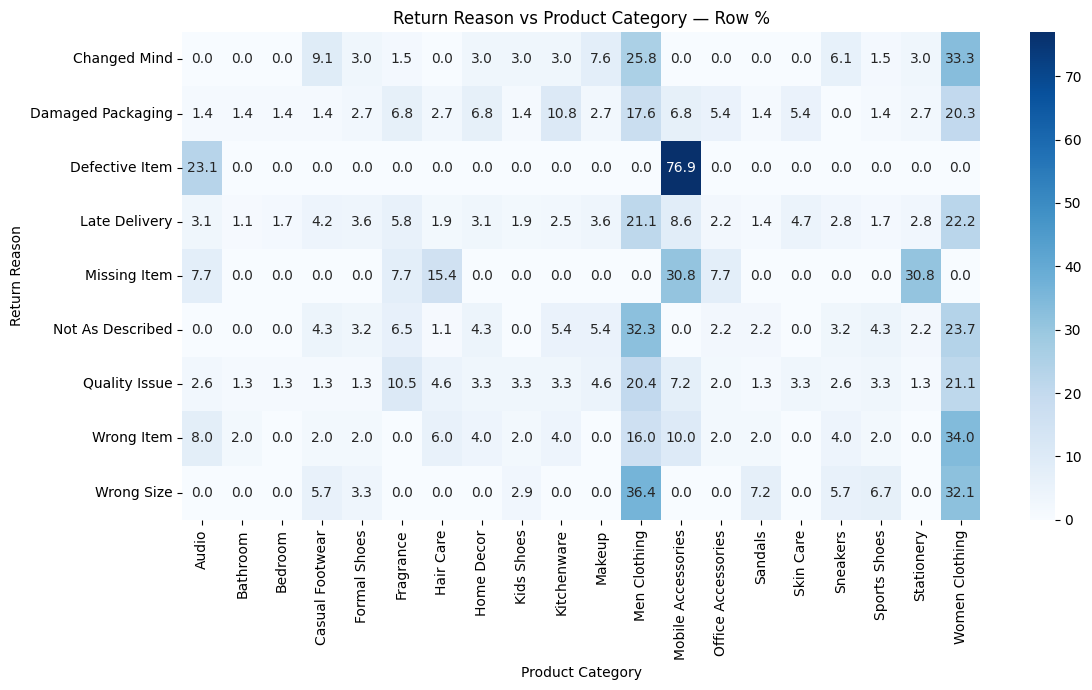

In [172]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    return_category_row_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Return Reason vs Product Category — Row %')
plt.xlabel('Product Category')
plt.ylabel('Return Reason')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Return reasons are distributed differently across product categories. The strongest concentration is for Defective Item returns, where Mobile Accessories account for 76.92% of the returns in that reason category. Wrong Size returns are most concentrated in Men Clothing (36.36%), while Wrong Item returns are most concentrated in Women Clothing (34.00%).
- **Business meaning:** Different product categories appear to have different return-related problems.
- **Possible reason:** Product characteristics and customer expectations may differ by category, leading to different types of return issues.
- **Recommendation:** Investigate product categories with high concentrations of specific return reasons, especially Mobile Accessories for defective-item returns and clothing categories for size-related returns.
- **Limitation:** The analysis describes the distribution of recorded return reasons but does not establish the root cause of the returns.


# Bivariate 26 — Return Reason vs Refund Method

Are certain return reasons associated with specific refund methods?

In [173]:
reason_refund = df[
    (df['returned_flag'] == 1) &
    df['return_reason_category'].notna() &
    df['refund_method'].notna()
].copy()

reason_refund_counts = pd.crosstab(
    reason_refund['return_reason_category'],
    reason_refund['refund_method']
)

print("Count Crosstab")
display(reason_refund_counts)

reason_refund_pct = pd.crosstab(
    reason_refund['return_reason_category'],
    reason_refund['refund_method'],
    normalize='index'
) * 100

print("Normalized Row Percentages")
display(reason_refund_pct.round(2))

Count Crosstab


refund_method,Cash Refund,Exchange,Original Payment,Store Credit
return_reason_category,,,,
Changed Mind,12,9,35,10
Damaged Packaging,10,6,43,15
Defective Item,1,0,16,9
Late Delivery,58,22,175,105
Missing Item,1,3,7,2
Not As Described,15,9,46,23
Quality Issue,20,21,73,38
Wrong Item,11,2,27,10
Wrong Size,30,22,109,48


Normalized Row Percentages


refund_method,Cash Refund,Exchange,Original Payment,Store Credit
return_reason_category,,,,
Changed Mind,18.18,13.64,53.03,15.15
Damaged Packaging,13.51,8.11,58.11,20.27
Defective Item,3.85,0.00,61.54,34.62
Late Delivery,16.11,6.11,48.61,29.17
Missing Item,7.69,23.08,53.85,15.38
Not As Described,16.13,9.68,49.46,24.73
Quality Issue,13.16,13.82,48.03,25.00
Wrong Item,22.00,4.00,54.00,20.00
Wrong Size,14.35,10.53,52.15,22.97


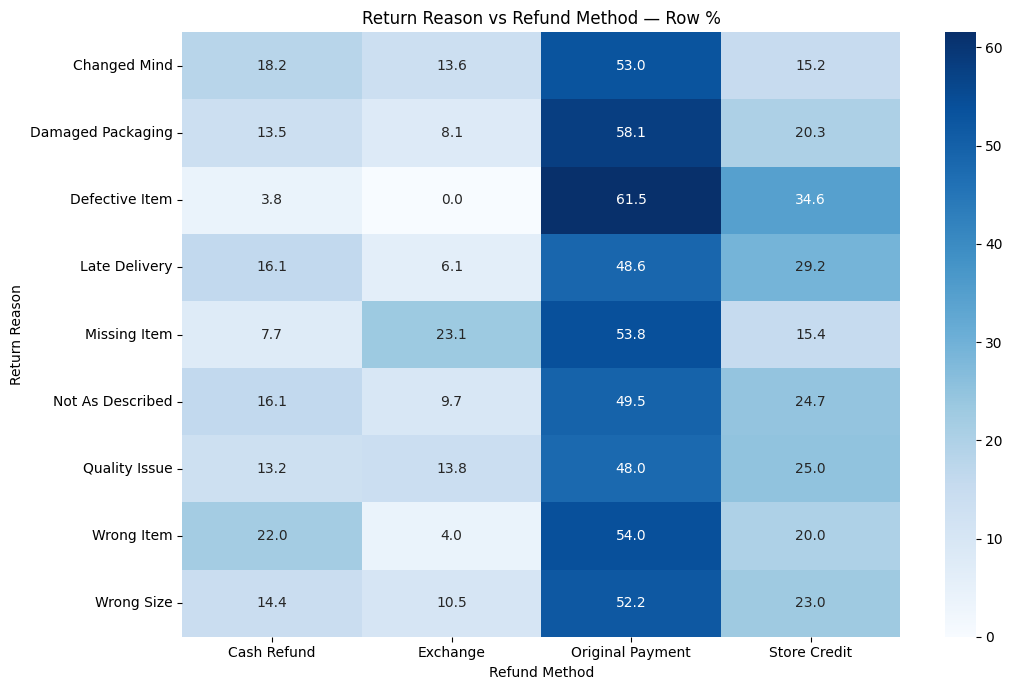

In [174]:
plt.figure(figsize=(11, 7))

sns.heatmap(
    reason_refund_pct,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Return Reason vs Refund Method — Row %')
plt.xlabel('Refund Method')
plt.ylabel('Return Reason')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Original Payment is the most common refund method across all recorded return reasons. Its share ranges from 48.03% for Quality Issue to 61.54% for Defective Item returns.
- **Business meaning:** Returning the refund through the original payment method is the dominant refund process across different return scenarios.
- **Possible reason:** Customers may generally prefer receiving refunds through the same method used for the original purchase.
- **Recommendation:** Ensure that the Original Payment refund process is efficient and reliable, while monitoring alternative methods such as Store Credit and Exchange.
- **Limitation:** The dataset does not explain why a specific refund method was selected for each return.


# Bivariate 27 — Supplier vs Lead Time

How does supplier lead time vary across suppliers?

In [175]:
supplier_lead = df[
    ['supplier', 'lead_time_days']
].dropna().copy()

supplier_lead_summary = (
    supplier_lead
    .groupby('supplier')['lead_time_days']
    .agg(
        order_count='count',
        mean='mean',
        median='median',
        min='min',
        max='max'
    )
    .reset_index()
    .sort_values('mean', ascending=False)
)

display(supplier_lead_summary)

,supplier,order_count,mean,median,min,max
3,Imported Batch,1425,8.003509,7.0,3,21
0,Alex Local Factory,984,8.003049,7.0,3,21
1,Cairo Distributor,1278,7.996870,7.0,3,21
2,Cairo Textile Hub,1198,7.980801,7.0,3,21
5,Local Supplier,944,7.955508,7.0,3,21
6,Official Distributor,543,7.858195,7.0,3,21
4,In-House,628,7.843949,7.0,3,21


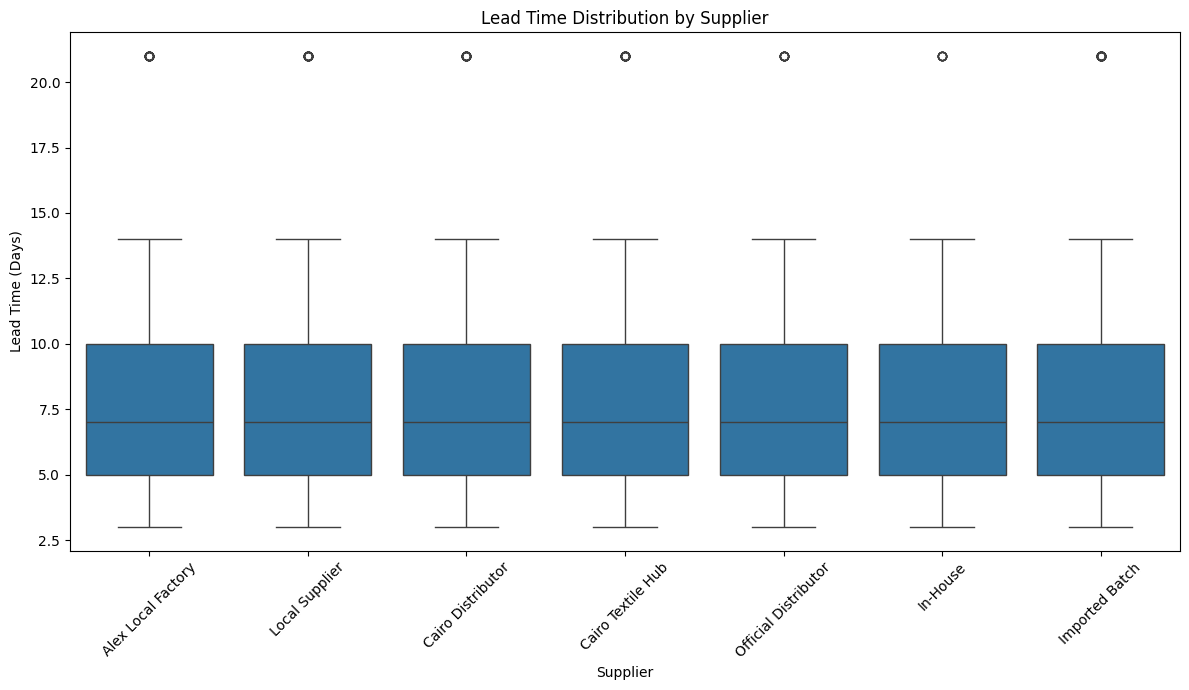

In [176]:
plt.figure(figsize=(12, 7))

sns.boxplot(
    data=supplier_lead,
    x='supplier',
    y='lead_time_days'
)

plt.title('Lead Time Distribution by Supplier')
plt.xlabel('Supplier')
plt.ylabel('Lead Time (Days)')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Lead times are very similar across suppliers. The average lead time ranges from 7.84 days for In-House to 8.00 days for Imported Batch, while the median is 7 days for all suppliers.
- **Business meaning:** Supplier lead time appears to be relatively consistent across the different suppliers in this dataset.
- **Possible reason:** The suppliers may follow similar delivery or replenishment schedules.
- **Recommendation:** Supplier selection should not rely on lead time alone; cost, quality, reliability, and stock availability should also be considered.
- **Limitation:** Lead time is only one measure of supplier performance and does not capture supplier cost or product quality.


# Bivariate 28 — Stock Before Sale vs Quantity

Is the quantity sold related to the stock available before the sale?

In [177]:
stock_quantity = df[
    ['stock_available_before_sale', 'quantity']
].dropna().copy()

correlation_28 = stock_quantity[
    'stock_available_before_sale'
].corr(stock_quantity['quantity'])

print(
    f"Correlation between Stock Available Before Sale "
    f"and Quantity: {correlation_28:.3f}"
)

display(stock_quantity.describe())

Correlation between Stock Available Before Sale and Quantity: -0.013


,stock_available_before_sale,quantity
count,7000.000000,7000.000000
mean,82.628143,1.571429
std,44.302021,0.894674
min,2.000000,1.000000
25%,51.000000,1.000000
50%,81.000000,1.000000
75%,113.000000,2.000000
max,260.000000,6.000000


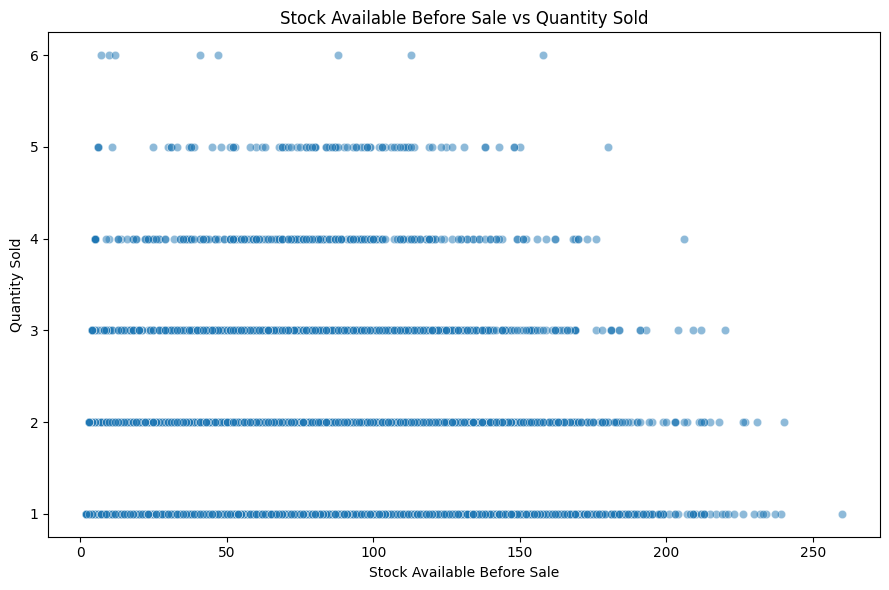

In [178]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=stock_quantity,
    x='stock_available_before_sale',
    y='quantity',
    alpha=0.5
)

plt.title('Stock Available Before Sale vs Quantity Sold')
plt.xlabel('Stock Available Before Sale')
plt.ylabel('Quantity Sold')

plt.tight_layout()
plt.show()

In [179]:
stock_quantity['low_stock_flag'] = (
    stock_quantity['stock_available_before_sale'] <= 5
)

display(
    stock_quantity['low_stock_flag']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename('percentage')
)

low_stock_flag
False    96.1
True      3.9
Name: percentage, dtype: float64

### Insight

- **What happened:** There is almost no linear correlation between stock available before sale and quantity sold (r = -0.013). Only 3.9% of observations had stock levels of 5 units or less.
- **Business meaning:** The available stock level does not appear to have a meaningful linear relationship with the quantity sold in this dataset.
- **Possible reason:** Stock levels may be determined by inventory planning and expected demand rather than directly by the quantity sold in an individual order.
- **Recommendation:** Use stock levels together with sales history, demand patterns, and supplier lead time for inventory planning.
- **Limitation:** The analysis is based on stock available before each sale and does not represent the complete inventory movement over time.


# Bivariate 29 — Weather vs Delivery Delay

Does delivery delay vary under different weather conditions?

In [180]:
weather_delay = df[
    ['weather', 'delivery_delay_days']
].dropna().copy()

weather_delay_summary = (
    weather_delay
    .groupby('weather')['delivery_delay_days']
    .agg(
        order_count='count',
        mean='mean',
        median='median',
        min='min',
        max='max'
    )
    .reset_index()
    .sort_values('mean', ascending=False)
)

display(weather_delay_summary)

,weather,order_count,mean,median,min,max
0,Cloudy,1518,0.666008,0.0,-1,6
5,Windy,1042,0.642994,0.0,-1,6
4,Sunny,2447,0.642419,0.0,-1,6
1,Cold,106,0.613208,0.0,-1,6
3,Rainy,541,0.609982,0.0,-1,6
2,Hot,1346,0.578752,0.0,-1,6


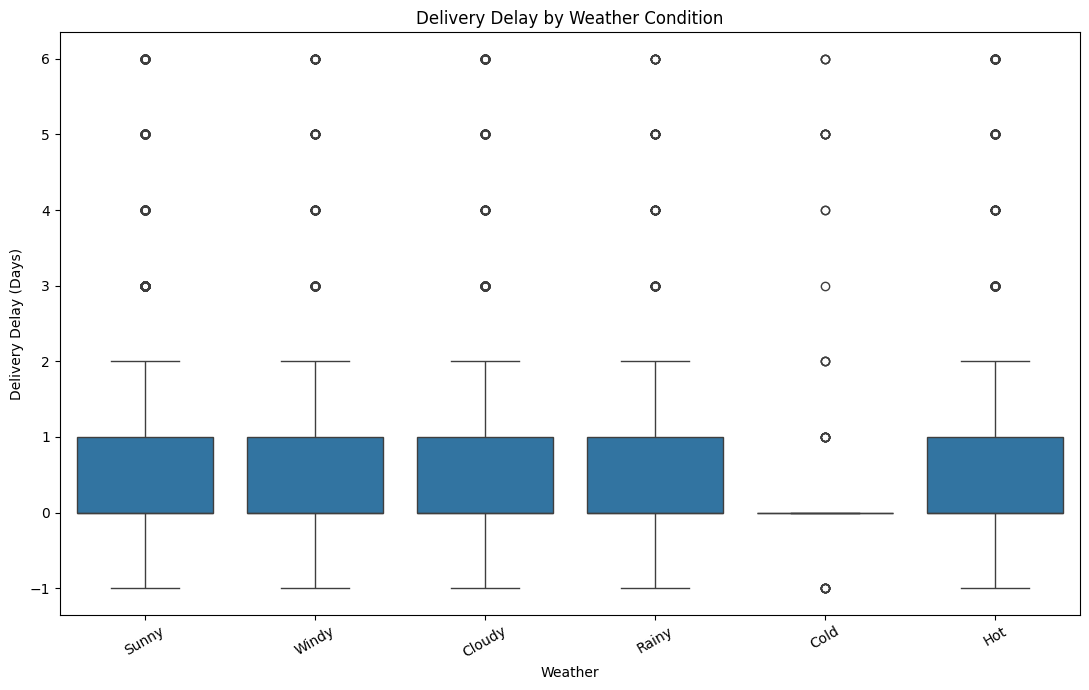

In [181]:
plt.figure(figsize=(11, 7))

sns.boxplot(
    data=weather_delay,
    x='weather',
    y='delivery_delay_days'
)

plt.title('Delivery Delay by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Delivery Delay (Days)')

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Average delivery delay varies slightly across weather conditions. Cloudy weather has the highest average delay at 0.666 days, while Hot weather has the lowest at 0.579 days. The median delay is 0 days for all weather conditions.
- **Business meaning:** Weather conditions show only small differences in delivery delay in this dataset.
- **Possible reason:** Weather may have some effect on delivery operations, but other operational factors may be more important.
- **Recommendation:** Continue monitoring weather alongside courier performance and delivery status rather than treating weather as the main explanation for delays.
- **Limitation:** The dataset does not capture weather severity or the exact conditions at the delivery location.


# Bivariate 30 — Season vs Net Revenue

Which season generates the highest net revenue, and how does order volume compare?

In [182]:
season_revenue = (
    df.groupby('season')
    .agg(
        total_net_revenue=('net_revenue_egp', 'sum'),
        order_count=('order_id', 'nunique')
    )
    .reset_index()
)

season_revenue['AOV'] = (
    season_revenue['total_net_revenue']
    / season_revenue['order_count']
)

season_revenue = season_revenue.sort_values(
    'total_net_revenue',
    ascending=False
)

display(season_revenue)

,season,total_net_revenue,order_count,AOV
1,Spring,2.089551e+06,2300,908.500320
3,Winter,1.878711e+06,1974,951.728033
2,Summer,1.462716e+06,1578,926.942734
0,Autumn,1.001332e+06,1148,872.240443


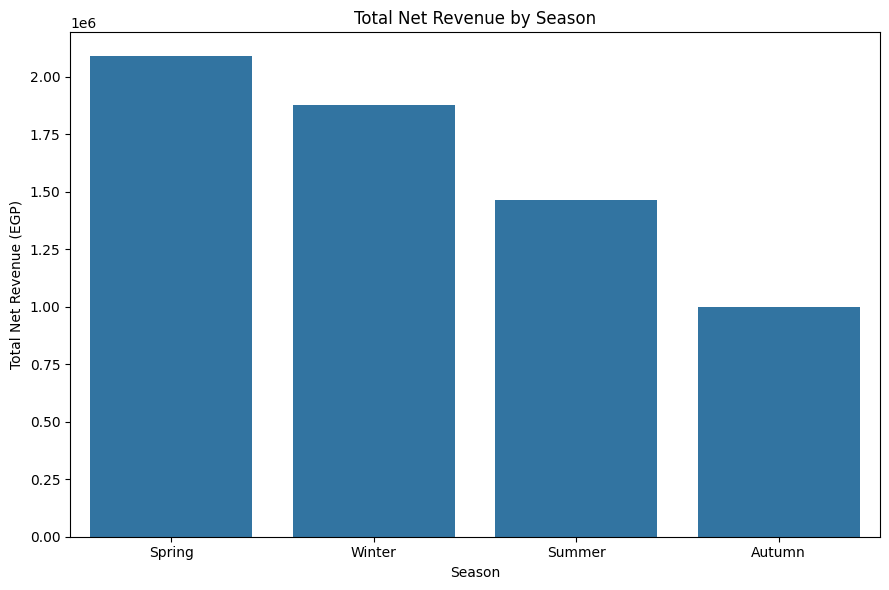

In [183]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=season_revenue,
    x='season',
    y='total_net_revenue',
    order=season_revenue['season']
)

plt.title('Total Net Revenue by Season')
plt.xlabel('Season')
plt.ylabel('Total Net Revenue (EGP)')

plt.tight_layout()
plt.show()

### Insight

- **What happened:** Spring generated the highest total net revenue at 2,089,550.74 EGP from 2,300 orders. Winter generated 1,878,711.14 EGP but had the highest AOV at 951.73 EGP.
- **Business meaning:** Spring is the strongest season in terms of total revenue, while Winter customers have the highest average order value.
- **Possible reason:** Seasonal differences may be related to order volume, customer purchasing behavior, promotions, or product mix.
- **Recommendation:** Use Spring's high order volume for revenue-focused planning, while Winter's higher AOV can be used to identify opportunities for increasing customer basket size in other seasons.
- **Limitation:** Seasonal revenue differences do not by themselves identify the exact causes of the variation.

#### Key Findings / Recommendations / Limitations

# 11. Key Business Findings

1. **Revenue drivers:** Fashion generates ~45.9% of total net revenue, and the Store channel leads with ~2.33M EGP from 2,566 orders — the business is still heavily physical-store dependent.
2. **Gender gap:** Female customers generate ~3.80M EGP vs ~2.64M EGP for male customers, driven mainly by higher order count (4,142 vs 2,858), not higher AOV.
3. **Geographic concentration:** Smouha leads in order volume (9.49%), while Downtown Alexandria leads in revenue (~1.15M EGP) — demand and value are not concentrated in the same areas.
4. **Return hotspots:** Mandara has the highest return rate (16.89%) vs Miami's lowest (12.90%). Overall return rate is 14.90% (1,043 of 7,000 orders).
5. **Pricing has weak influence:** Correlations between price, discount, and quantity/revenue are all very weak (|r| < 0.1) — demand doesn't appear price-driven.
6. **Delivery drives satisfaction:** Delivery delay has a moderate negative correlation with rating (r = -0.418); returned orders average 2.22 rating vs 4.19 for non-returned.
7. **Courier performance varies:** Deltaship shows the slowest median delivery time and lowest on-time rate despite high volume; Speedo Express is both fast and reliable.
8. **Marketing dependency:** "No Campaign" (organic) generates the most revenue, and Walk-in customers are the top acquisition source — paid campaigns are not yet the main growth driver.
9. **Campaign quality risk:** Winter Sale drives the highest volume (2,769 orders) but also the highest return rate — possibly signaling promotion-driven low-intent purchases.
10. **Inventory is not a bottleneck:** Stock level before sale shows almost no correlation with quantity sold (r = -0.013); stockouts don't appear to limit large orders.
11. **Suppliers are consistent:** Lead time is stable across suppliers (7.84–8.00 days average) — no single supplier stands out as a risk.
12. **Seasonality:** Spring leads in total revenue (2.09M EGP), while Winter has the highest average order value (951.73 EGP) despite fewer orders.

# 12. Recommendations

- **Sales & Marketing:** Invest further in Fashion and Store-channel performance while testing paid-acquisition growth, since organic/walk-in traffic currently carries most revenue.
- **Discounting:** Re-evaluate blanket discounting — since discount level shows almost no positive relationship with quantity or revenue, targeted discounts may work better than broad ones.
- **Logistics:** Prioritize an operational review of Deltaship (delivery time and on-time rate) and investigate root causes of delay before the next high-volume season.
- **Customer Experience:** Since delivery delay and returns are strongly linked to lower ratings, tightening delivery-time accuracy is likely to have a direct, measurable impact on satisfaction.
- **Returns:** Investigate the most common return reason category by product category (see Analysis #25) and route findings to the relevant product/quality team.
- **Campaigns:** Audit "Winter Sale" specifically — high order volume paired with a high return rate may indicate discount-driven purchases that don't match customer expectations.
- **Geography:** Consider targeted retention or delivery-quality initiatives in Mandara given its elevated return rate, and investigate whether coverage should expand in low-volume areas like Borg El Arab.

# 13. Limitations

- Campaign cost/budget data is not available, so ROI per campaign or marketing source cannot be calculated — only revenue and return-rate contribution.
- Return reasons are self-reported/categorized and may not capture the full underlying cause of a return.
- Rating is missing for a portion of orders (customers who didn't review), which may bias satisfaction analysis toward more engaged customers.
- Correlation-based findings (price, discount, stock vs. quantity/revenue) describe association only, not causation.
- Some categorical comparisons (e.g., by supplier, campaign, or courier) use a minimum-order threshold to avoid misleading small-sample results, which excludes a few rare categories from ranking.
- The dataset covers a fixed historical period; seasonal and campaign findings may not generalize to future periods without re-validation.